In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import linear_model, model_selection
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.metrics import matthews_corrcoef
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from pickle import dump,load
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report 
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as Kc
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,InputLayer
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import matthews_corrcoef
from tensorflow.keras.utils import to_categorical
from sklearn.utils import class_weight
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import seaborn as sns

SMALL_SIZE = 18
MEDIUM_SIZE = 20
BIGGER_SIZE = 22

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title


In [20]:

#creamos un dataframe a partir de un dataset
data= pd.read_csv("nuevoDataset.csv",sep=",",index_col=False)
data['Proceso']=data['1P'].values+data['2P'].values+data['Taller'].values
dfg=data.groupby(by='Idalumno').apply(lambda x:x['Carrera'].value_counts().index[0][:3] if (x['Carrera'].value_counts().index[0][0:3]!='INT') else 'ELE' if (np.size(x['Carrera'].value_counts().index)==1 and (x['Carrera'].value_counts().index[0]=='INT9ELECTR' or x['Carrera'].value_counts().index[0]=='INT9MECANI')) else 'CIV' if (np.size(x['Carrera'].value_counts().index)==1 and (x['Carrera'].value_counts().index[0]=='INT9CONSTR' or x['Carrera'].value_counts().index[0]=='INT9TRANSP' )) else 'IND' if (np.size(x['Carrera'].value_counts().index)==1 and x['Carrera'].value_counts().index[0]=='INT9G-ECO ') else x['Carrera'].value_counts().index[0] if (np.size(x['Carrera'].value_counts().index)==1) else x['Carrera'].value_counts().index[1][:3] if x['Carrera'].value_counts().index[1][:3]!='INT' else 'ELE' if x['Carrera'].value_counts().index[1]=='INT9ELECTR' or x['Carrera'].value_counts().index[1]=='INT9MECANI' else 'IND' if ( x['Carrera'].value_counts().index[1]=='INT9G-ECO ') else  x['Carrera'].value_counts().index[1])
data['CarreraCod']= data.apply(lambda row: dfg[dfg.index==row.Idalumno].values[0], axis = 1)
data['Proceso']=data['1P'].values+data['2P'].values+data['Taller'].values


In [21]:
for anho in np.unique(data['Anho'].values):
    for ciclo in np.unique(data['ciclo'].values):
        flag=np.logical_and(data.Anho.values== anho,data.ciclo.values== ciclo)
        df=data[flag]
        dfg=data[flag].groupby(by=['Idalumno','Anho','ciclo']).apply(lambda x:min(x['Semestre'].values))
        data['SemestreAlumno']= data.apply(lambda row: dfg[dfg.index==(row.Idalumno,row.Anho,row.ciclo)].values, axis = 1)


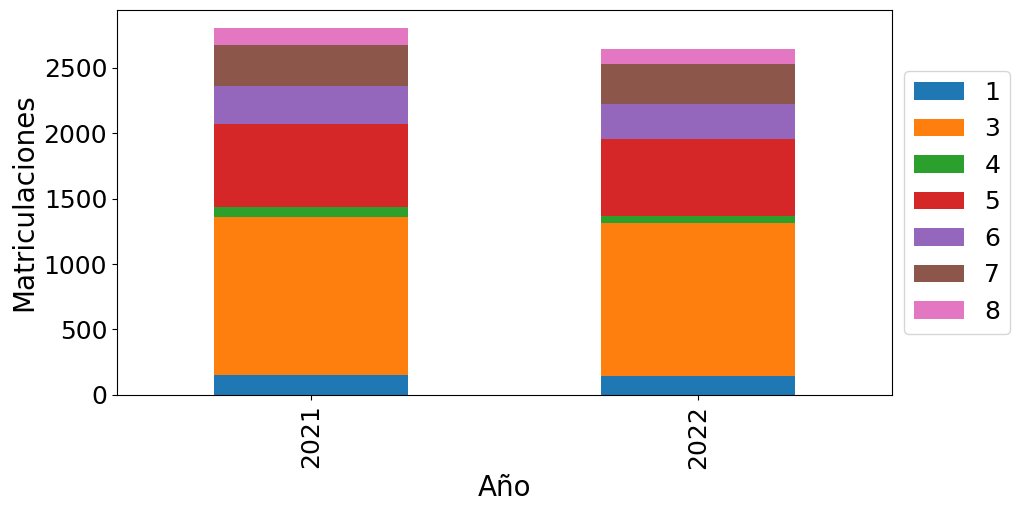

In [22]:
df=data.groupby(['Anho','CarreraCod'])['Idalumno'].nunique()
carreras=np.unique(dfg.values).tolist()
f, ax = plt.subplots(figsize=(10, 5))

df.unstack().plot(kind='bar', stacked=True,ax=ax)
ax.legend(carreras)
plt.legend(carreras,loc='center left', bbox_to_anchor=(1.0, 0.5))


plt.xlabel("Año")
plt.ylabel("Matriculaciones")
plt.show()

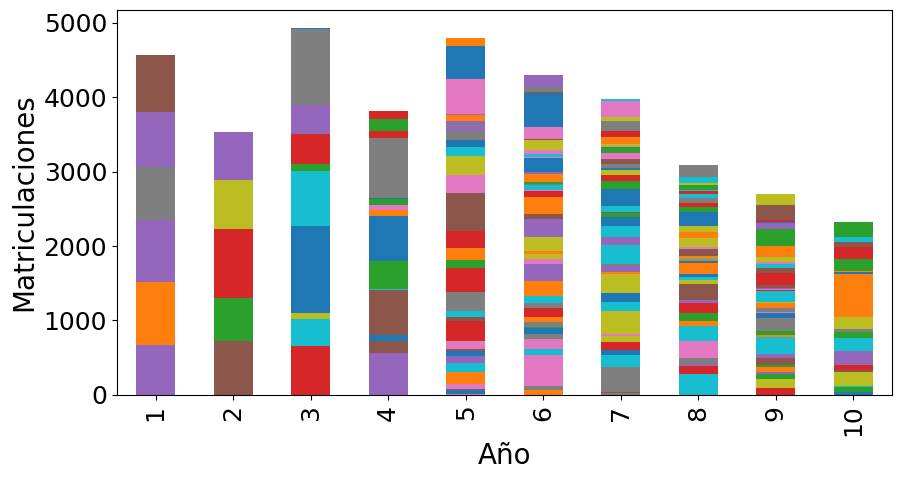

In [23]:
df=data.groupby(['Semestre','Asignatura'])['Idalumno'].nunique()
carreras=np.unique(dfg.values).tolist()
f, ax = plt.subplots(figsize=(10, 5))

df.unstack().plot(kind='bar', stacked=True,ax=ax)
#ax.legend(carreras)
#plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))

ax.get_legend().remove()
plt.xlabel("Año")
plt.ylabel("Matriculaciones")
plt.show()

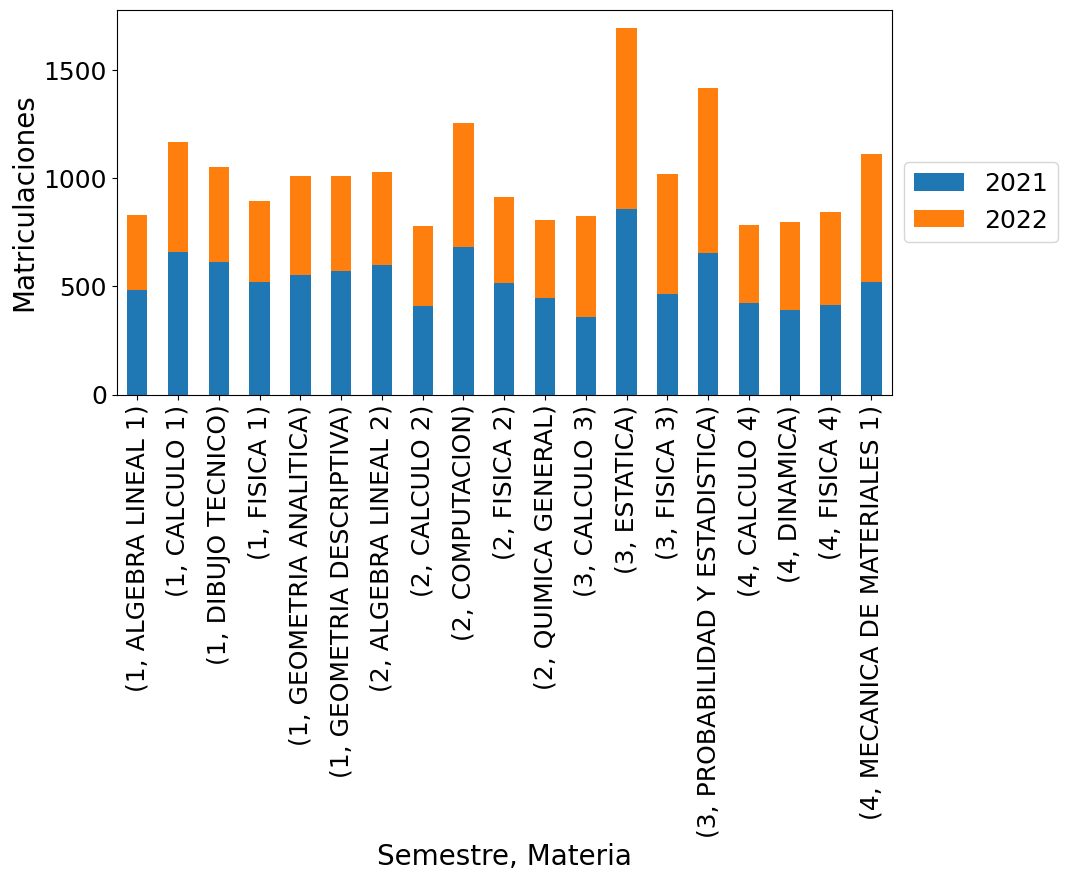

In [24]:

df=data[data.Semestre<=4].groupby(['Semestre','Asignatura','Anho'])['Idalumno'].nunique()
df=df[df.values>np.percentile(df.values,50)]
f, ax = plt.subplots(figsize=(10, 5))

df.unstack().plot(kind='bar', stacked=True,ax=ax)
#ax.legend(carreras)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))

#ax.get_legend().remove()
plt.xlabel("Semestre, Materia")
plt.ylabel("Matriculaciones")
plt.show()

In [25]:
data['GrupoFinal']=data.NF.values
grupo=np.logical_and(data.NF.values>1,data.AnhoFirma.values==data.Anho.values)
print(np.sum(grupo))
data['GrupoFinal'][grupo]='Paso1ra'
grupo=np.logical_and(data.NF.values>1,data.AnhoFirma.values<data.Anho.values)
print(np.sum(grupo))

data['GrupoFinal'][grupo]='Paso2da'
grupo=np.logical_and(data.NF.values==1,data.AnhoFirma.values==data.Anho.values)
print(np.sum(grupo))
data['GrupoFinal'][grupo]='FirmaNoPaso'
grupo=np.logical_and(data.NF.values==1,data.AnhoFirma.values<data.Anho.values)
print(np.sum(grupo))
data['GrupoFinal'][grupo]='FirmaPreviaNoPaso'
grupo=data.NF.values==0
print(np.sum(grupo))

data['GrupoFinal'][grupo]='NoLLegoFinal'

26250
1691
2899
419
22563


C:\Users\yoda\AppData\Local\Temp\ipykernel_5452\3706601779.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['GrupoFinal'][grupo]='Paso1ra'


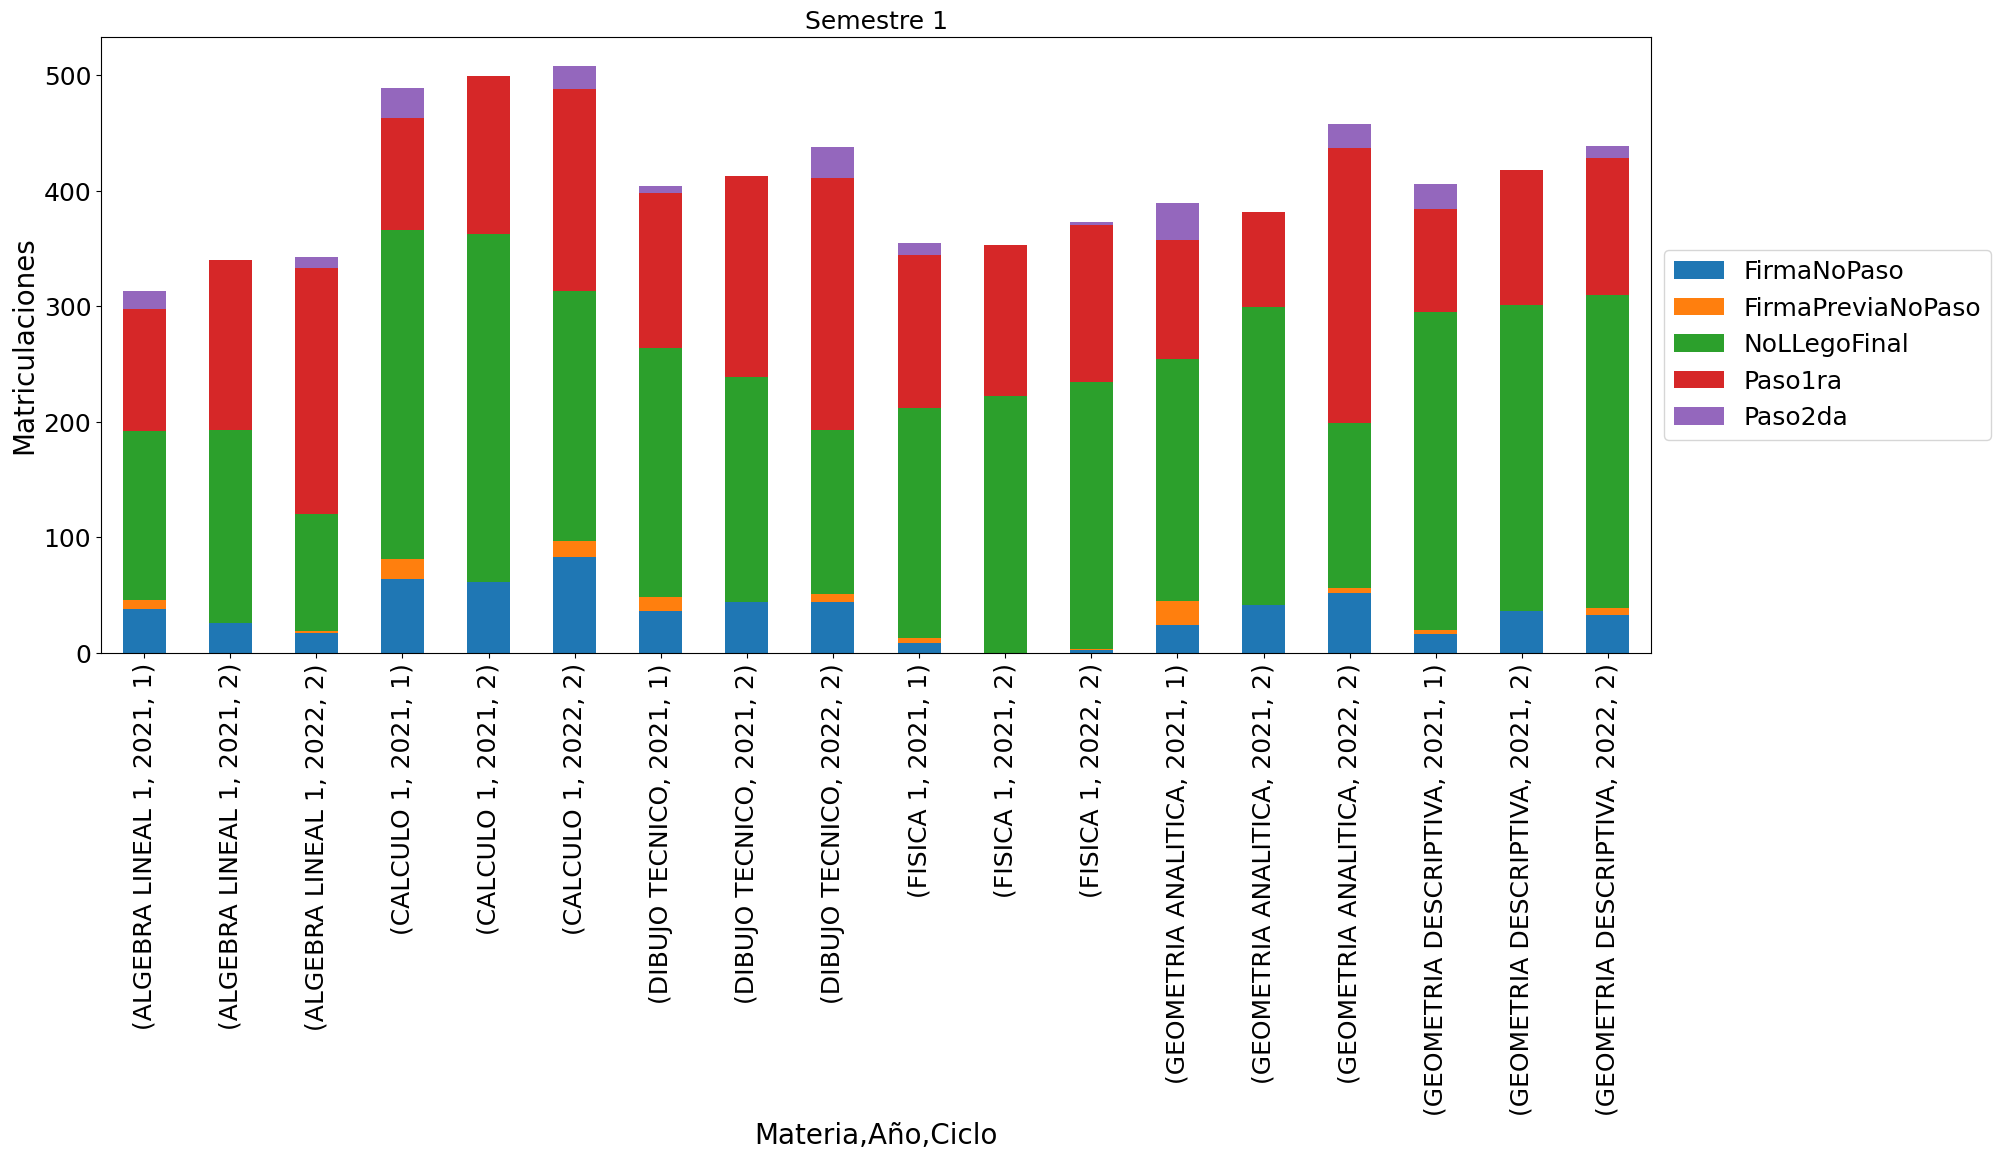

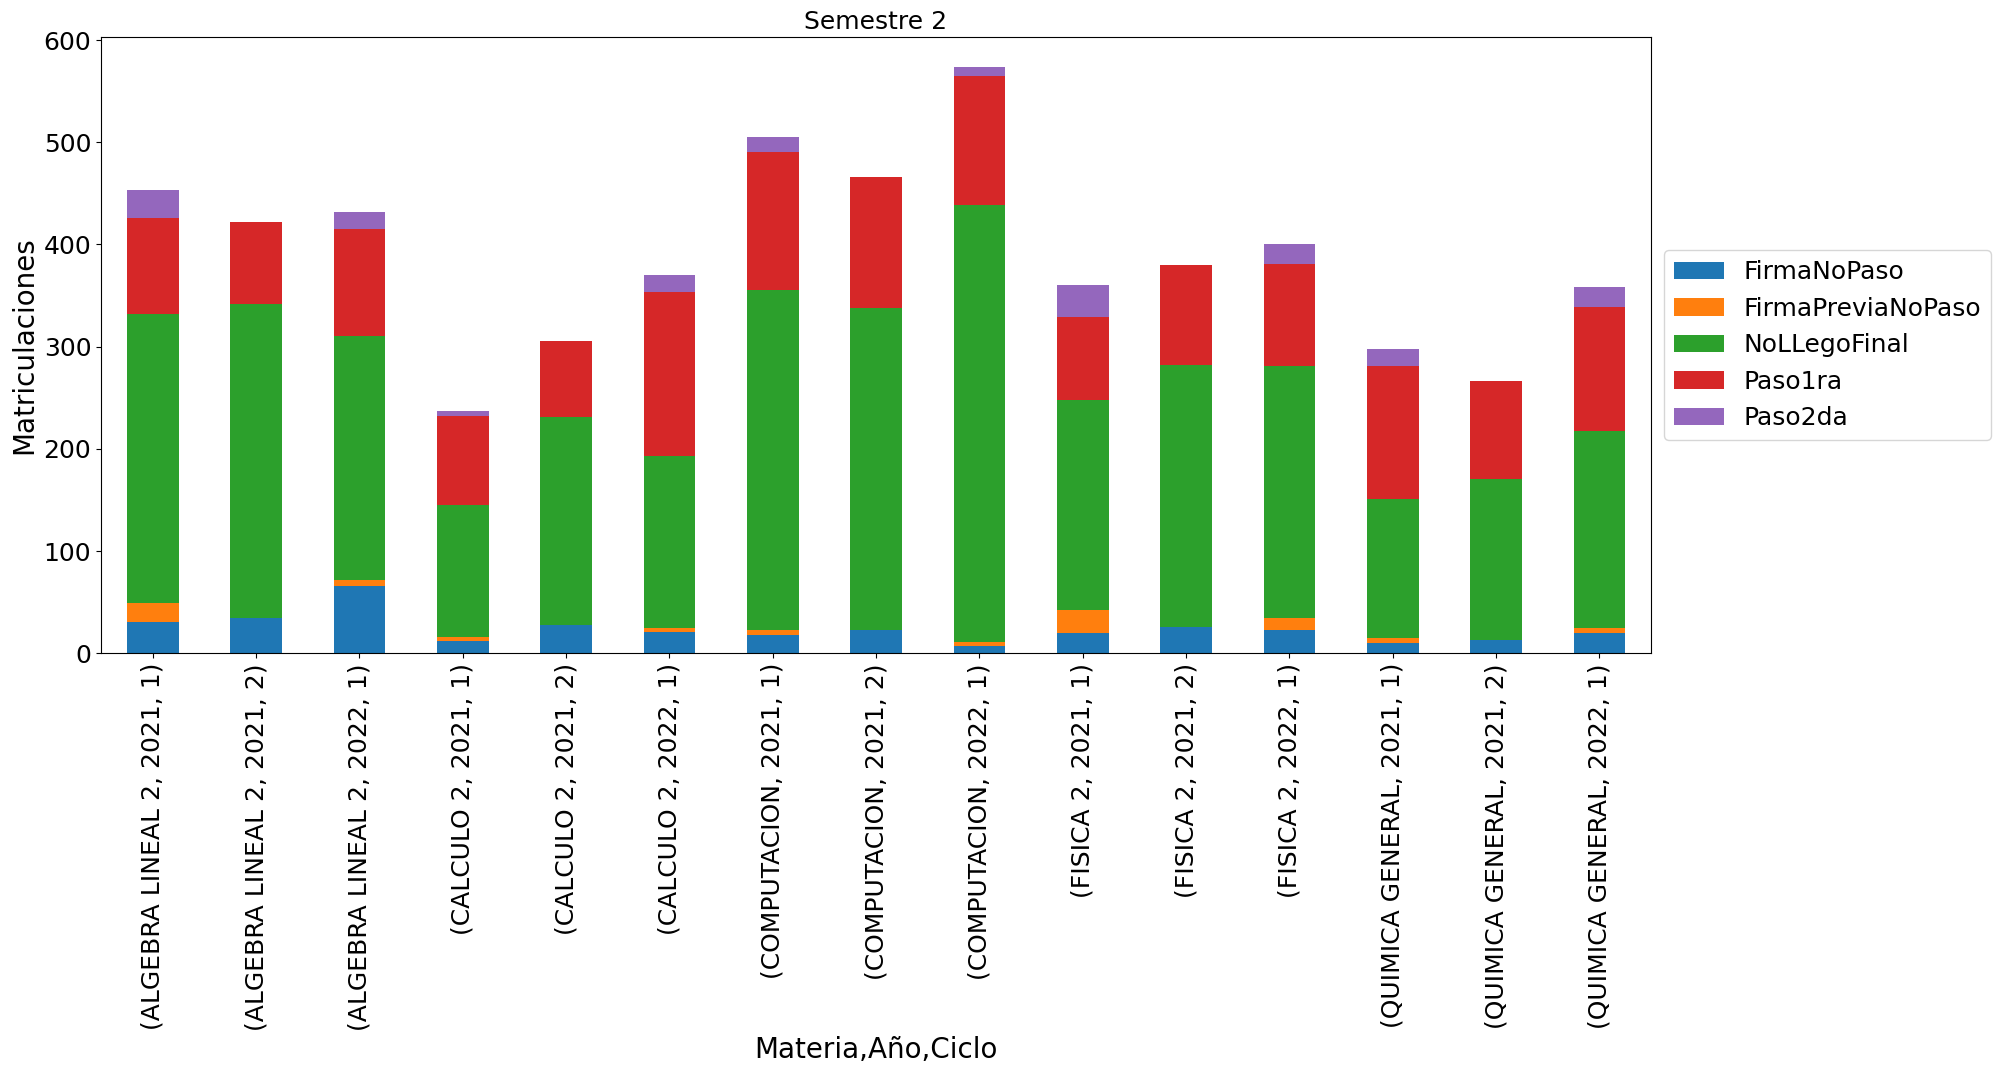

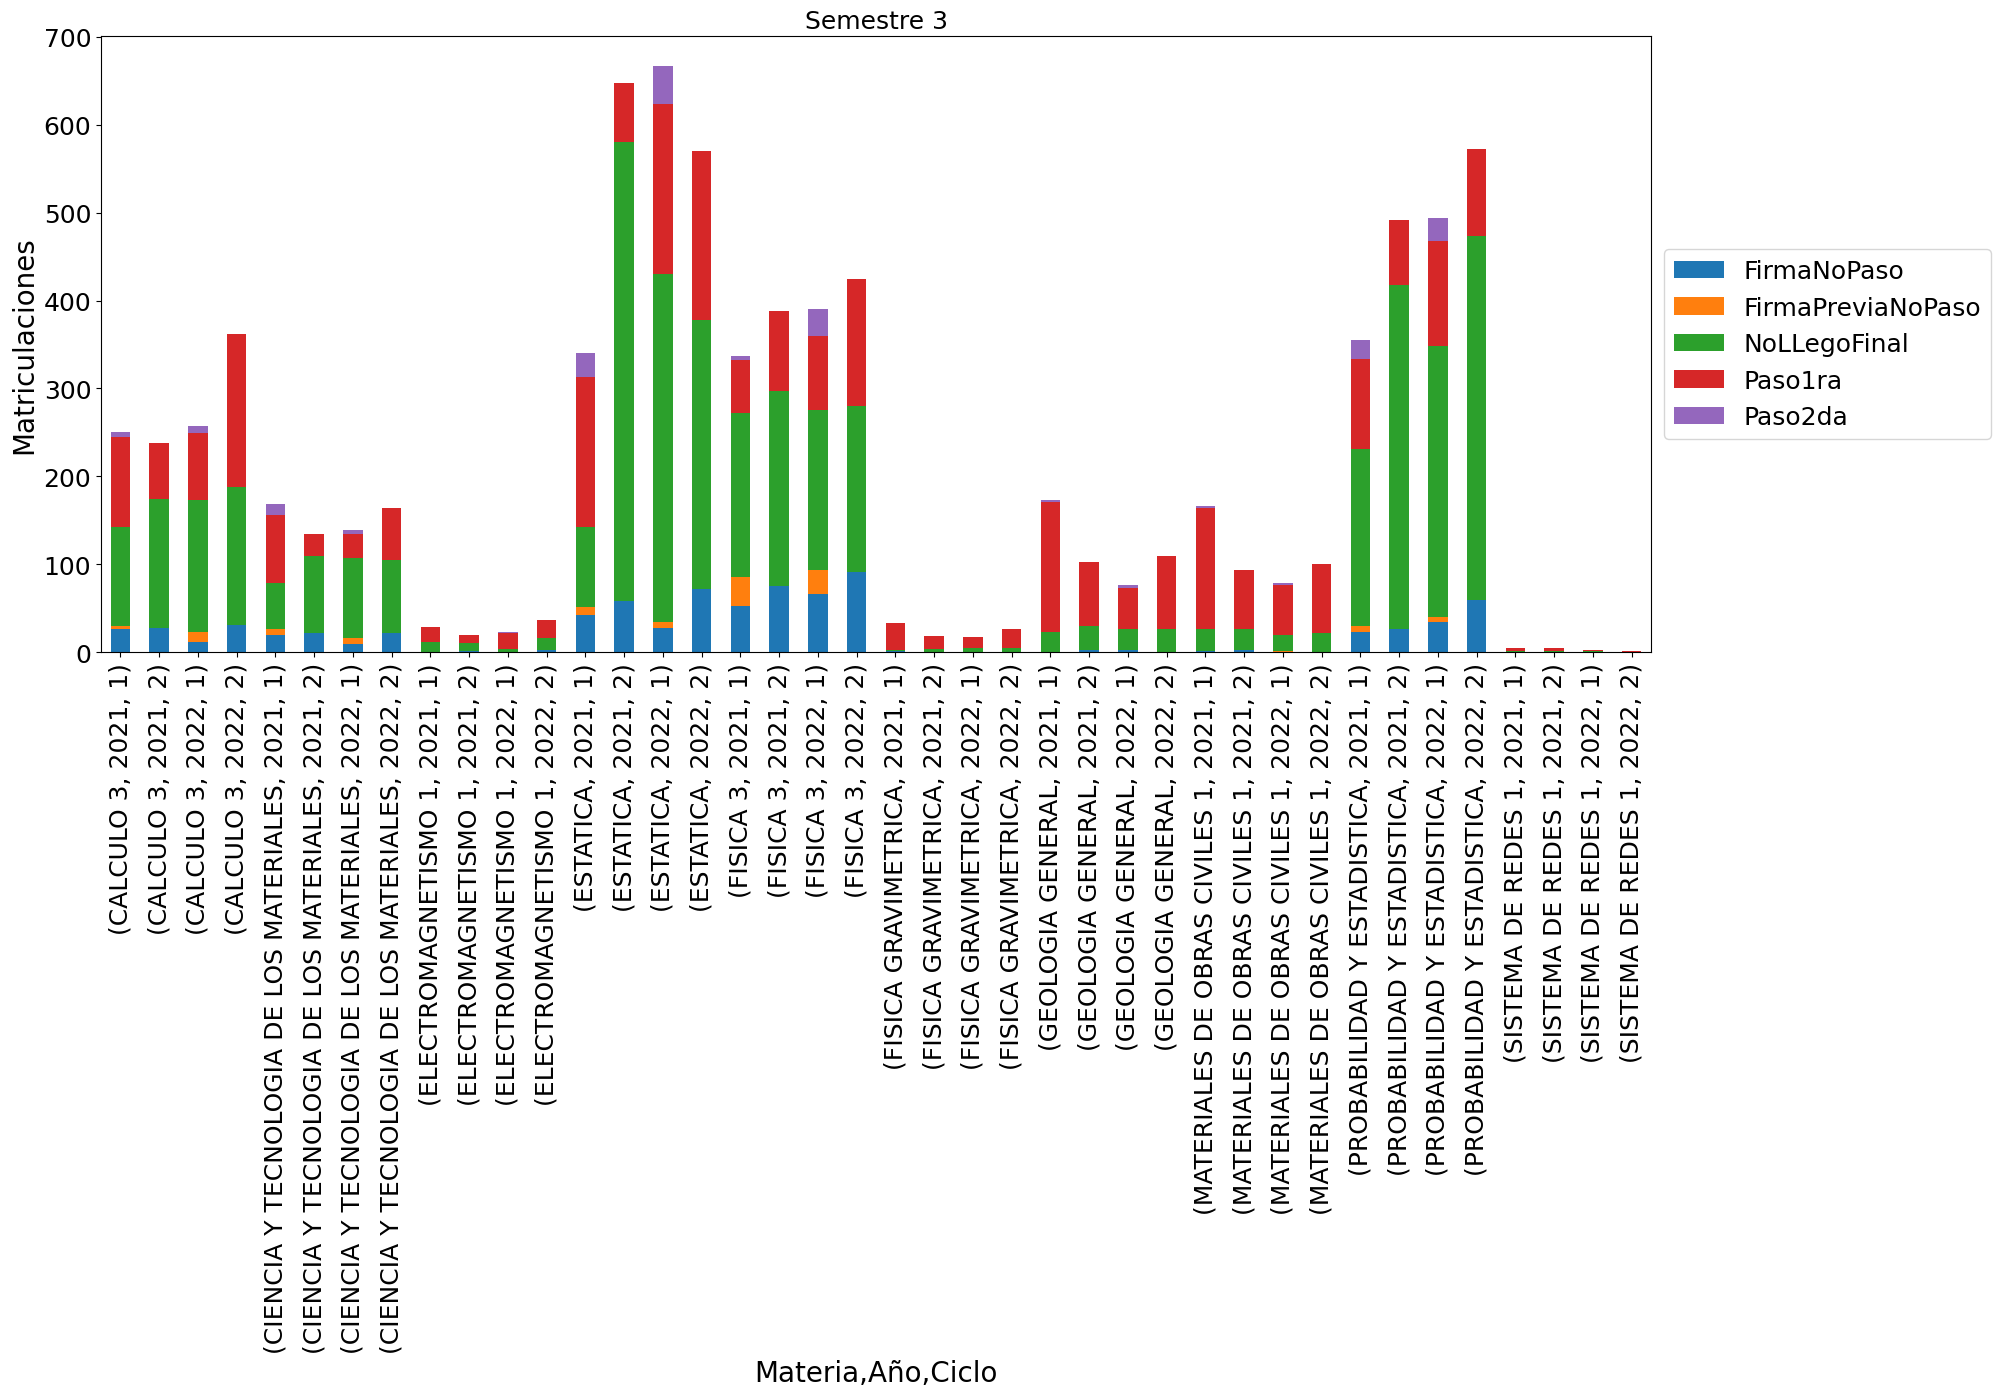

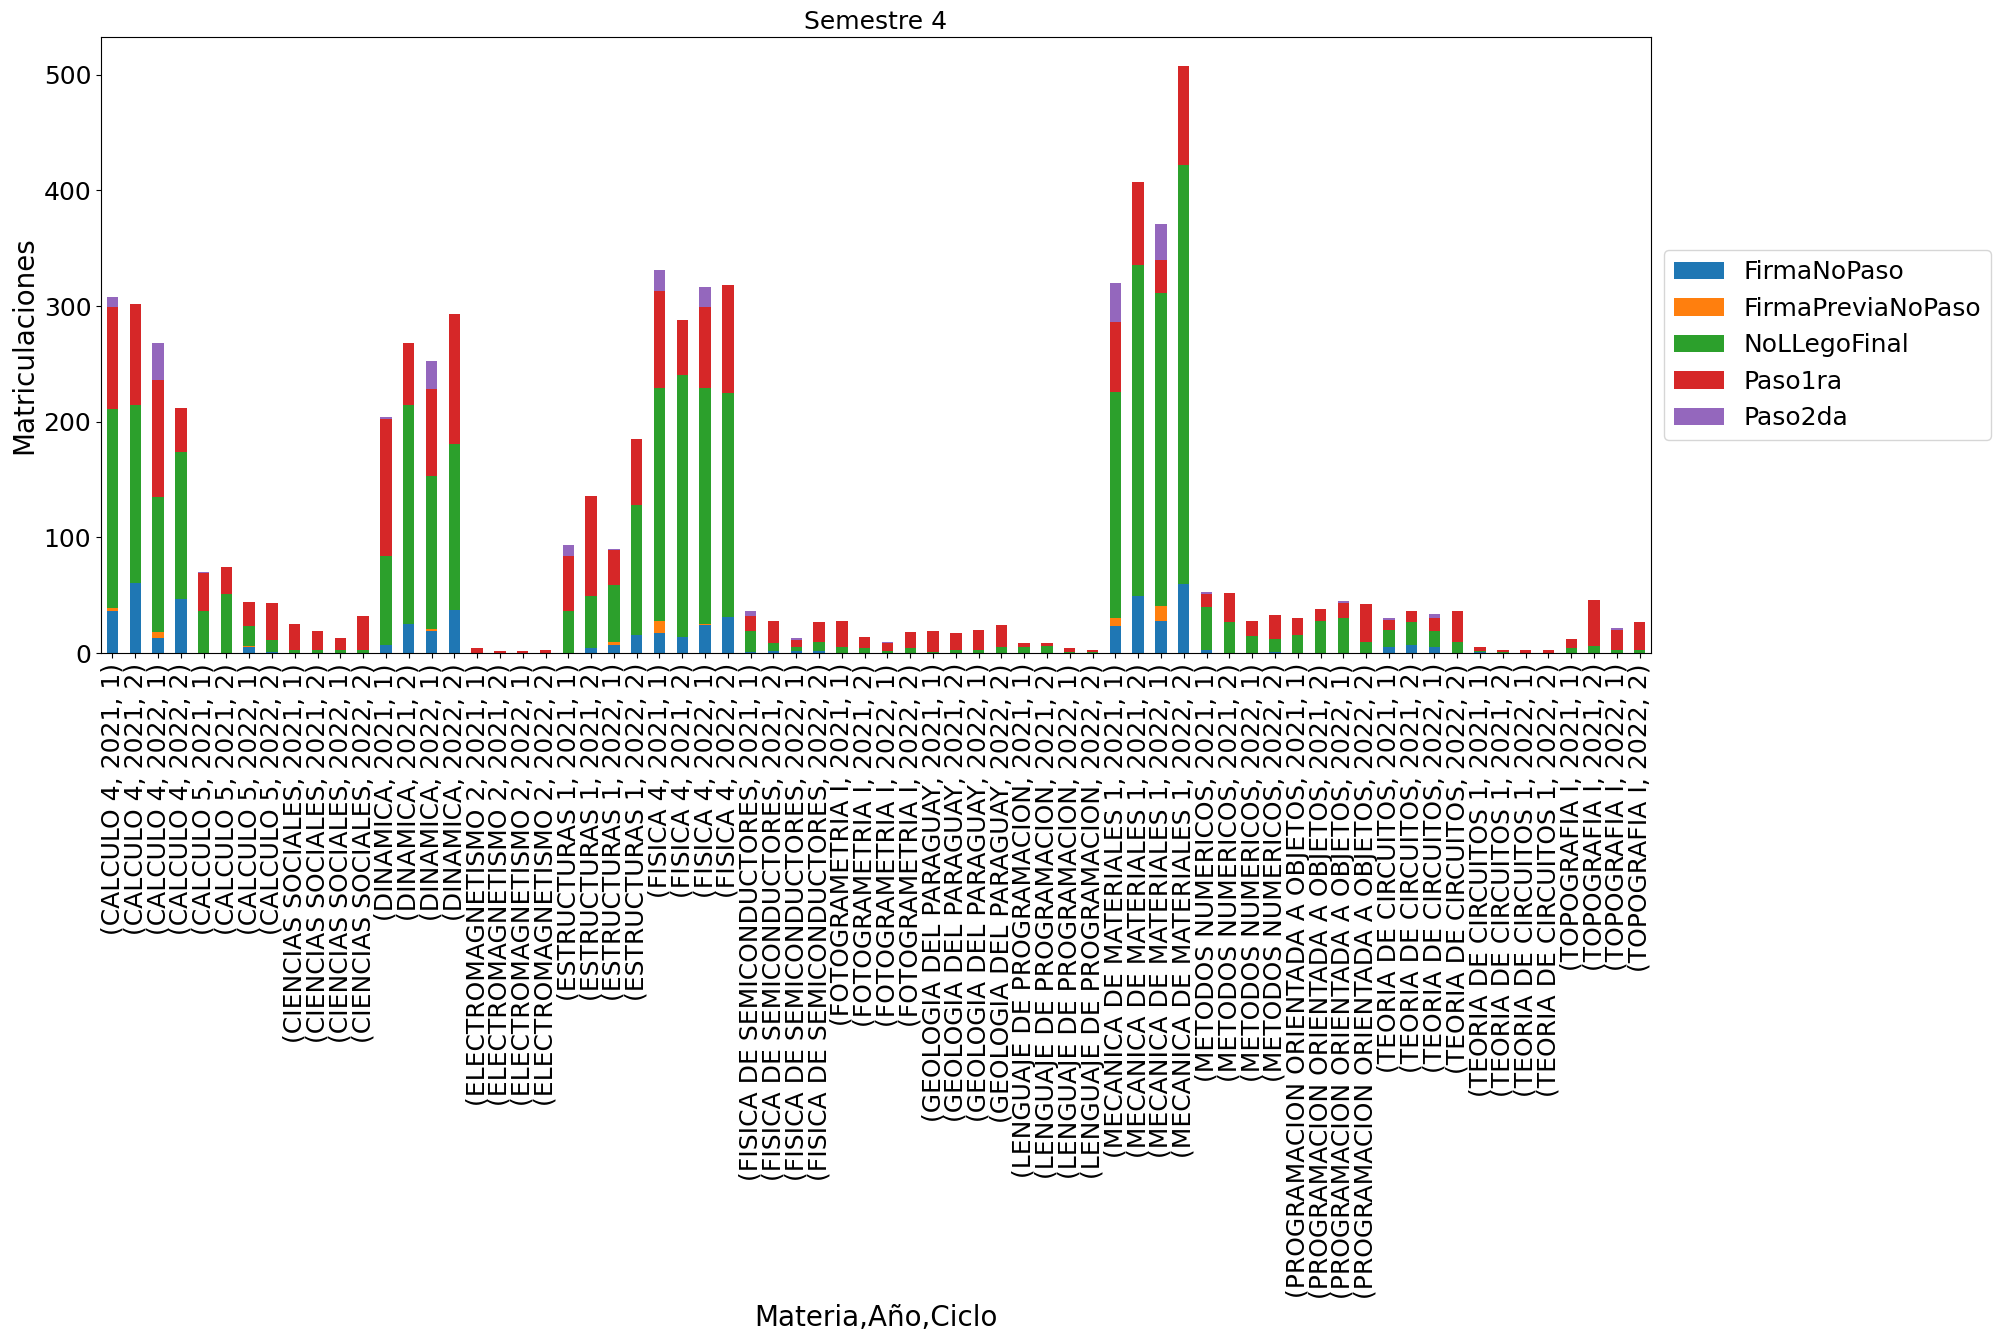

In [26]:

if True:
#for carrera in  np.unique(data.CarreraCod.values): 
  #  print(carrera)
    for semestre in [1,2,3,4]:
        df=data
       # df=data[data.CarreraCod.values==carrera]
        dfg=df[df.Semestre==semestre].groupby(['Asignatura'])['Idalumno'].nunique()
        #for asig in dfg.index[dfg<100].tolist():
      #      df=df[df.Asignatura!=asig]
        
        df=df[df.Semestre==semestre].groupby(['Asignatura','Anho','ciclo','GrupoFinal'])['Idalumno'].nunique()
        if(len(df)==0):
            continue
        # df=df[df.values>50]
        f, ax = plt.subplots(figsize=(20, 8))
        ax.set_title("Semestre "+str(semestre))

        df.unstack().plot(kind='bar', stacked=True,ax=ax)
        #ax.legend(carreras)
        plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))

        #ax.get_legend().remove()
        plt.xlabel("Materia,Año,Ciclo")
        plt.ylabel("Matriculaciones")
        plt.savefig("graficos\GraficoGlobal"+str(semestre)+".png", bbox_inches="tight")
        plt.show()

In [27]:
data['GrupoNoFinal']=data.NF.values
grupo=np.logical_and(data.NF.values==0,data.AnhoFirma.values==data.Anho.values)
print(np.sum(grupo))
a=np.sum(grupo)
data['GrupoNoFinal'][grupo]='Firma'
grupo=np.logical_and(data.NF.values==0,data.AnhoFirma.values<data.Anho.values)
grupo=np.logical_and(grupo,data.AnhoFirma.values>0)
print(np.sum(grupo))
a+=np.sum(grupo)
data['GrupoNoFinal'][grupo]='FirmaPrevia'
grupo=np.logical_and(data.NF.values==0,data.AnhoFirma.values==0)
grupo=np.logical_and(grupo,data.AnhoFirma.values==0)
grupo=np.logical_and(grupo,data.Requisito.values==0)
grupo=np.logical_and(grupo,np.logical_and(data['1P'].values>=12,data['2P'].values<18))
grupo=np.logical_and(grupo,data['2P'].values>0)
print(np.sum(grupo))
a+=np.sum(grupo)
data['GrupoNoFinal'][grupo]='SinFirmaSinRq1pGood2PBad'
grupo=np.logical_and(data.NF.values==0,data.AnhoFirma.values==0)
grupo=np.logical_and(grupo,data.AnhoFirma.values==0)
grupo=np.logical_and(grupo,data.Requisito.values==0)
grupo=np.logical_and(grupo,np.logical_and(data['1P'].values<12,data['2P'].values>=18))
print(np.sum(grupo))
a+=np.sum(grupo)
data['GrupoNoFinal'][grupo]='SinFirmaSinRq1pBad2pGood'
grupo=np.logical_and(data.NF.values==0,data.AnhoFirma.values==0)
grupo=np.logical_and(grupo,data.AnhoFirma.values==0)
grupo=np.logical_and(grupo,data.Requisito.values==0)
grupo=np.logical_and(grupo,np.logical_and(data['1P'].values<12,data['2P'].values<=18))
grupo=np.logical_and(grupo,data['2P'].values>0)
print(np.sum(grupo))
a+=np.sum(grupo)
data['GrupoNoFinal'][grupo]='SinFirmaSinRq1pBad2pBad'
grupo=np.logical_and(data.NF.values==0,data.AnhoFirma.values==0)
grupo=np.logical_and(grupo,data.AnhoFirma.values==0)
grupo=np.logical_and(grupo,data.Requisito.values==0)
grupo=np.logical_and(grupo,np.logical_and(data['1P'].values<12,np.logical_and(data['2P'].values>=0,data['2P'].values<=18)))
grupo=np.logical_and(grupo,data['2P'].values==0)
print(np.sum(grupo))
a+=np.sum(grupo)
data['GrupoNoFinal'][grupo]='SinFirmaSinRq1pBad2p0'
#grupo=np.logical_and(data.NF.values==0,data.AnhoFirma.values==0)
#grupo=np.logical_and(grupo,data.AnhoFirma.values==0)
#grupo=np.logical_and(grupo,data.Requisito.values==0)
#grupo=np.logical_and(grupo,np.logical_and(data['1P'].values<12,data['2P'].values>=18))
#print(np.sum(grupo))
#data['GrupoNoFinal'][grupo]='SinFirmaSinRq1pGood2p'
grupo=np.logical_and(data.NF.values==0,data.AnhoFirma.values==0)
grupo=np.logical_and(grupo,data.AnhoFirma.values==0)
grupo=np.logical_and(grupo,data.Requisito.values==1)
grupo=np.logical_and(grupo,data['Taller'].values>=5)
grupo=np.logical_and(grupo,np.logical_or(data['1P'].values>=12,data['2P'].values>=18))
grupo=np.logical_and(grupo,np.logical_or(data['1R'].values>0,data['2R'].values>0))
print(np.sum(grupo))
a+=np.sum(grupo)
data['GrupoNoFinal'][grupo]='SinFirmaReqEx50RindioRec'
grupo=np.logical_and(data.NF.values==0,data.AnhoFirma.values==0)
grupo=np.logical_and(grupo,data.AnhoFirma.values==0)
grupo=np.logical_and(grupo,data.Requisito.values==1)
grupo=np.logical_and(grupo,data['Taller'].values>=5)
grupo=np.logical_and(grupo,np.logical_or(data['1P'].values>=12,data['2P'].values>=18))
grupo=np.logical_and(grupo,np.logical_and(data['1R'].values==0,data['2R'].values==0))
print(np.sum(grupo))
a+=np.sum(grupo)
data['GrupoNoFinal'][grupo]='SinFirmaReqEx50NoRindioRec'
grupo=data.GrupoNoFinal.values==0
grupo=np.logical_and(grupo,data['1P'].values>=12)
grupo=np.logical_and(grupo,data['1P'].values<18)
#=np.logical_and(grupo,data.Requisito.values>0)
print(np.sum(grupo))
a+=np.sum(grupo)
data['GrupoNoFinal'][grupo]='SinFirmaReqProces1Pgood2Pbad'
print(np.sum(grupo))
grupo=data.GrupoNoFinal.values==0
grupo=np.logical_and(grupo,data['1P'].values<12)
grupo=np.logical_and(grupo,data['1P'].values>=18)
#=np.logical_and(grupo,data.Requisito.values>0)
print(np.sum(grupo))
a+=np.sum(grupo)
data['GrupoNoFinal'][grupo]='SinFirmaReqProceso1Pbad2Pgood'
grupo=data.GrupoNoFinal.values==0
grupo=np.logical_and(grupo,data['1P'].values>=12)
grupo=np.logical_and(grupo,data['1P'].values>=18)
#=np.logical_and(grupo,data.Requisito.values>0)
print(np.sum(grupo))
a+=np.sum(grupo)
data['GrupoNoFinal'][grupo]='SinFirmaReqProceso1Pgood2Pgood'
grupo=data.GrupoNoFinal.values==0
grupo=np.logical_and(grupo,data['1P'].values<12)
grupo=np.logical_and(grupo,data['1P'].values<18)
#=np.logical_and(grupo,data.Requisito.values>0)
print(np.sum(grupo))
a+=np.sum(grupo)
data['GrupoNoFinal'][grupo]='SinFirmaReqProceso1Pbad2Pbad'

print(a)

3087
448
150
61
2179
10209
531
569
903
903
0
129
4307
22573


C:\Users\yoda\AppData\Local\Temp\ipykernel_5452\2920869515.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['GrupoNoFinal'][grupo]='Firma'


In [28]:
np.sum(data.NF.values==0)

22563

Asignatura
ALGEBRA LINEAL 1         672
CALCULO 1                850
DIBUJO TECNICO           833
FISICA 1                 705
GEOMETRIA ANALITICA      743
GEOMETRIA DESCRIPTIVA    764
Name: Idalumno, dtype: int64


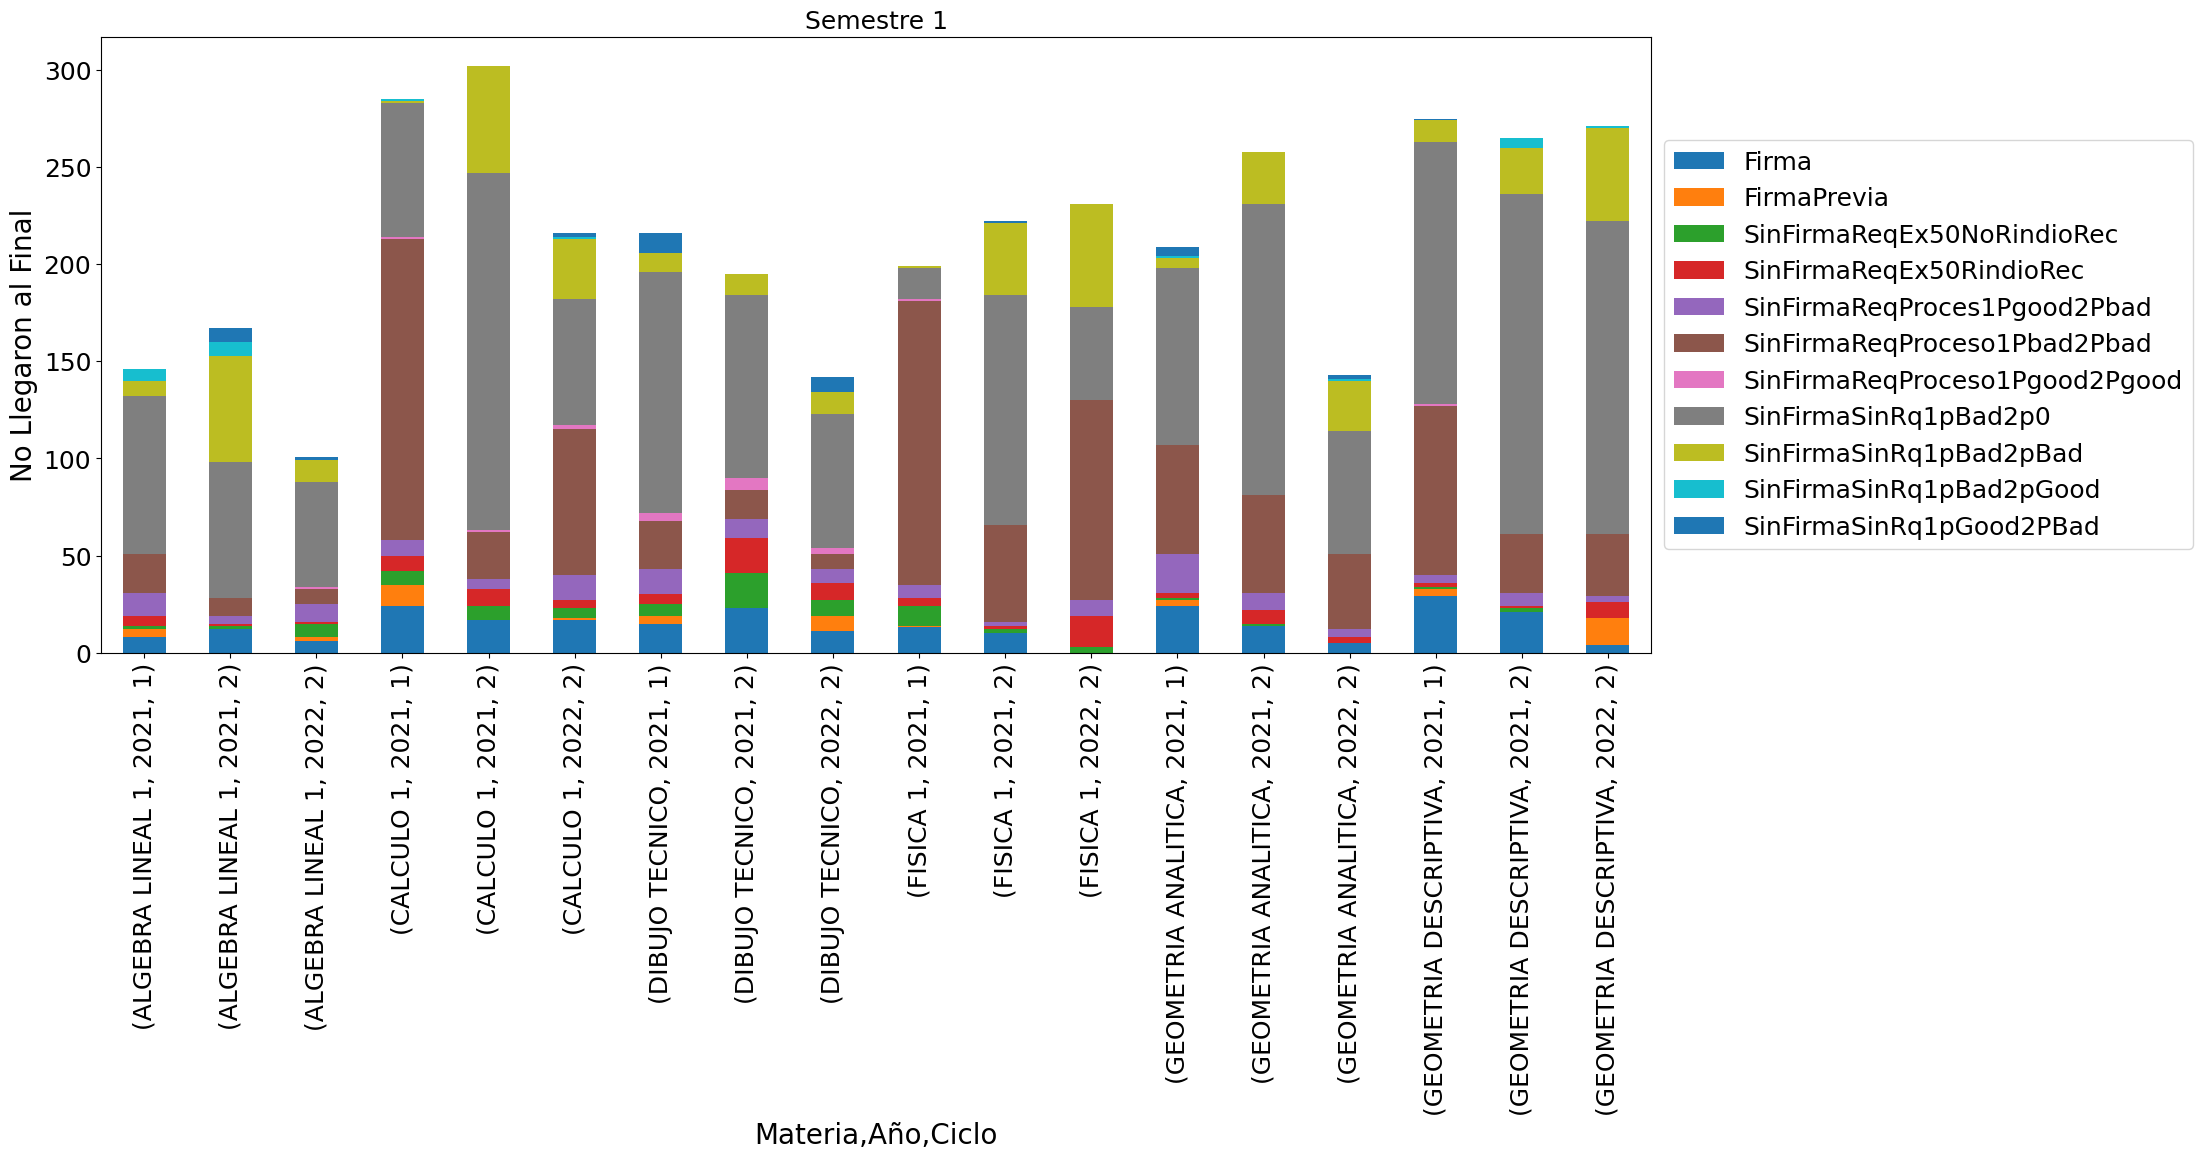

Asignatura
ALGEBRA LINEAL 2    724
CALCULO 2           572
COMPUTACION         929
FISICA 2            655
QUIMICA GENERAL     646
Name: Idalumno, dtype: int64


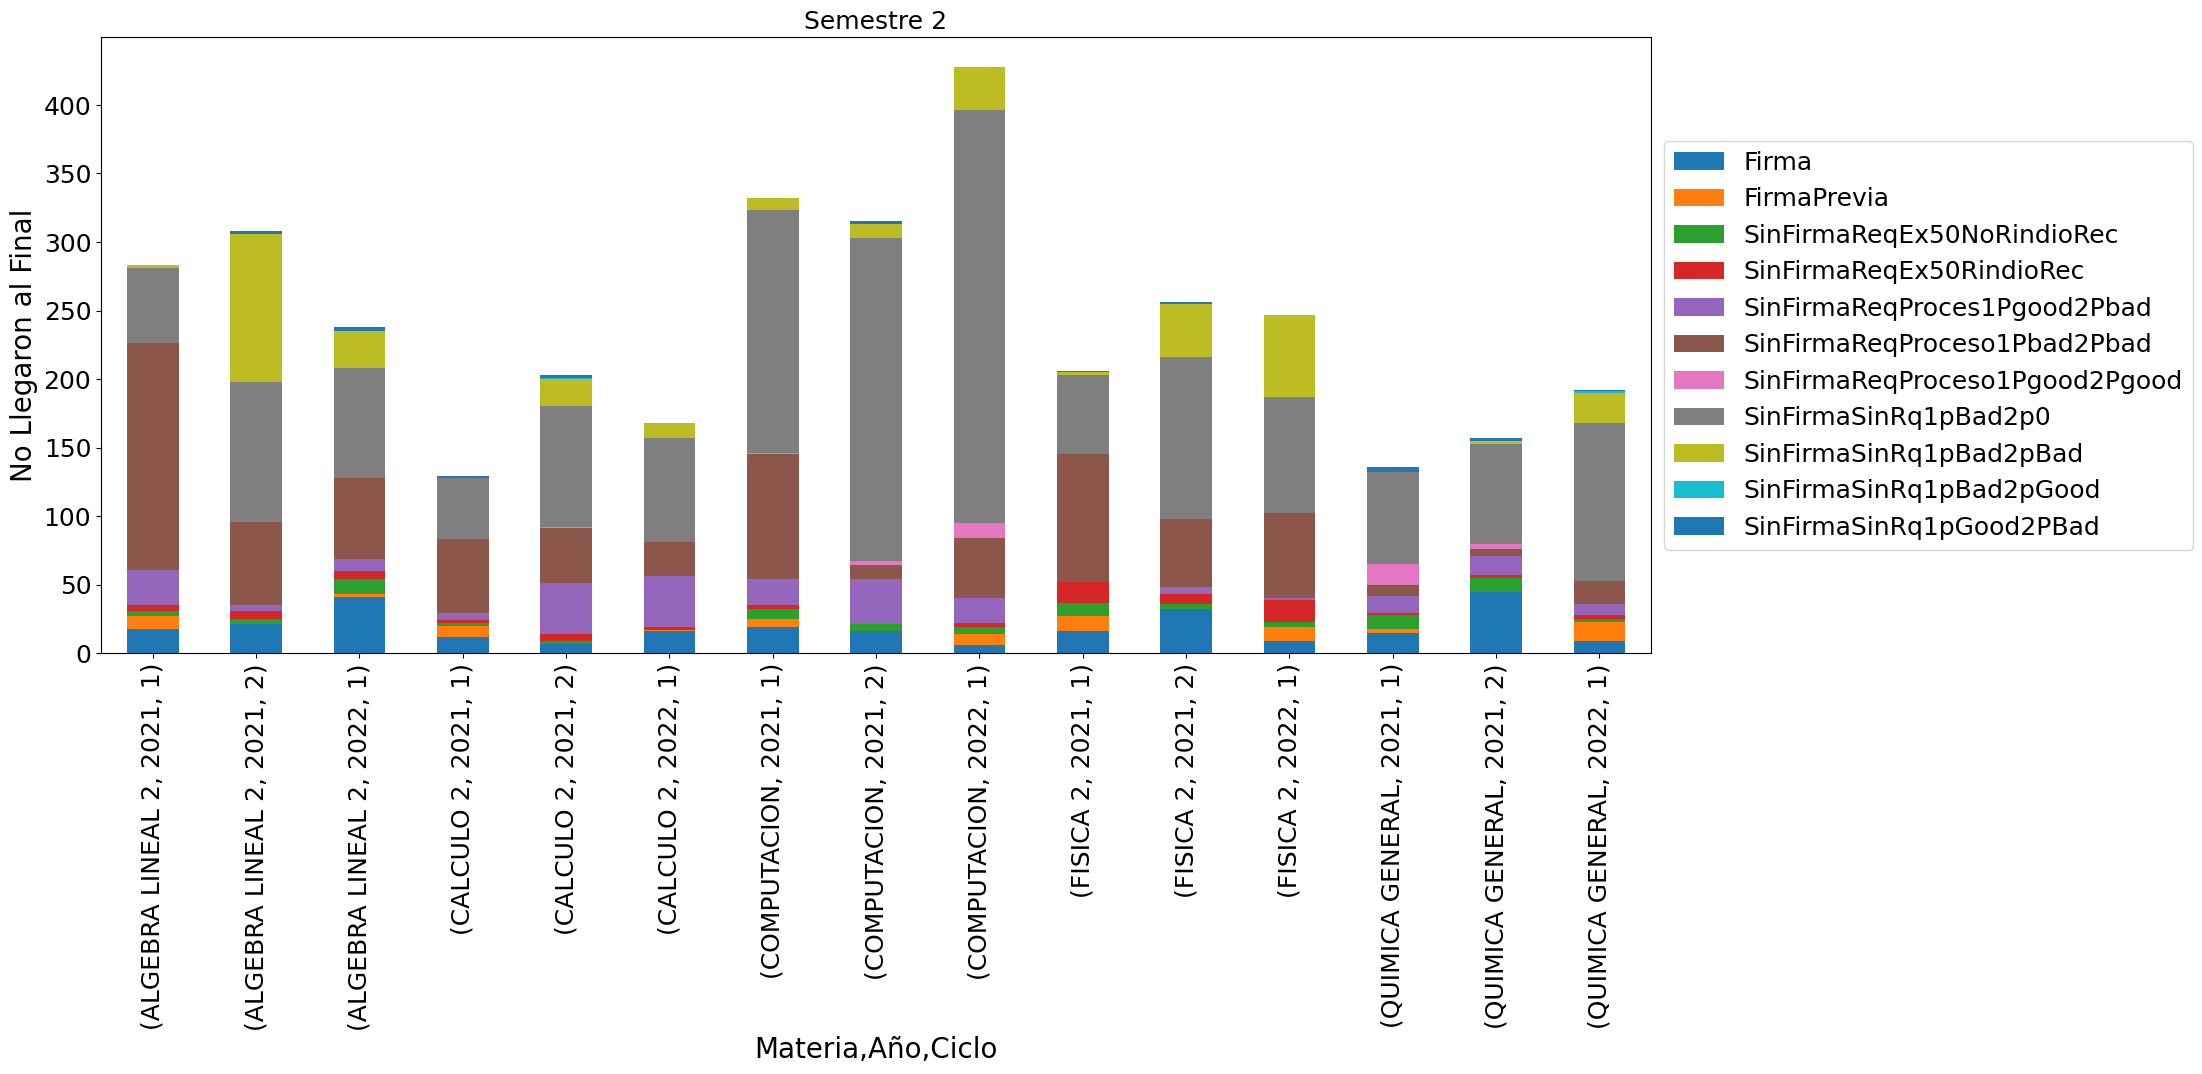

Asignatura
CALCULO 3                                  654
CIENCIA Y TECNOLOGIA DE LOS MATERIALES     360
ELECTROMAGNETISMO 1                         86
ESTATICA                                  1172
FISICA 3                                   735
FISICA GRAVIMETRICA                         91
GEOLOGIA GENERAL                           404
MATERIALES DE OBRAS CIVILES 1              386
PROBABILIDAD Y ESTADISTICA                1021
SISTEMA DE REDES 1                          14
Name: Idalumno, dtype: int64


C:\Users\yoda\AppData\Local\Temp\ipykernel_5452\3979880553.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df=df[data.Asignatura!=asig]
C:\Users\yoda\AppData\Local\Temp\ipykernel_5452\3979880553.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df=df[data.Asignatura!=asig]


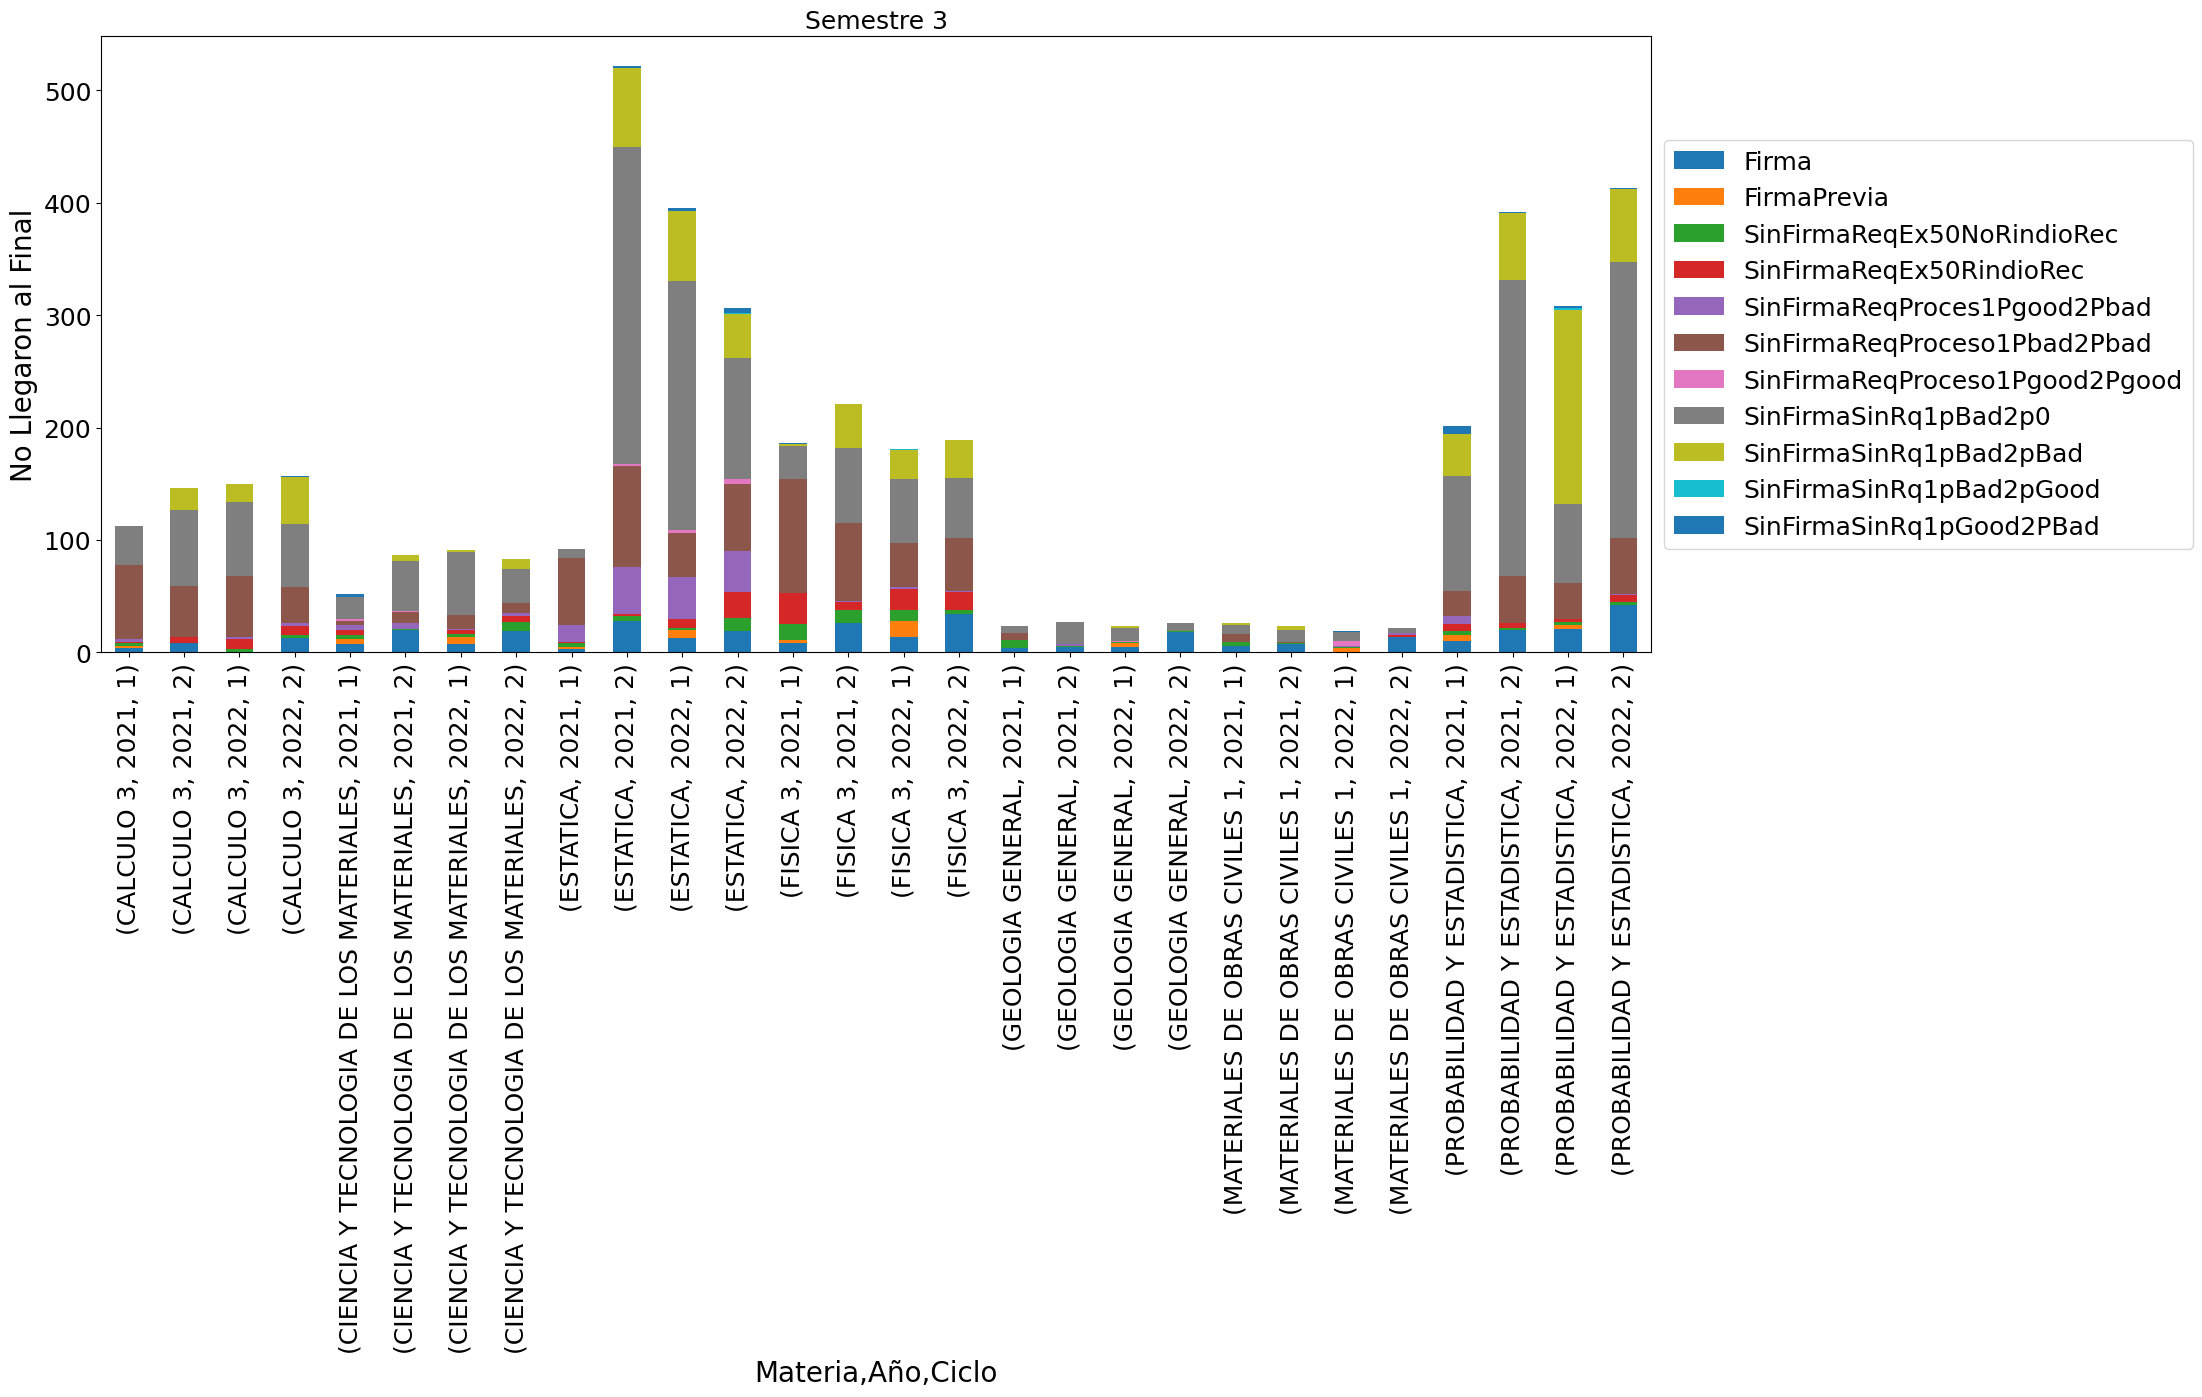

Asignatura
CALCULO 4                           570
CALCULO 5                           153
CIENCIAS SOCIALES                    87
DINAMICA                            596
ELECTROMAGNETISMO 2                  11
ESTRUCTURAS 1                       379
FISICA 4                            610
FISICA DE SEMICONDUCTORES            77
FOTOGRAMETRIA I                      65
GEOLOGIA DEL PARAGUAY                77
LENGUAJE DE PROGRAMACION             19
MECANICA DE MATERIALES 1            805
METODOS NUMERICOS                    90
PROGRAMACION ORIENTADA A OBJETOS     96
TEORIA DE CIRCUITOS                  71
TEORIA DE CIRCUITOS 1                11
TOPOGRAFIA I                        101
Name: Idalumno, dtype: int64


C:\Users\yoda\AppData\Local\Temp\ipykernel_5452\3979880553.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df=df[data.Asignatura!=asig]
C:\Users\yoda\AppData\Local\Temp\ipykernel_5452\3979880553.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df=df[data.Asignatura!=asig]
C:\Users\yoda\AppData\Local\Temp\ipykernel_5452\3979880553.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df=df[data.Asignatura!=asig]
C:\Users\yoda\AppData\Local\Temp\ipykernel_5452\3979880553.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df=df[data.Asignatura!=asig]
C:\Users\yoda\AppData\Local\Temp\ipykernel_5452\3979880553.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df=df[data.Asignatura!=asig]
C:\Users\yoda\AppData\Local\Temp\ipykernel_5452\3979880553.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.

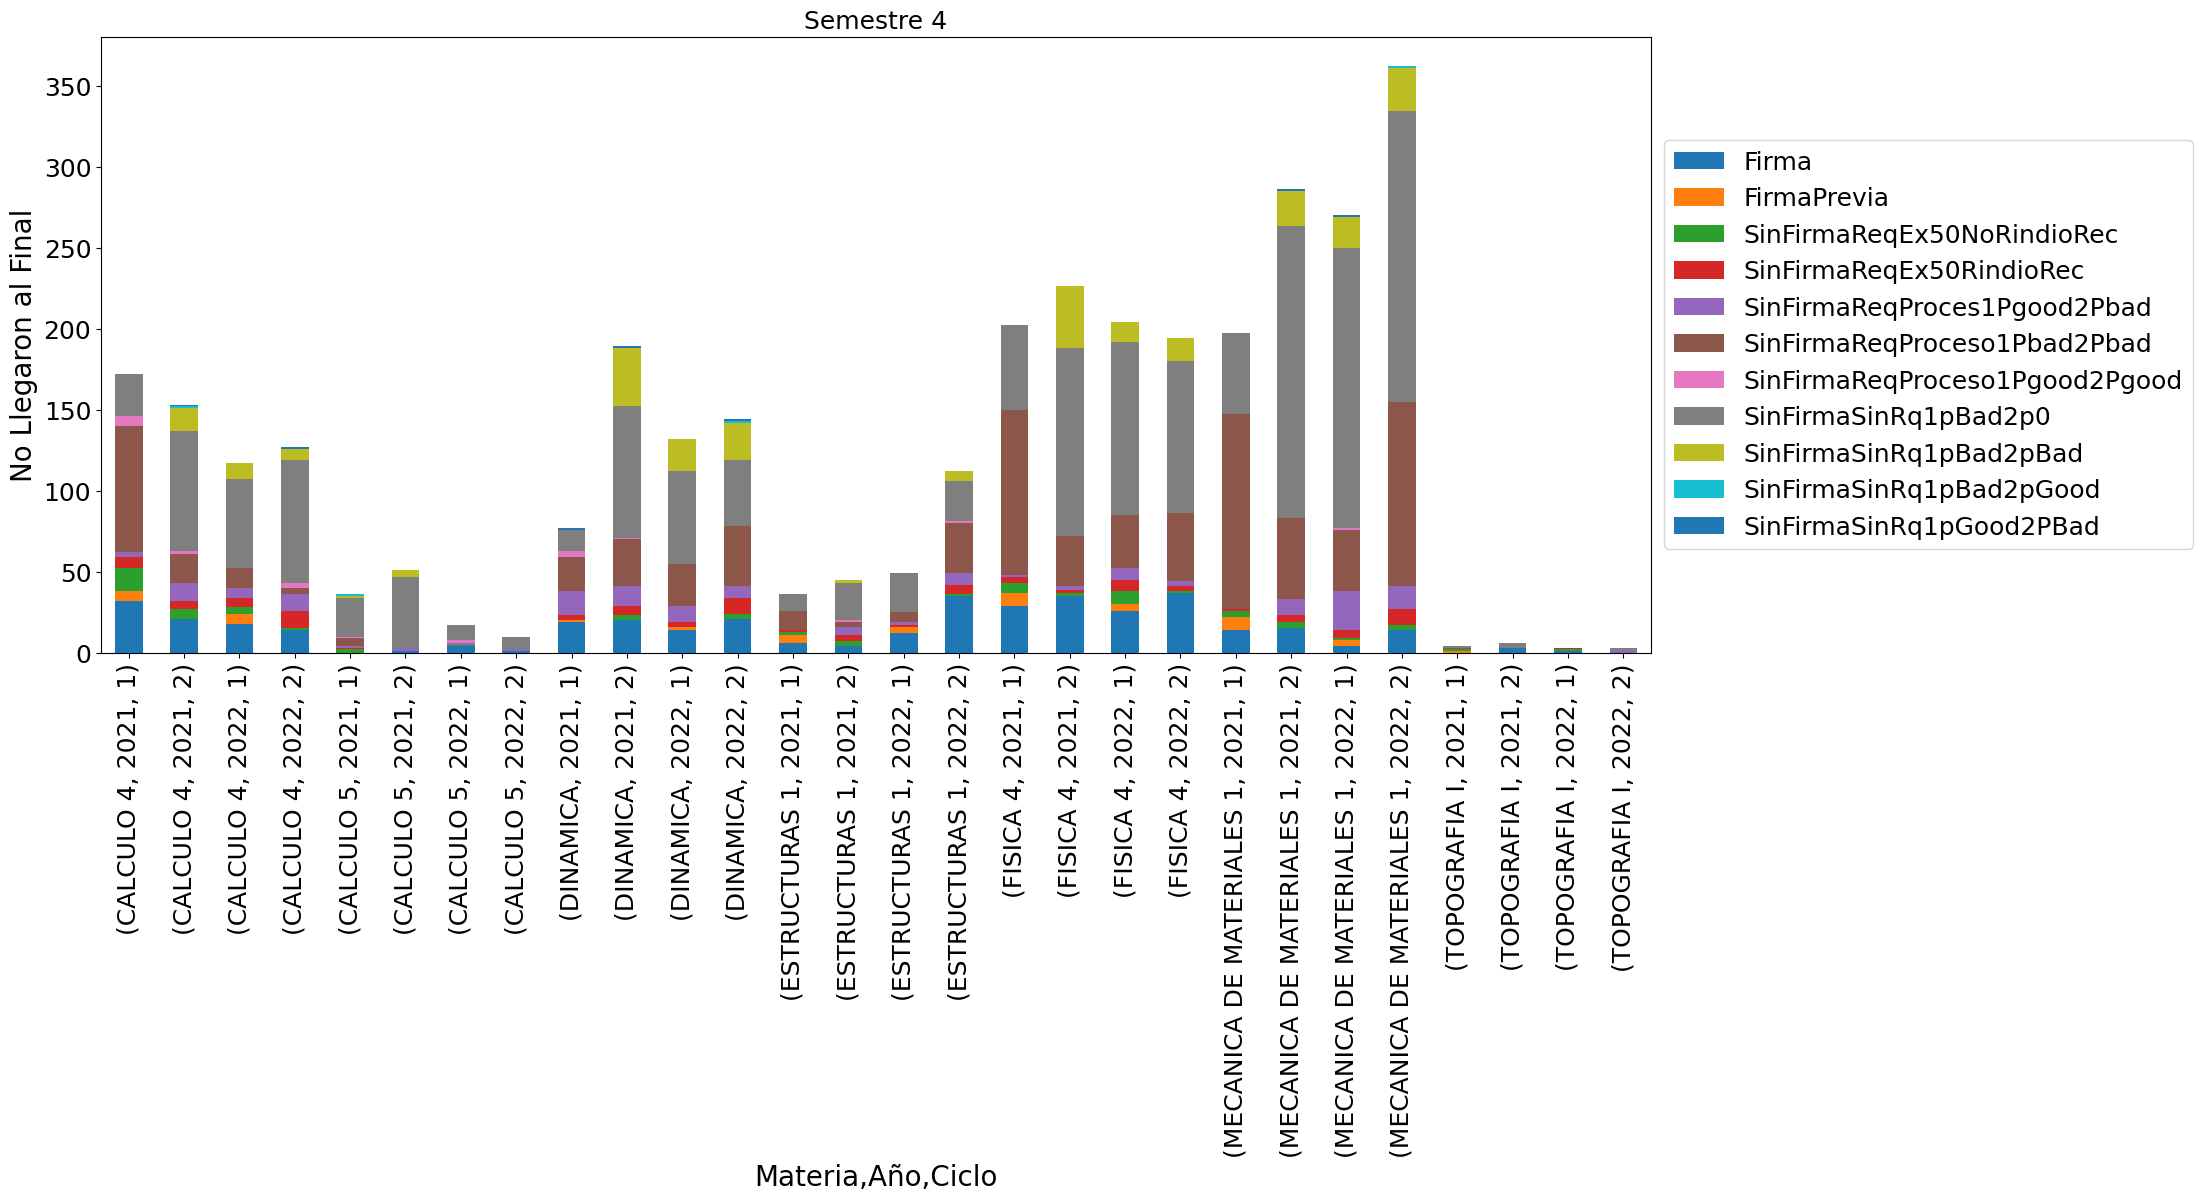

In [29]:
for semestre in [1,2,3,4]:
    dfg=data[data.Semestre==semestre].groupby(['Asignatura'])['Idalumno'].nunique()
    df=data
    print(dfg)
    for asig in dfg.index[dfg<100].tolist():
        df=df[data.Asignatura!=asig]
    df=df[np.logical_and(df.Semestre==semestre,df.NF.values==0)].groupby(['Asignatura','Anho','ciclo','GrupoNoFinal'])['Idalumno'].nunique()
    #df=df[df.values>np.percentile(df.values,50)]
    f, ax = plt.subplots(figsize=(20, 8))
    ax.set_title("Semestre "+str(semestre))

    df.unstack().plot(kind='bar', stacked=True,ax=ax)
    #ax.legend(carreras)
    plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))

    #ax.get_legend().remove()
    plt.xlabel("Materia,Año,Ciclo")
    plt.ylabel("No Llegaron al Final")
    plt.savefig("graficos\GraficoSinFinal"+str(semestre)+".png", bbox_inches="tight")
   
    plt.show()

2608
   Anho  ciclo  Idalumno  NA           GrupoNoFinal
0  2022      2        31   3  SinFirmaSinRq1pBad2p0
1  2022      2       127   5                      4
2  2022      2       127   5                      3
3  2022      2       127   5  SinFirmaSinRq1pBad2p0
4  2022      2       127   5                      5


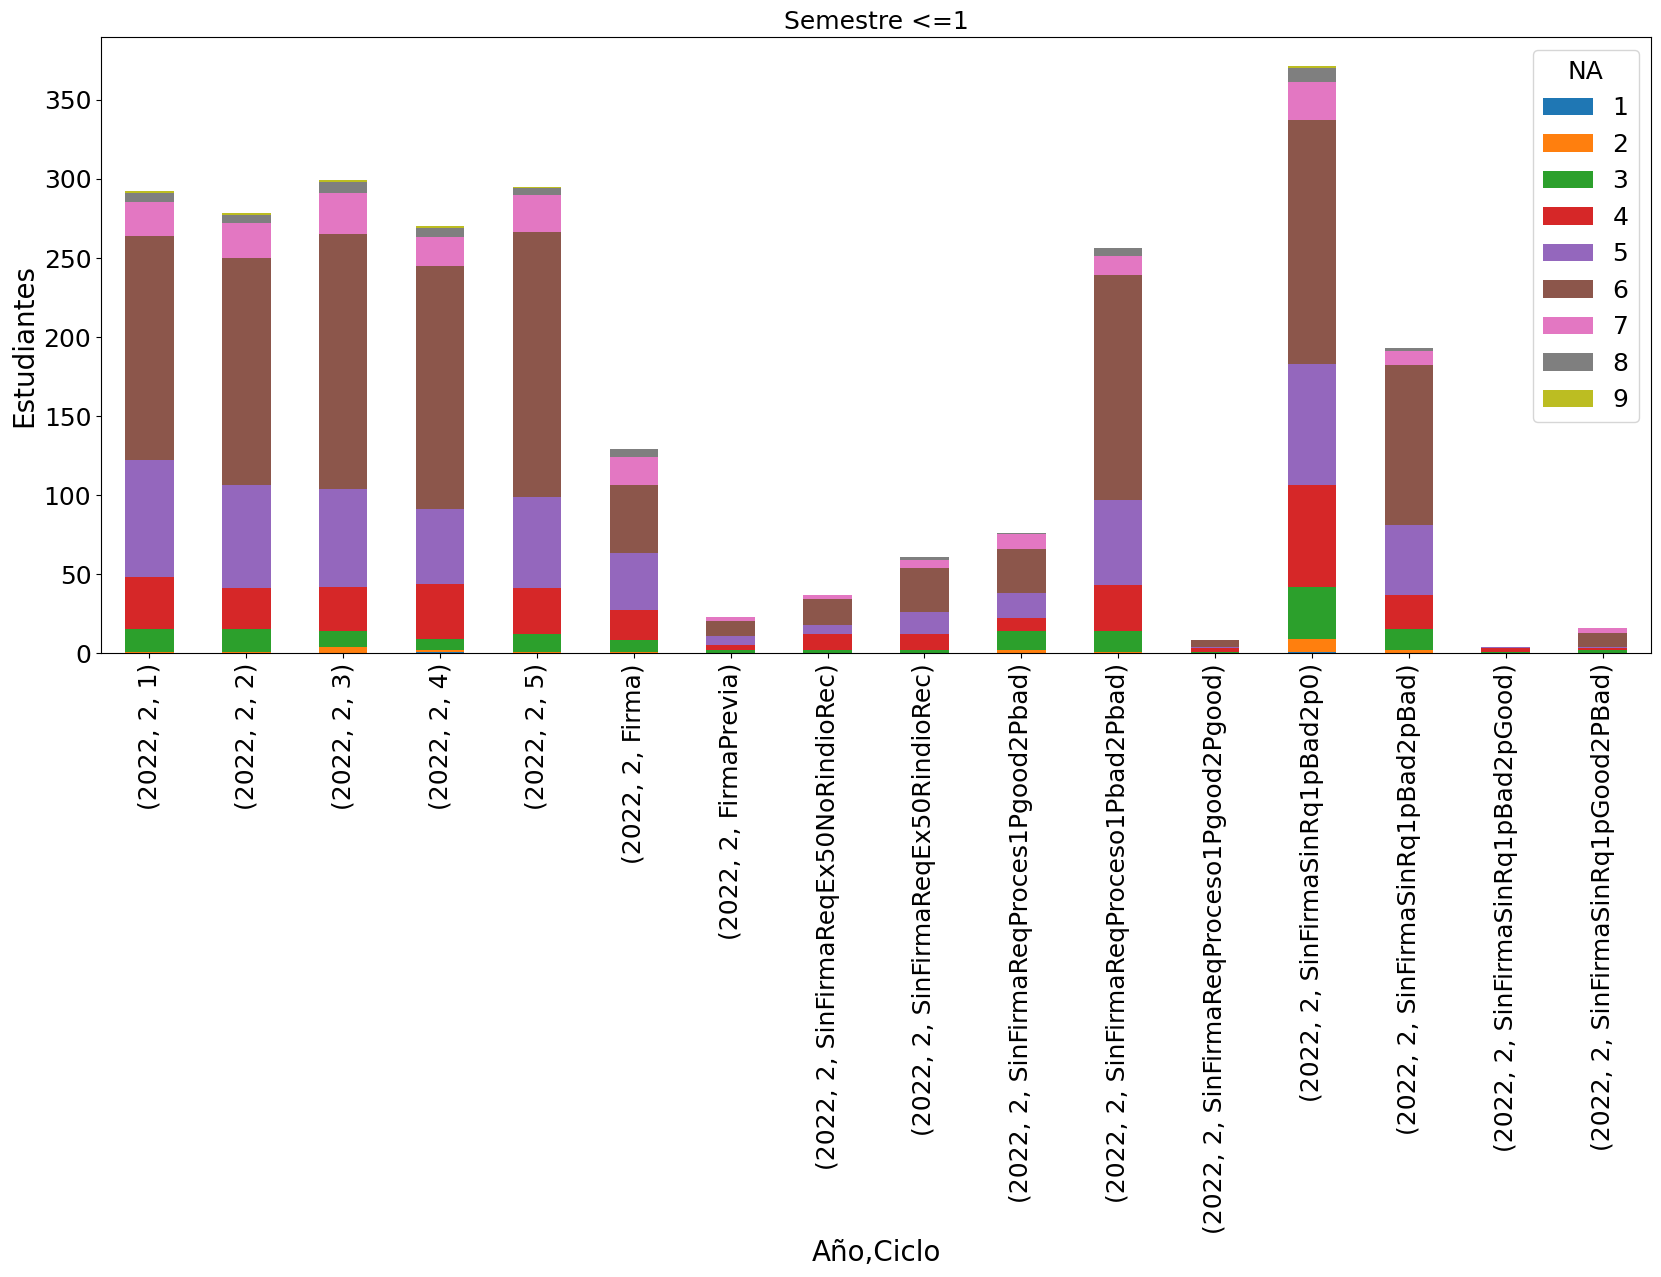

2608
   Anho  ciclo  Idalumno  NA           GrupoNoFinal
0  2022      2        31   3  SinFirmaSinRq1pBad2p0
1  2022      2       127   5                      4
2  2022      2       127   5                      3
3  2022      2       127   5  SinFirmaSinRq1pBad2p0
4  2022      2       127   5                      5


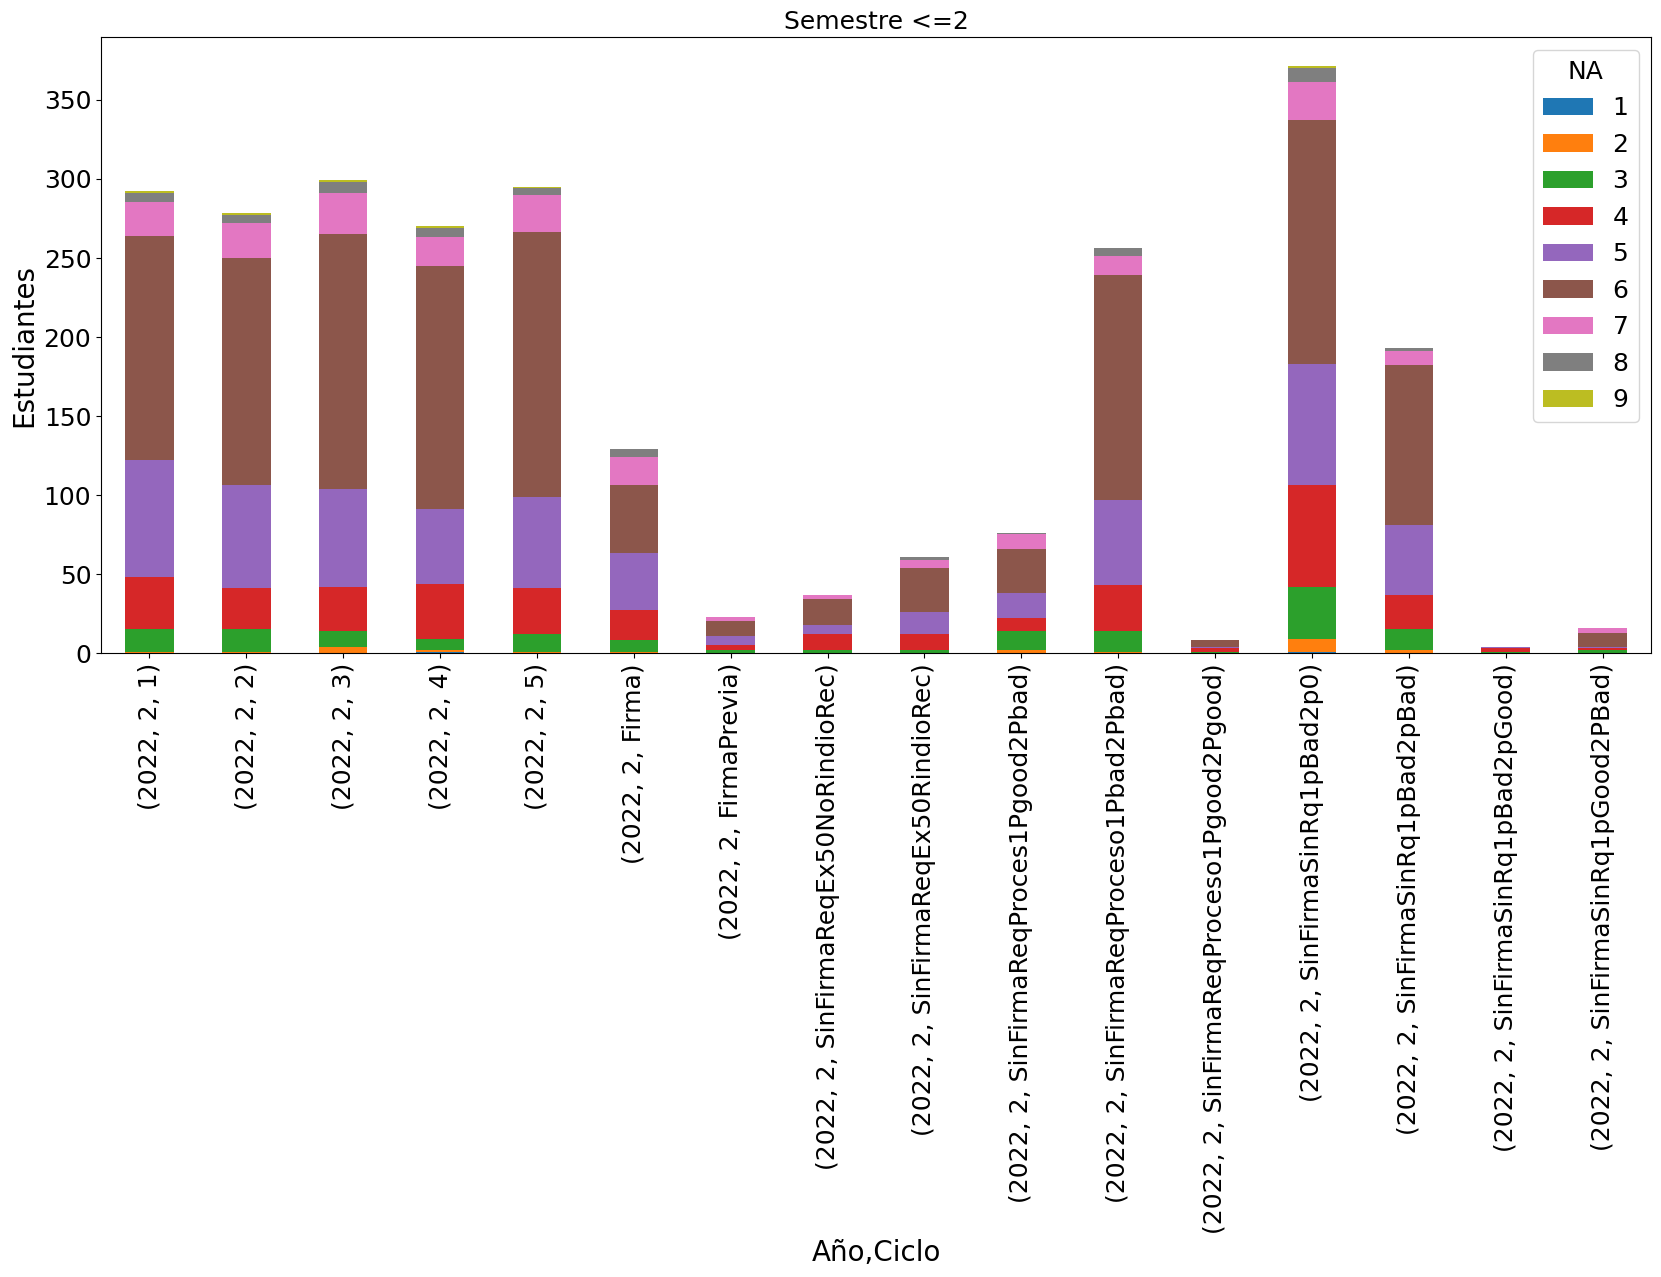

4692
   Anho  ciclo  Idalumno  NA                  GrupoNoFinal
0  2022      2         1   4                             5
1  2022      2         1   4         SinFirmaSinRq1pBad2p0
2  2022      2         1   4       SinFirmaSinRq1pBad2pBad
3  2022      2        12   1                         Firma
4  2022      2        15   4  SinFirmaReqProceso1Pbad2Pbad


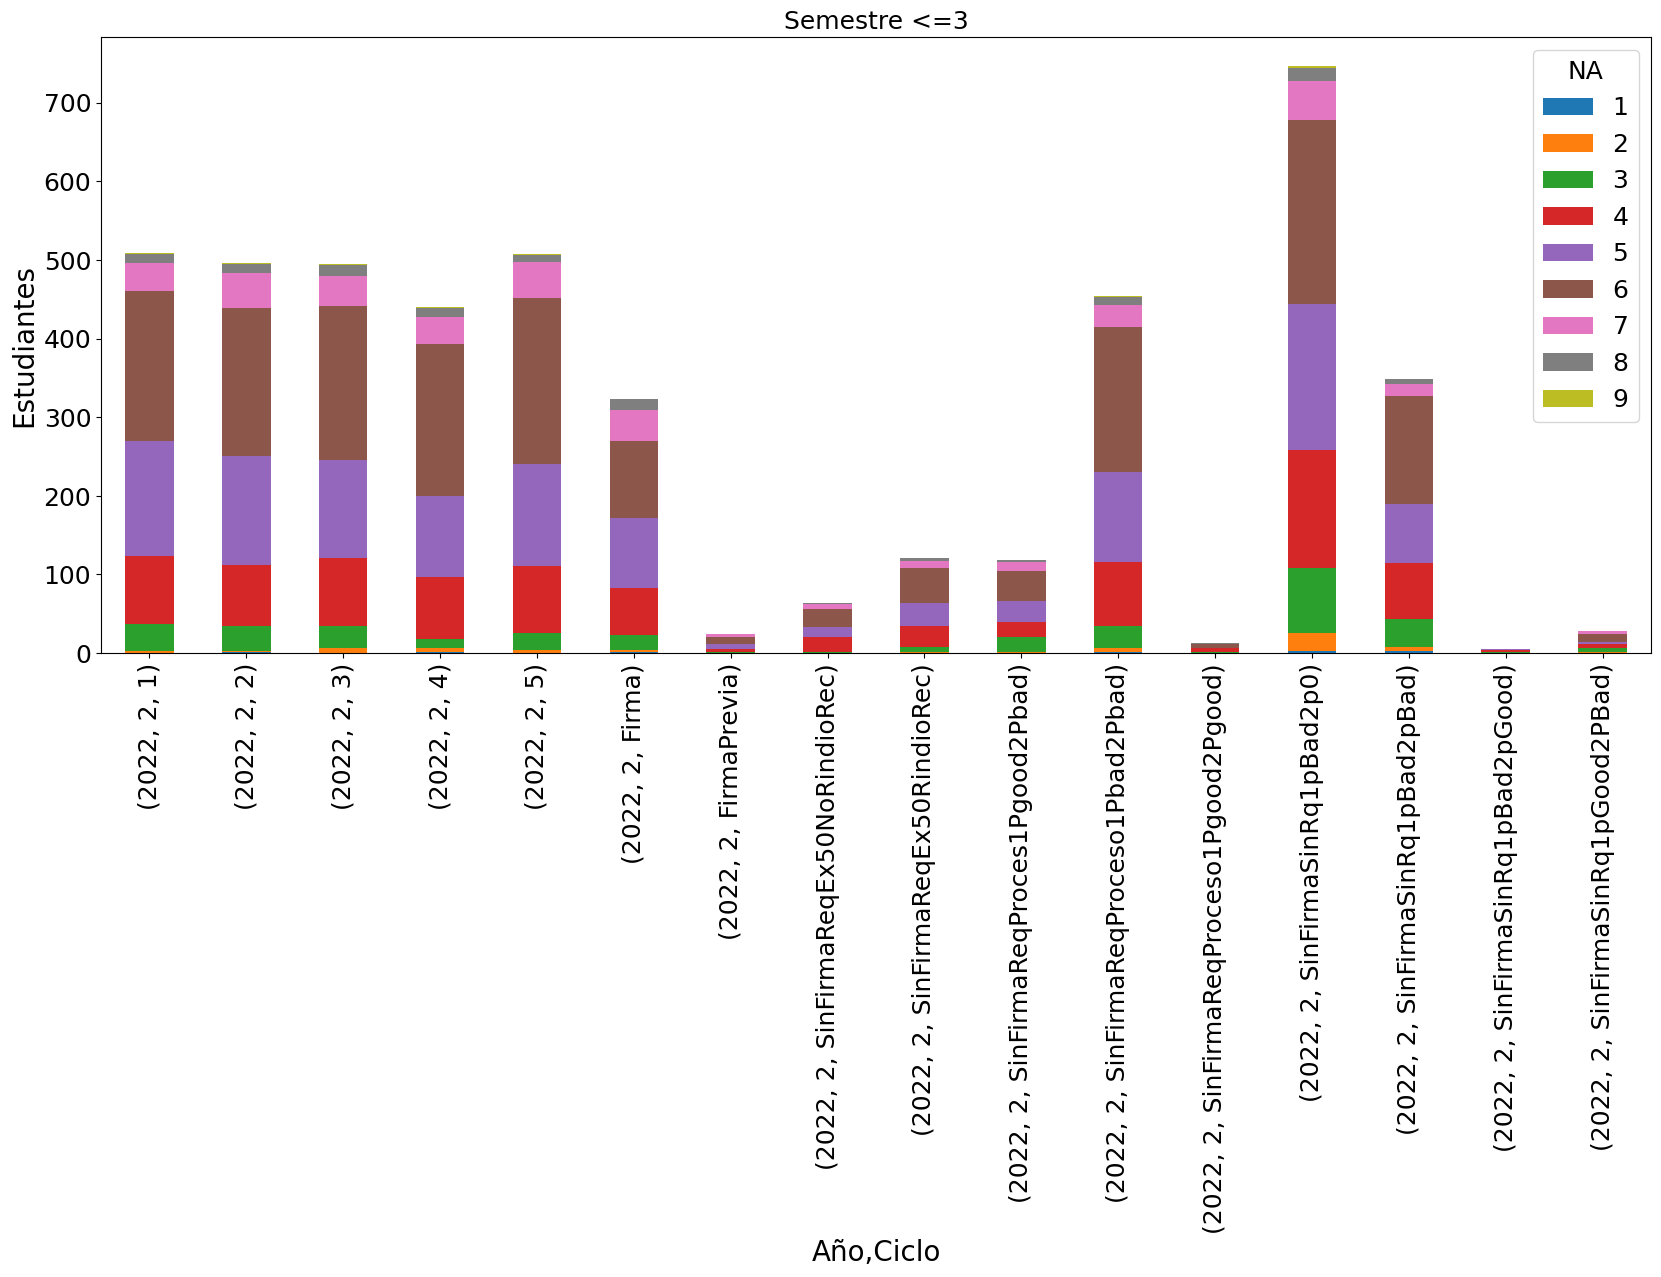

6061
   Anho  ciclo  Idalumno  NA             GrupoNoFinal
0  2022      2         1   4                        5
1  2022      2         1   4    SinFirmaSinRq1pBad2p0
2  2022      2         1   4  SinFirmaSinRq1pBad2pBad
3  2022      2         2   5                        5
4  2022      2         2   5                        4


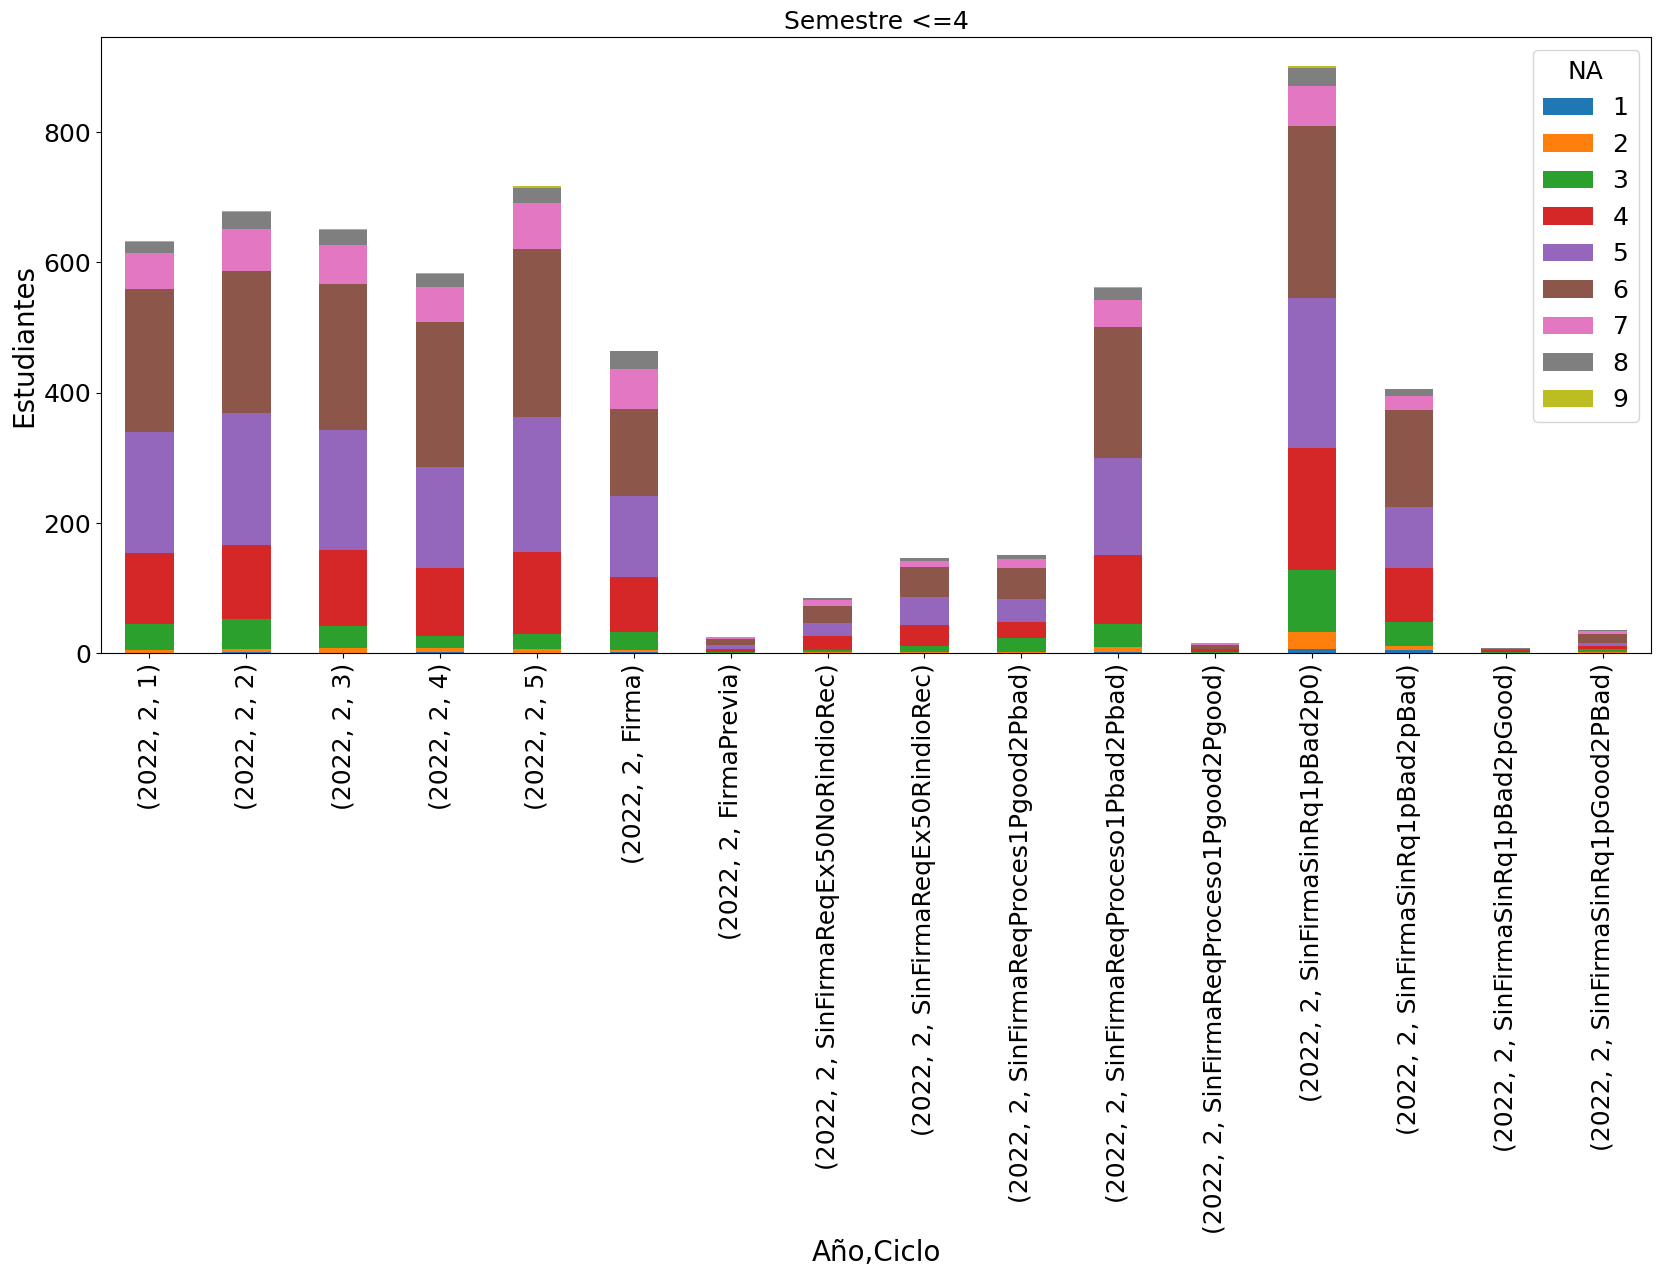

6330
   Anho  ciclo  Idalumno  NA             GrupoNoFinal
0  2022      2         1   4                        5
1  2022      2         1   4    SinFirmaSinRq1pBad2p0
2  2022      2         1   4  SinFirmaSinRq1pBad2pBad
3  2022      2         2   5                        5
4  2022      2         2   5                        4


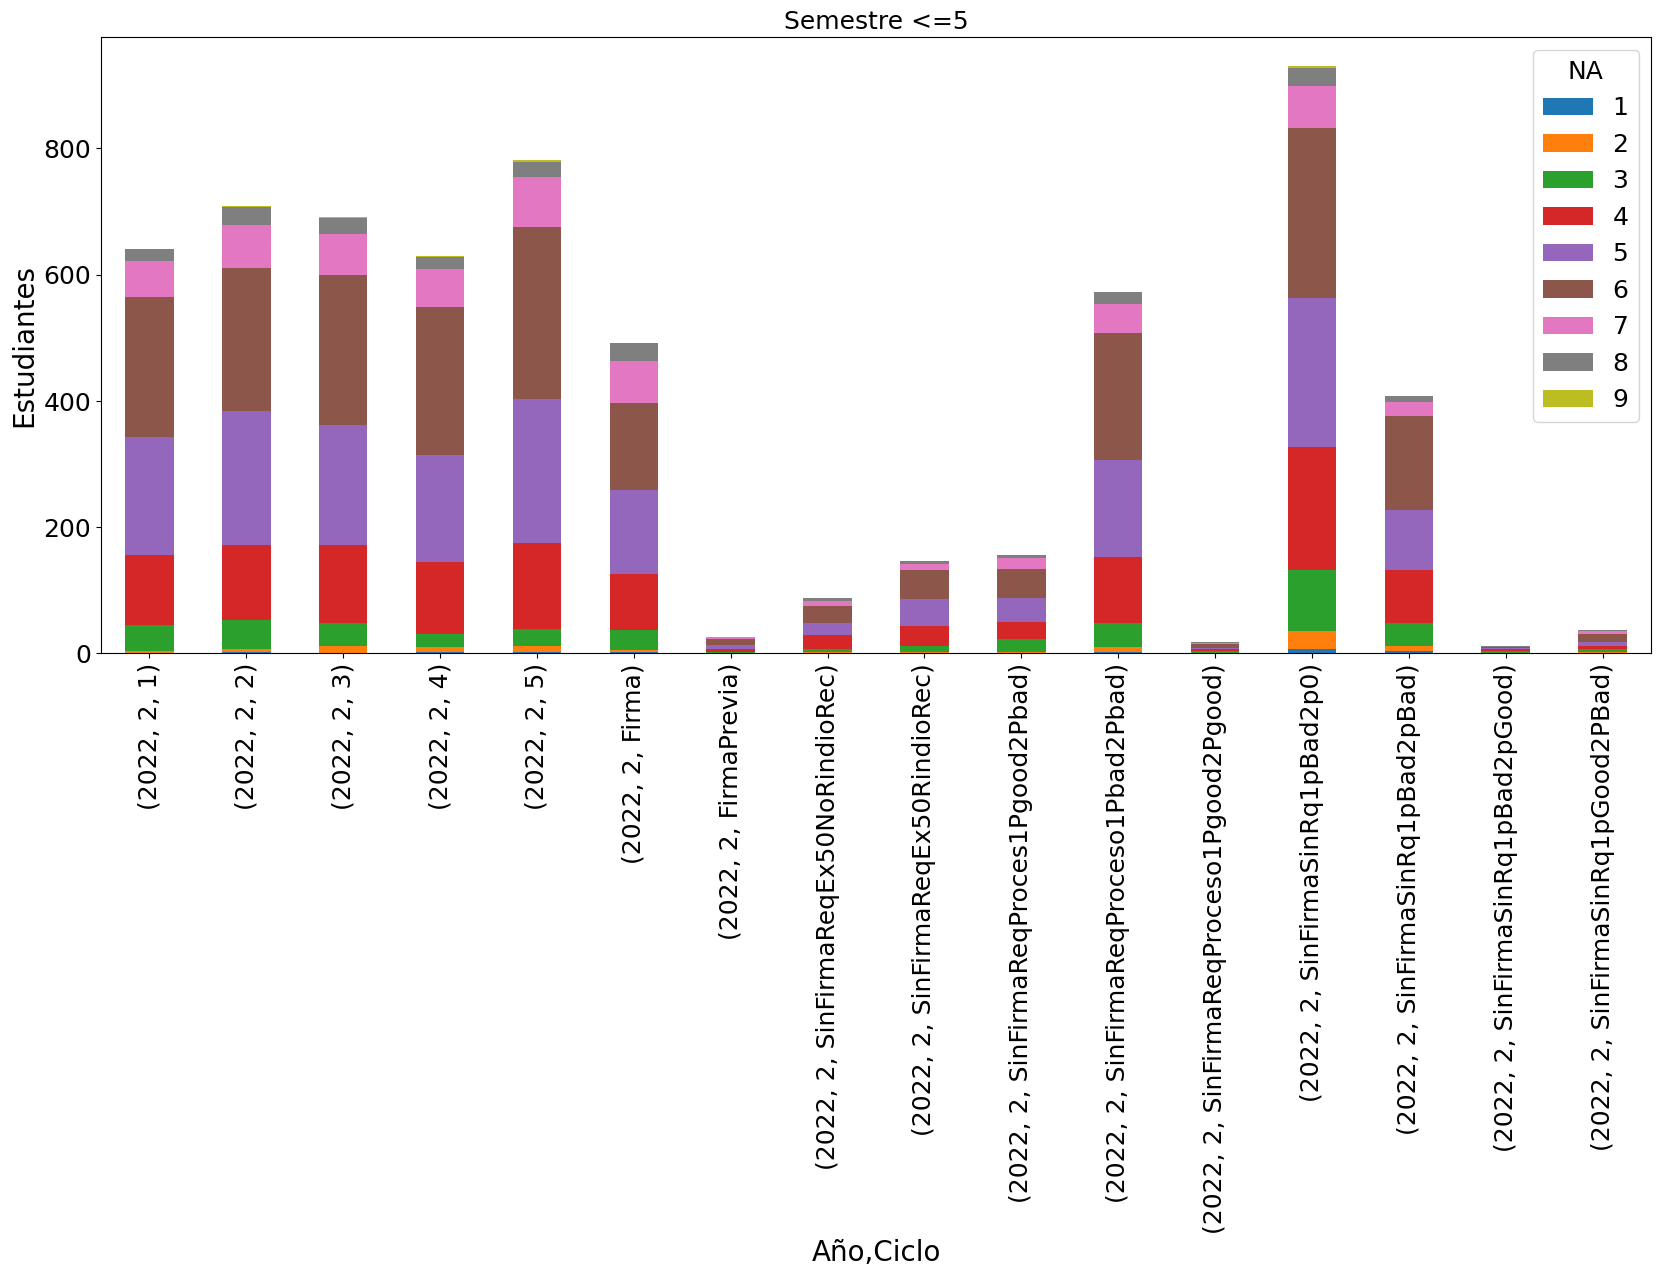

7194
   Anho  ciclo  Idalumno  NA             GrupoNoFinal
0  2022      2         1   4                        5
1  2022      2         1   4    SinFirmaSinRq1pBad2p0
2  2022      2         1   4  SinFirmaSinRq1pBad2pBad
3  2022      2         2   5                        5
4  2022      2         2   5                        4


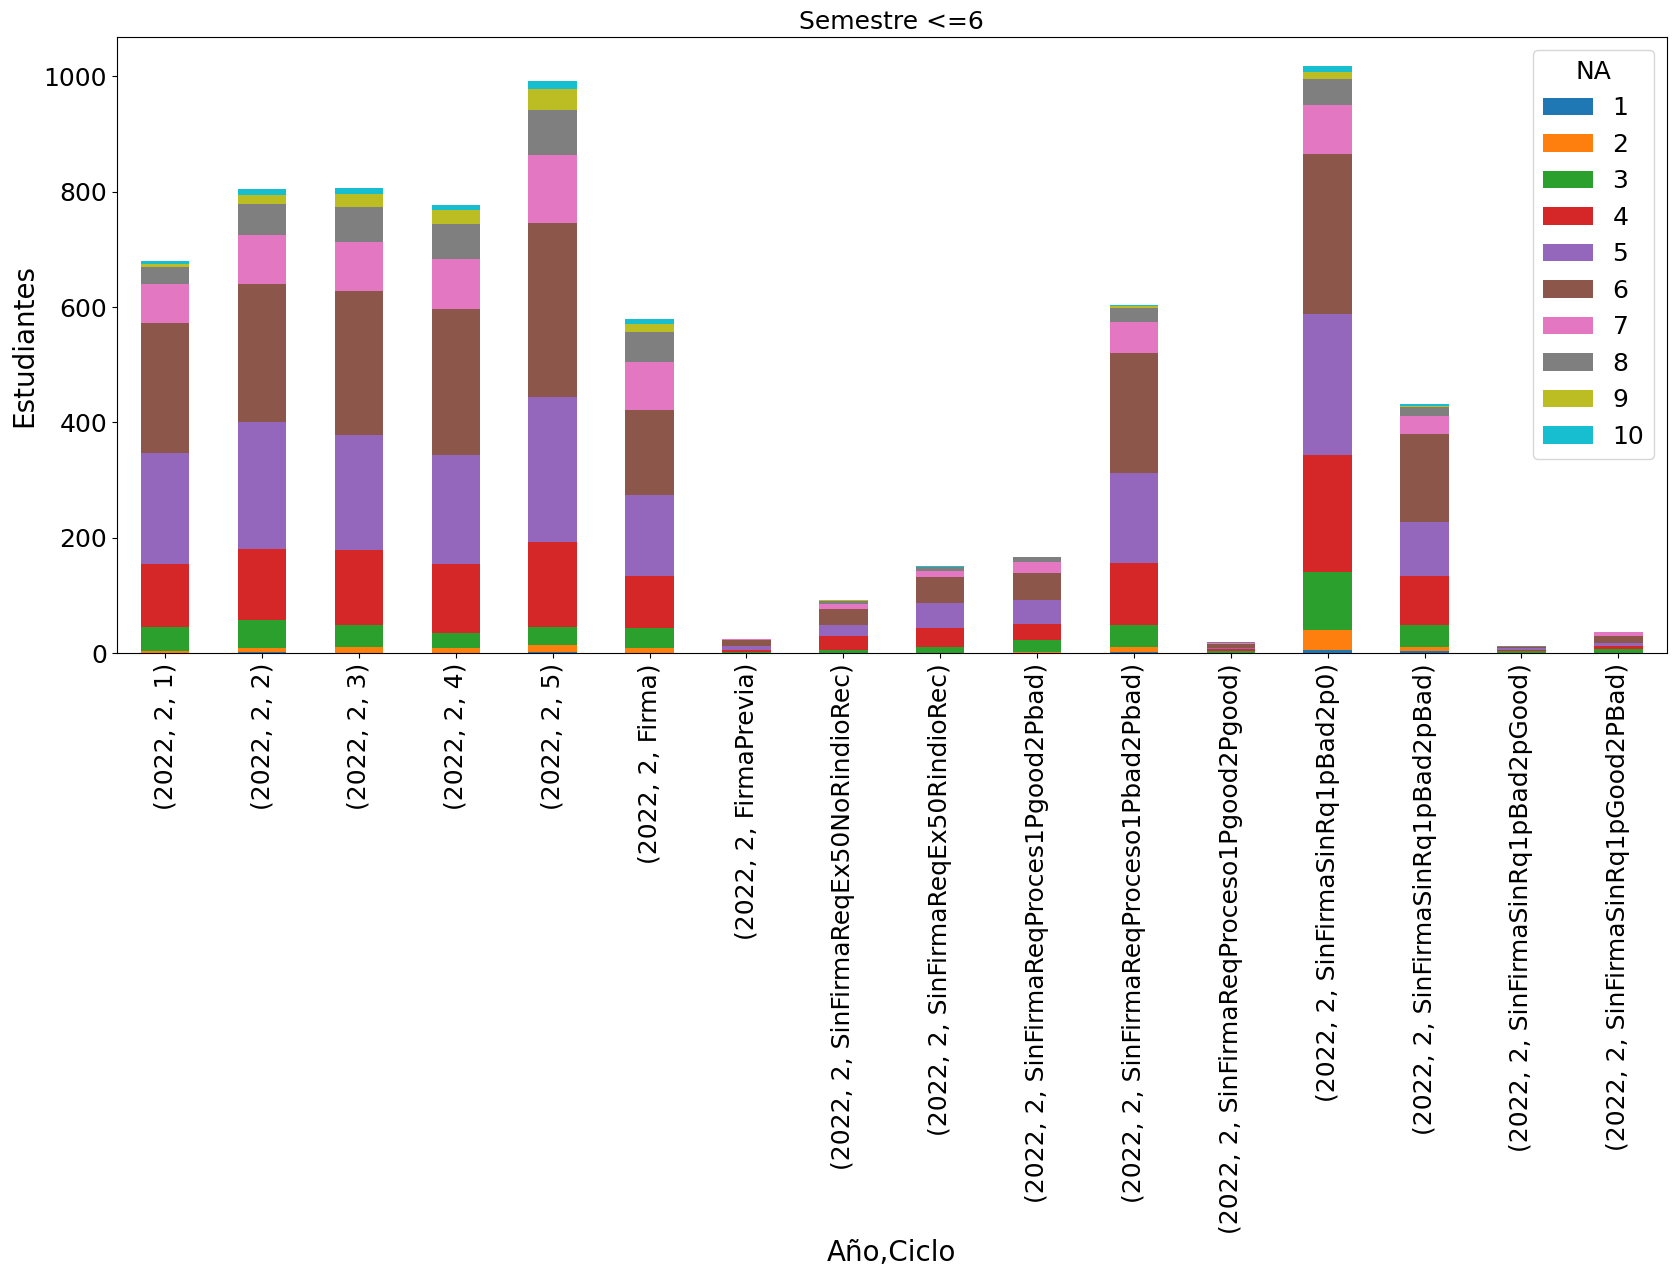

7502
   Anho  ciclo  Idalumno  NA             GrupoNoFinal
0  2022      2         1   4                        5
1  2022      2         1   4    SinFirmaSinRq1pBad2p0
2  2022      2         1   4  SinFirmaSinRq1pBad2pBad
3  2022      2         2   5                        5
4  2022      2         2   5                        4


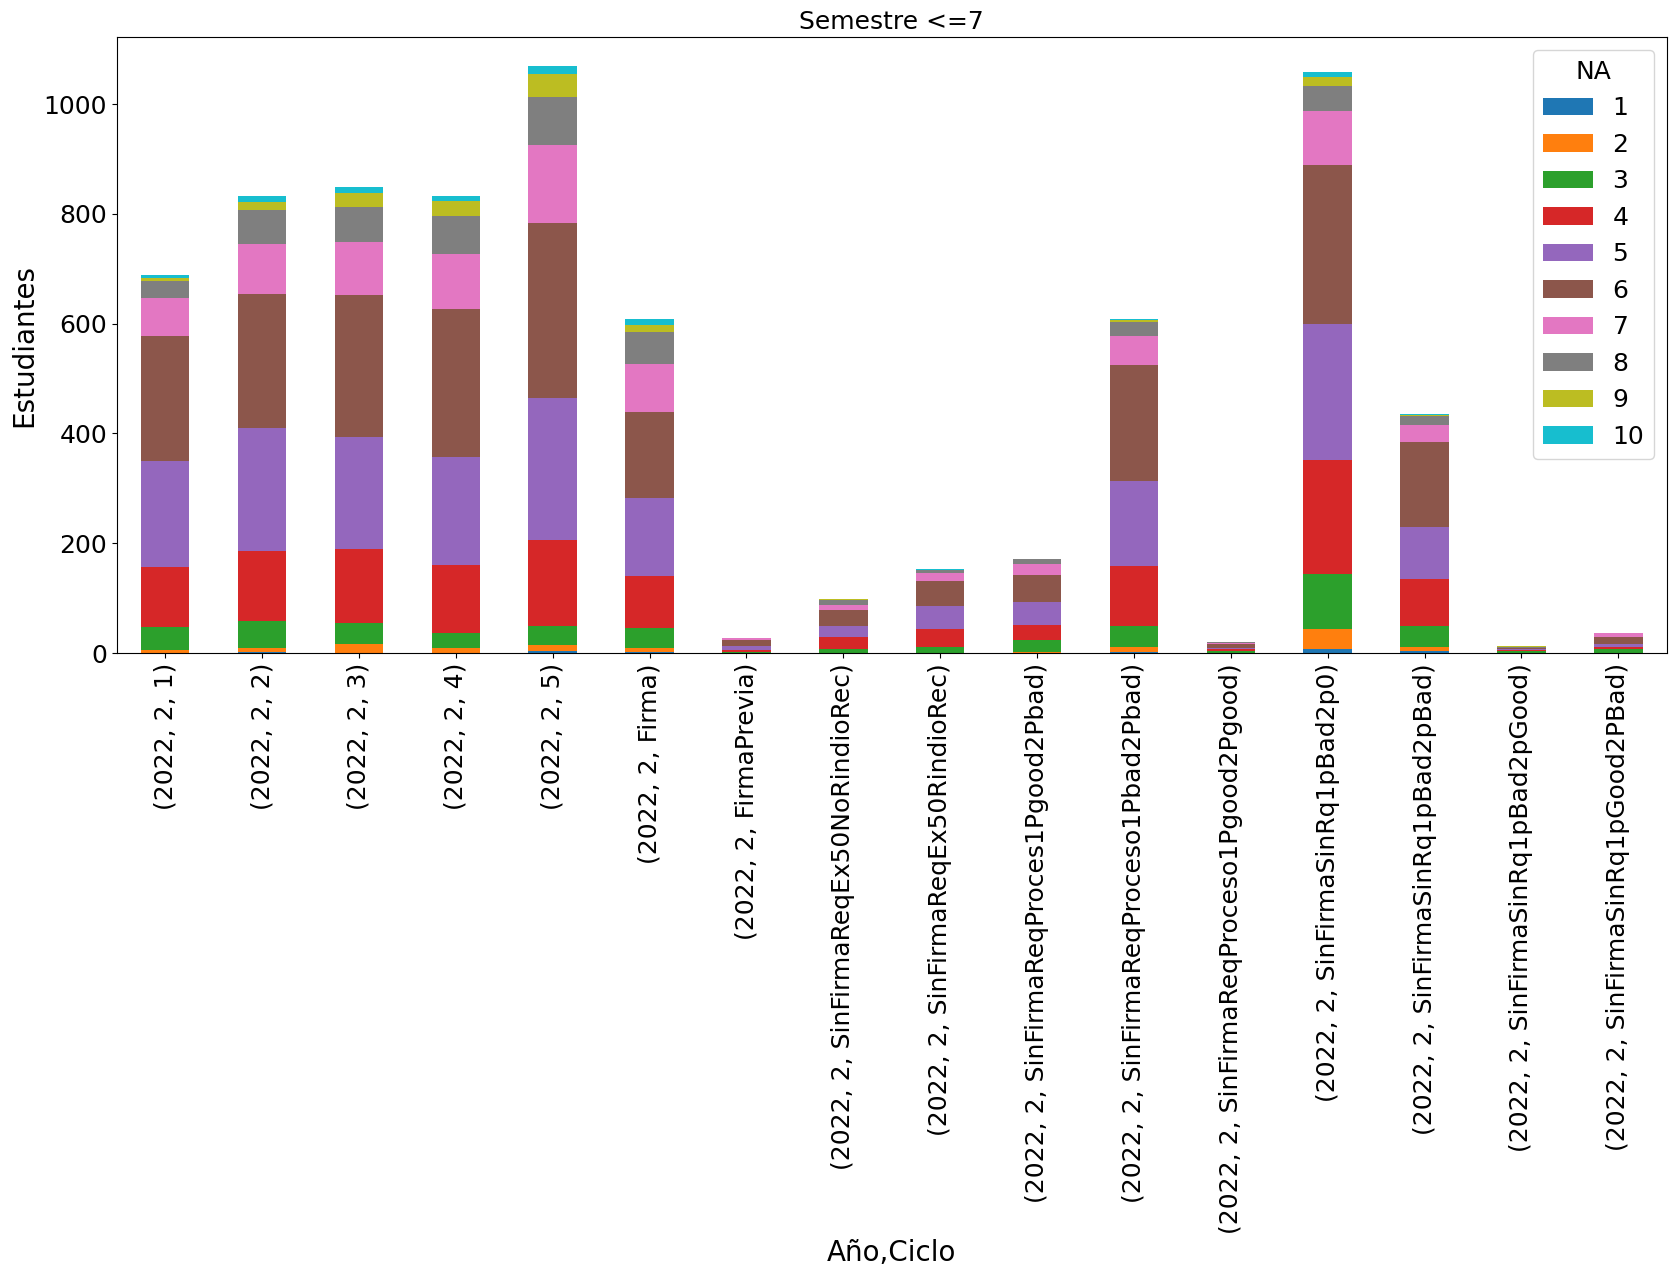

7961
   Anho  ciclo  Idalumno  NA             GrupoNoFinal
0  2022      2         1   4                        5
1  2022      2         1   4    SinFirmaSinRq1pBad2p0
2  2022      2         1   4  SinFirmaSinRq1pBad2pBad
3  2022      2         2   5                        5
4  2022      2         2   5                        4


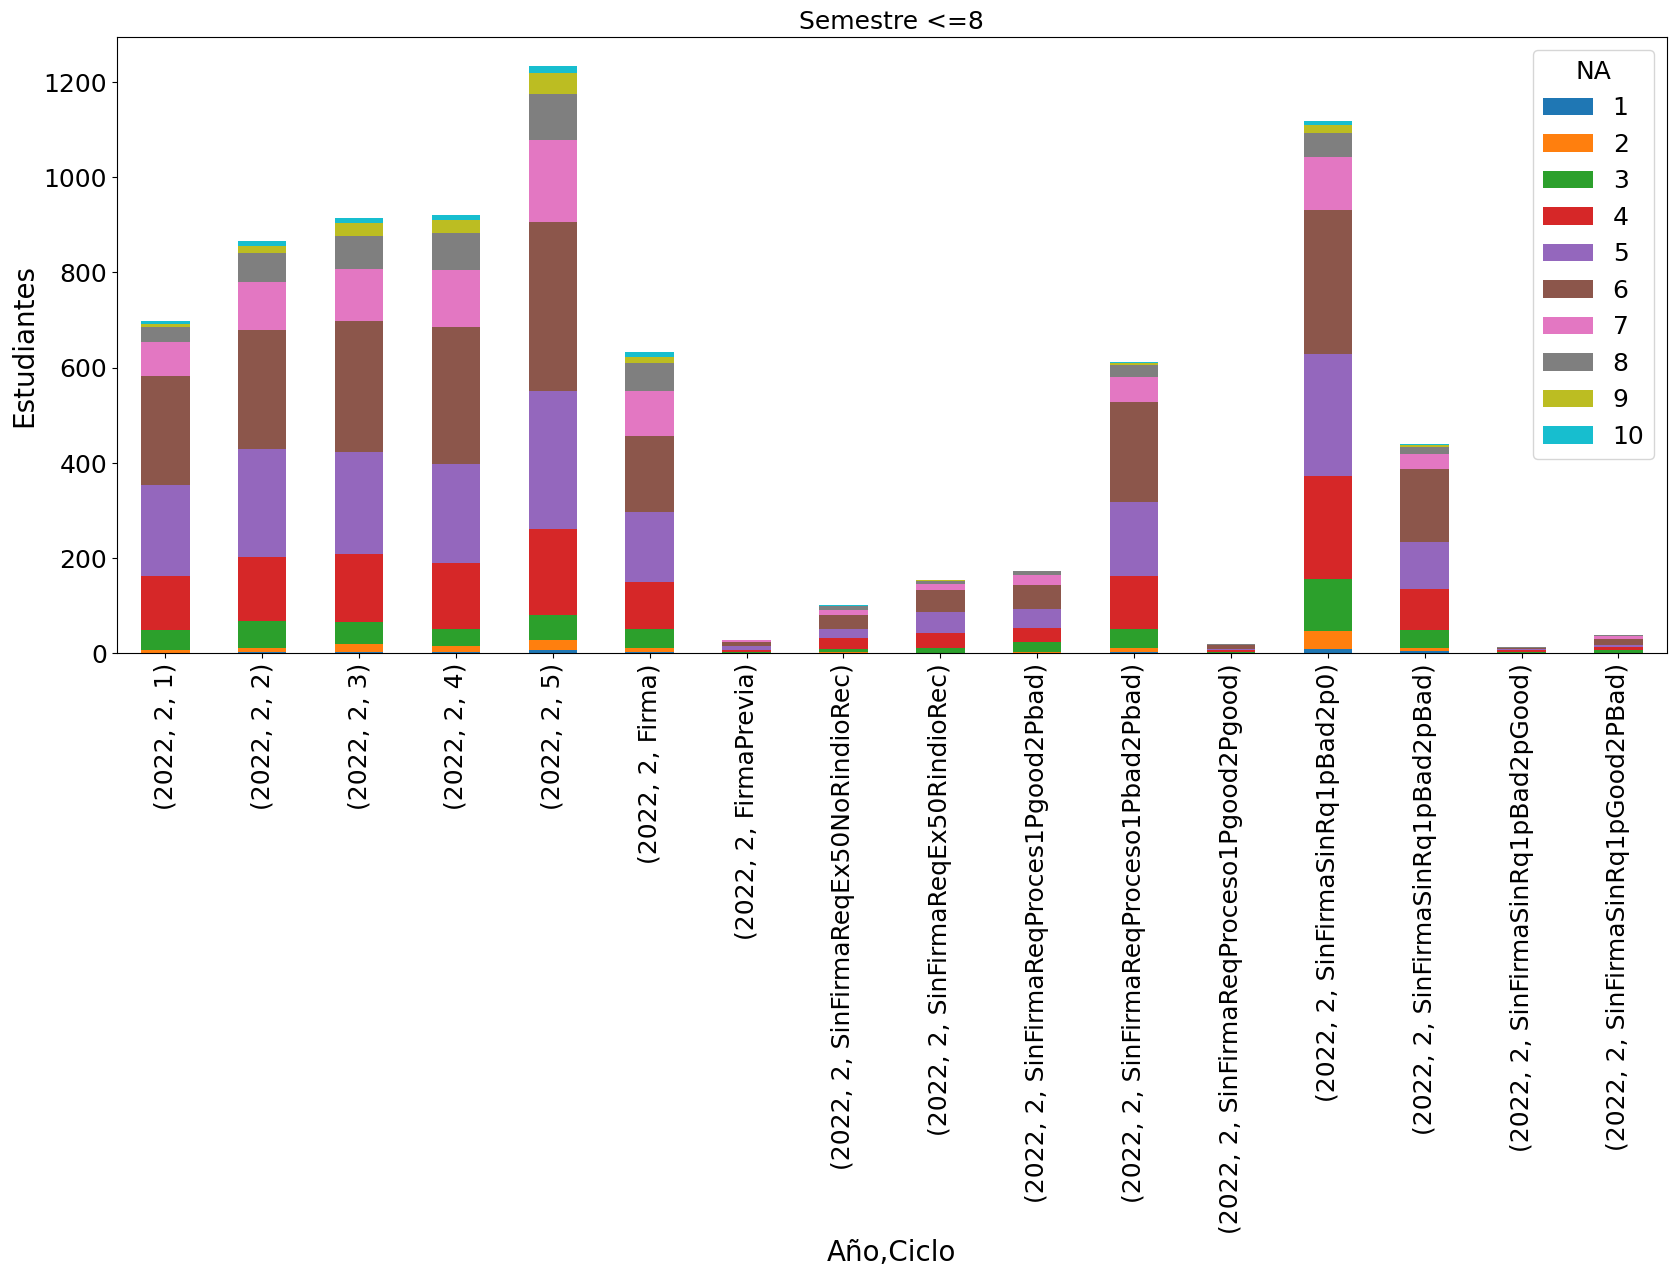

7972
   Anho  ciclo  Idalumno  NA             GrupoNoFinal
0  2022      2         1   4                        5
1  2022      2         1   4    SinFirmaSinRq1pBad2p0
2  2022      2         1   4  SinFirmaSinRq1pBad2pBad
3  2022      2         2   5                        5
4  2022      2         2   5                        4


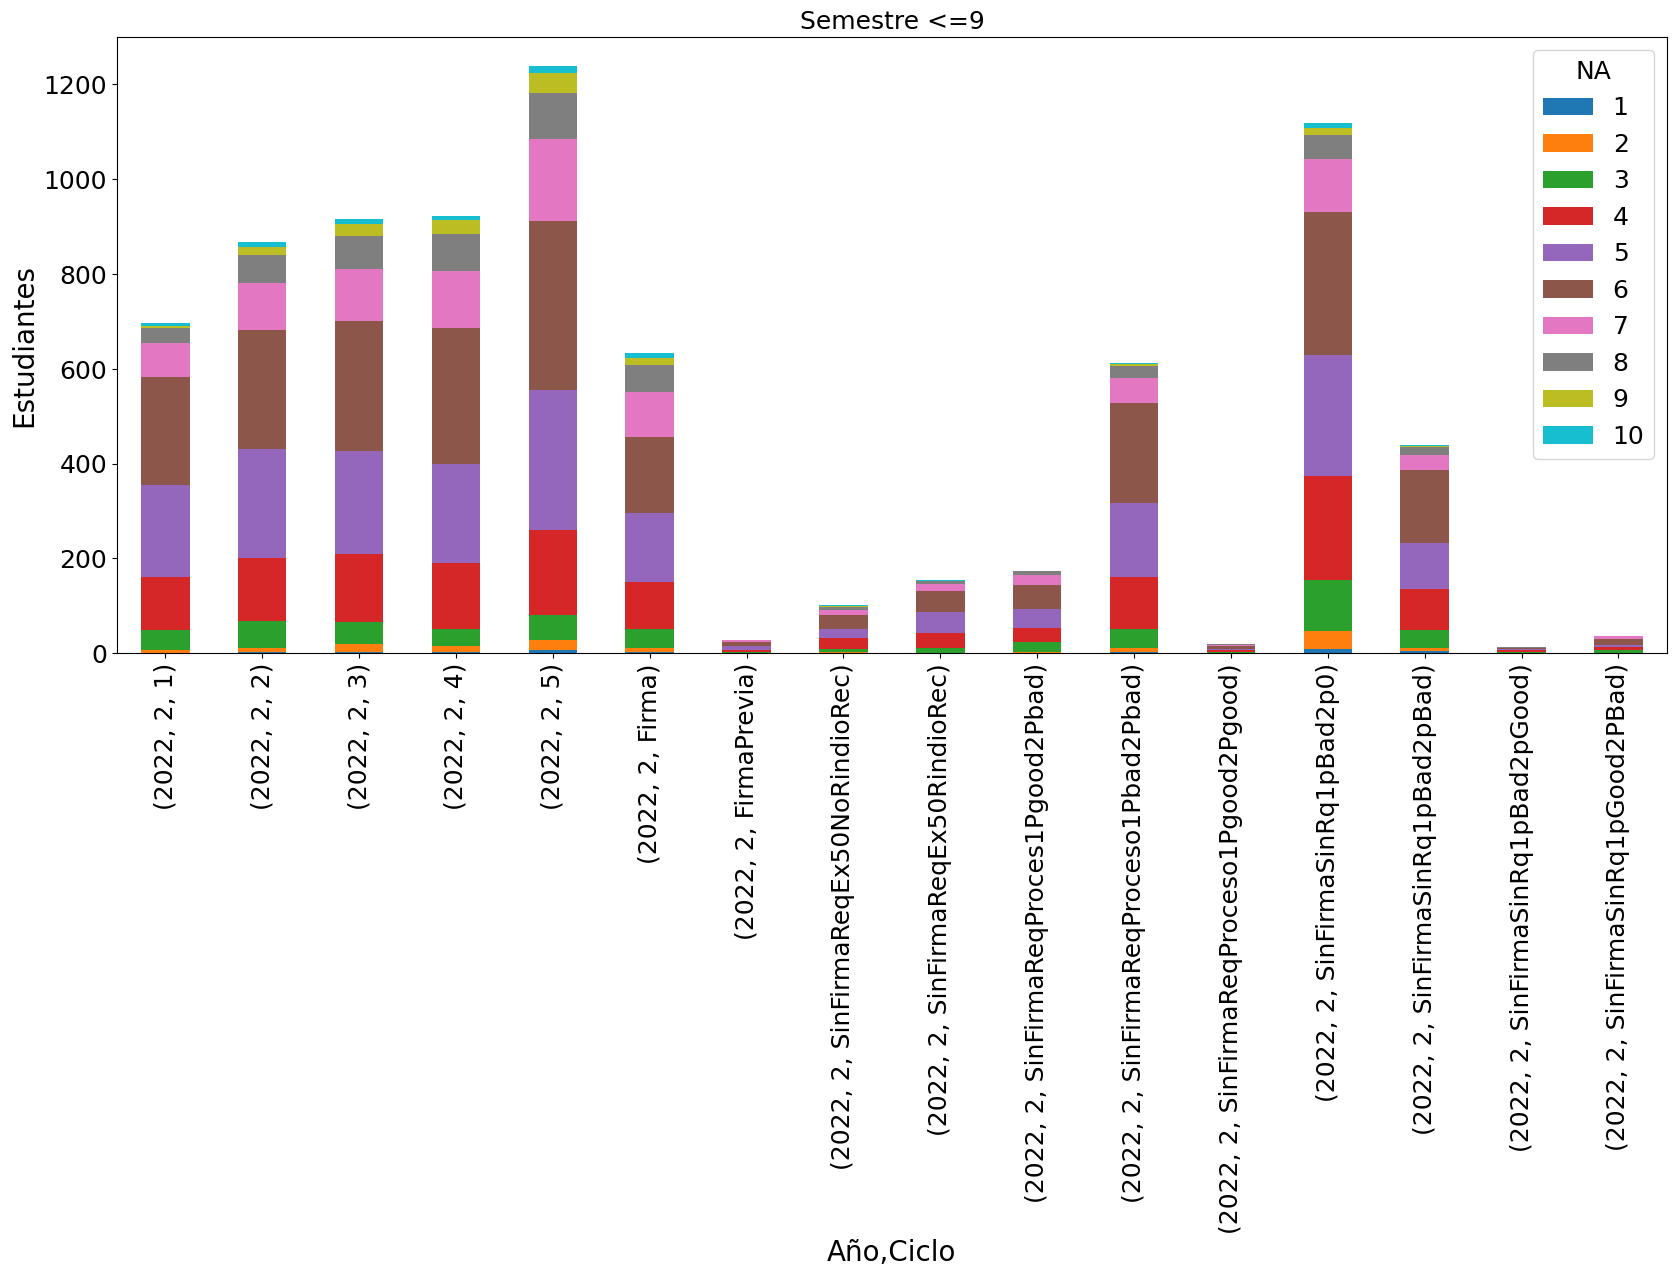

In [45]:
df=data
for s in [1,2,3,4,5,6,7,8,9]:
    if(True):
        lista=df[df.SemestreAlumno<=s]   
        lista=lista[['Anho','ciclo','Idalumno','GrupoNoFinal']]
        print(len(lista.drop_duplicates()))
        dfg=df.groupby(['Anho','ciclo','Idalumno']).apply(lambda x:len(x['Asignatura'].values) )
        dfgg=dfg.reset_index(name = 'NA')
        combined=pd.merge(dfgg,lista.drop_duplicates(), on=['Anho','ciclo','Idalumno'], how='right')
        print(combined.head())
        dfggg=combined.groupby(['Anho','ciclo','GrupoNoFinal','NA'])['Idalumno'].nunique()
    
        f, ax = plt.subplots(figsize=(20, 8))
        ax.set_title("Semestre <="+str(s) )

        dfggg.unstack().plot(kind='bar',stacked=True,ax=ax)
        plt.xlabel("Año,Ciclo")
        plt.ylabel("Estudiantes")
        plt.savefig("graficos\Histogramasmenor"+str(s)+".png", bbox_inches="tight")
        plt.show()

371
   Anho  ciclo  Idalumno  NA
0  2022      2        31   3
1  2022      2       127   5
2  2022      2       134   4
3  2022      2       136   8
4  2022      2       167   5


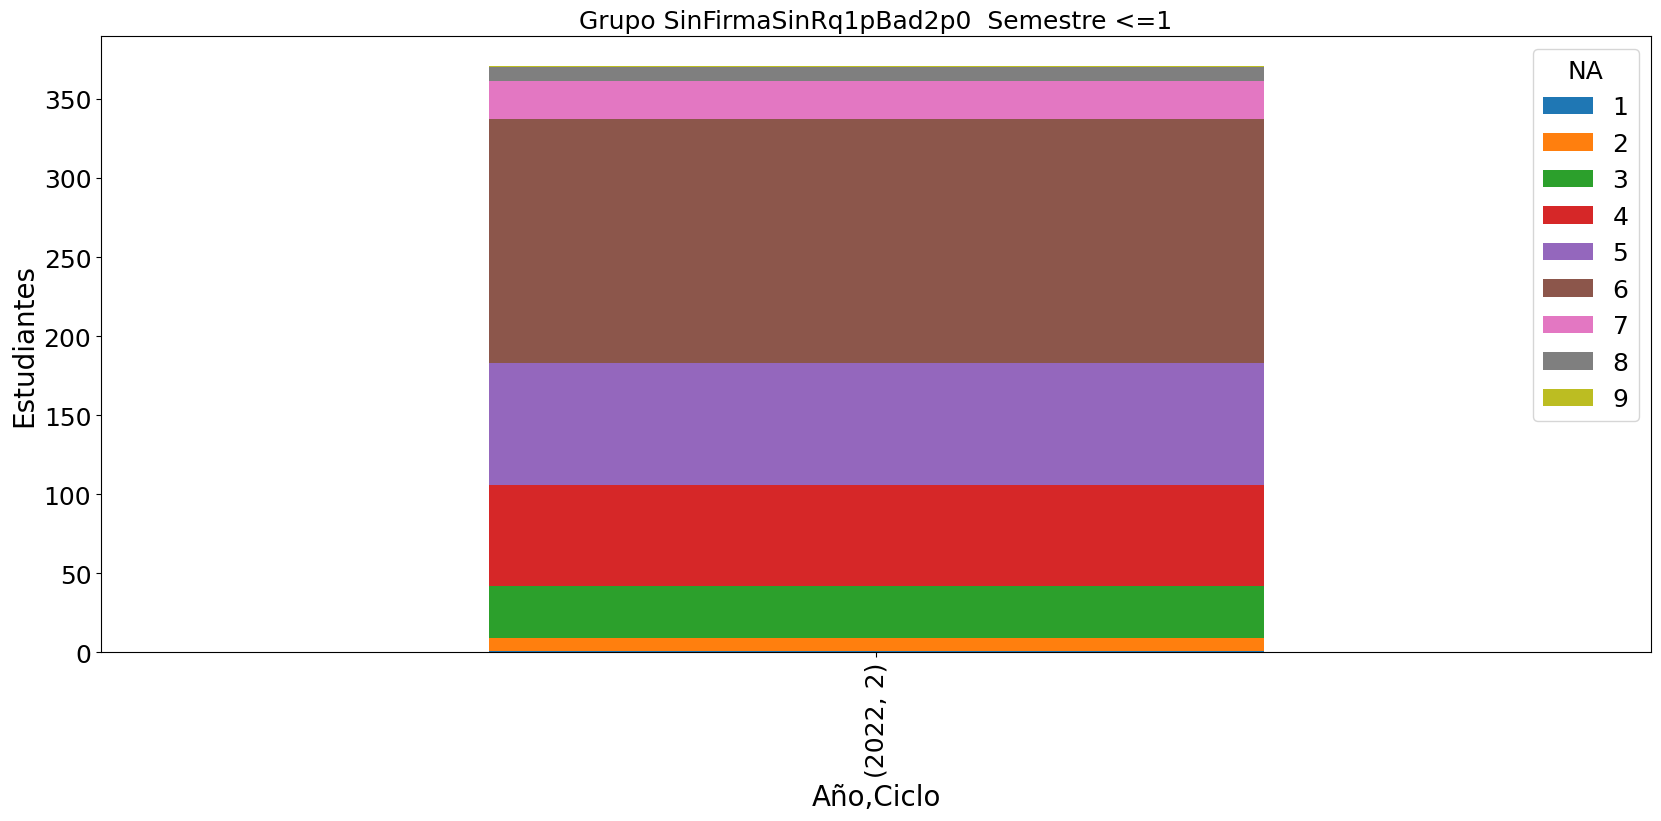

256
   Anho  ciclo  Idalumno  NA
0  2022      2       136   8
1  2022      2       214   7
2  2022      2       271   5
3  2022      2       307   5
4  2022      2       322   5


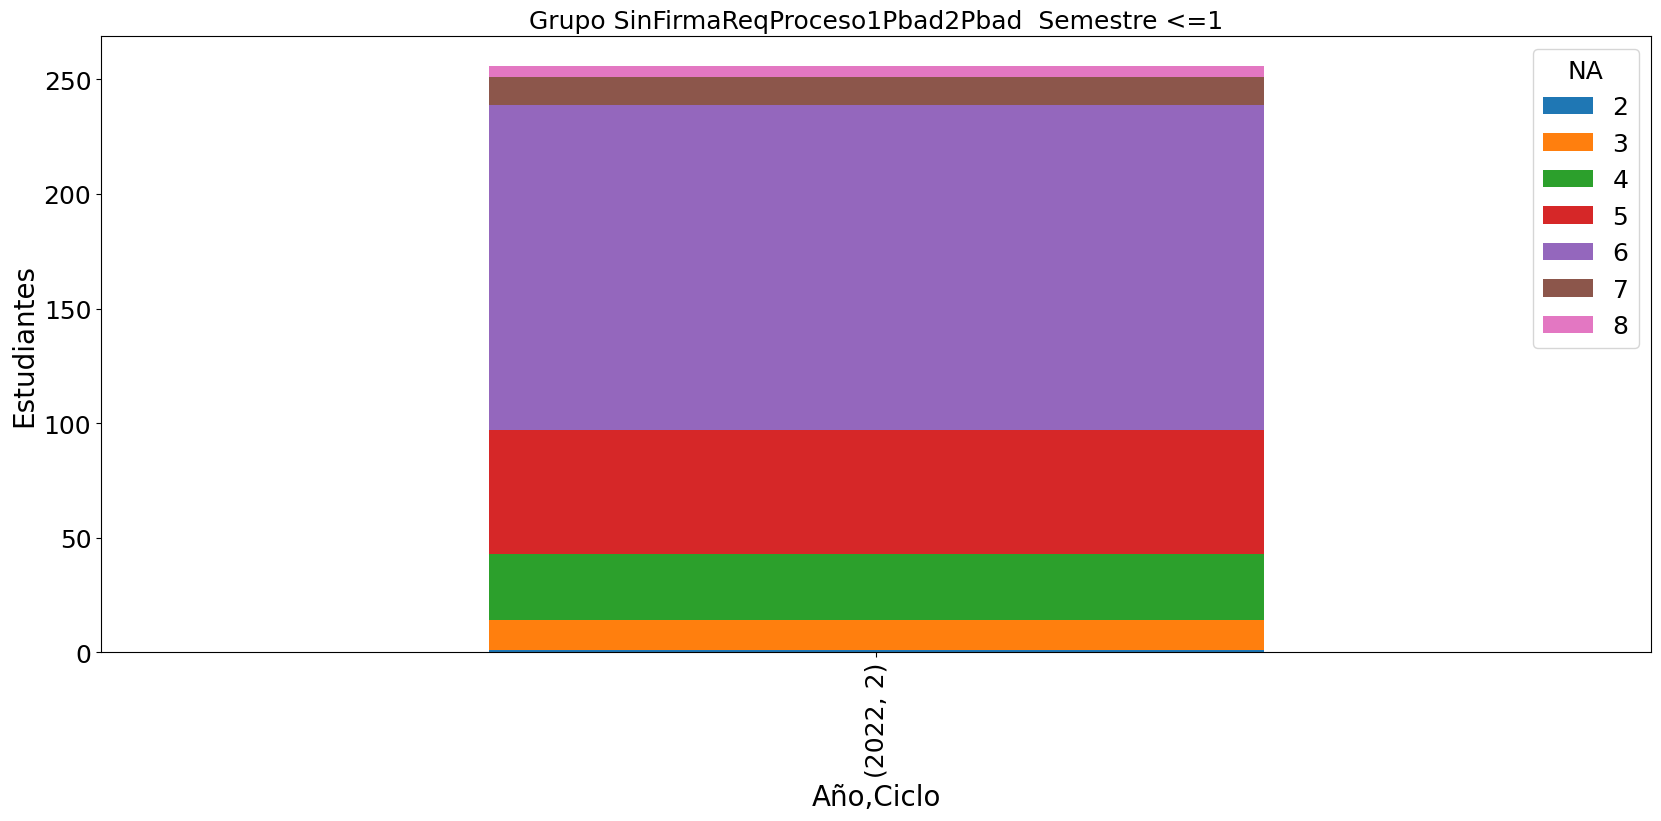

292
   Anho  ciclo  Idalumno  NA
0  2022      2       214   7
1  2022      2       241   5
2  2022      2       271   5
3  2022      2       332   5
4  2022      2       390   4


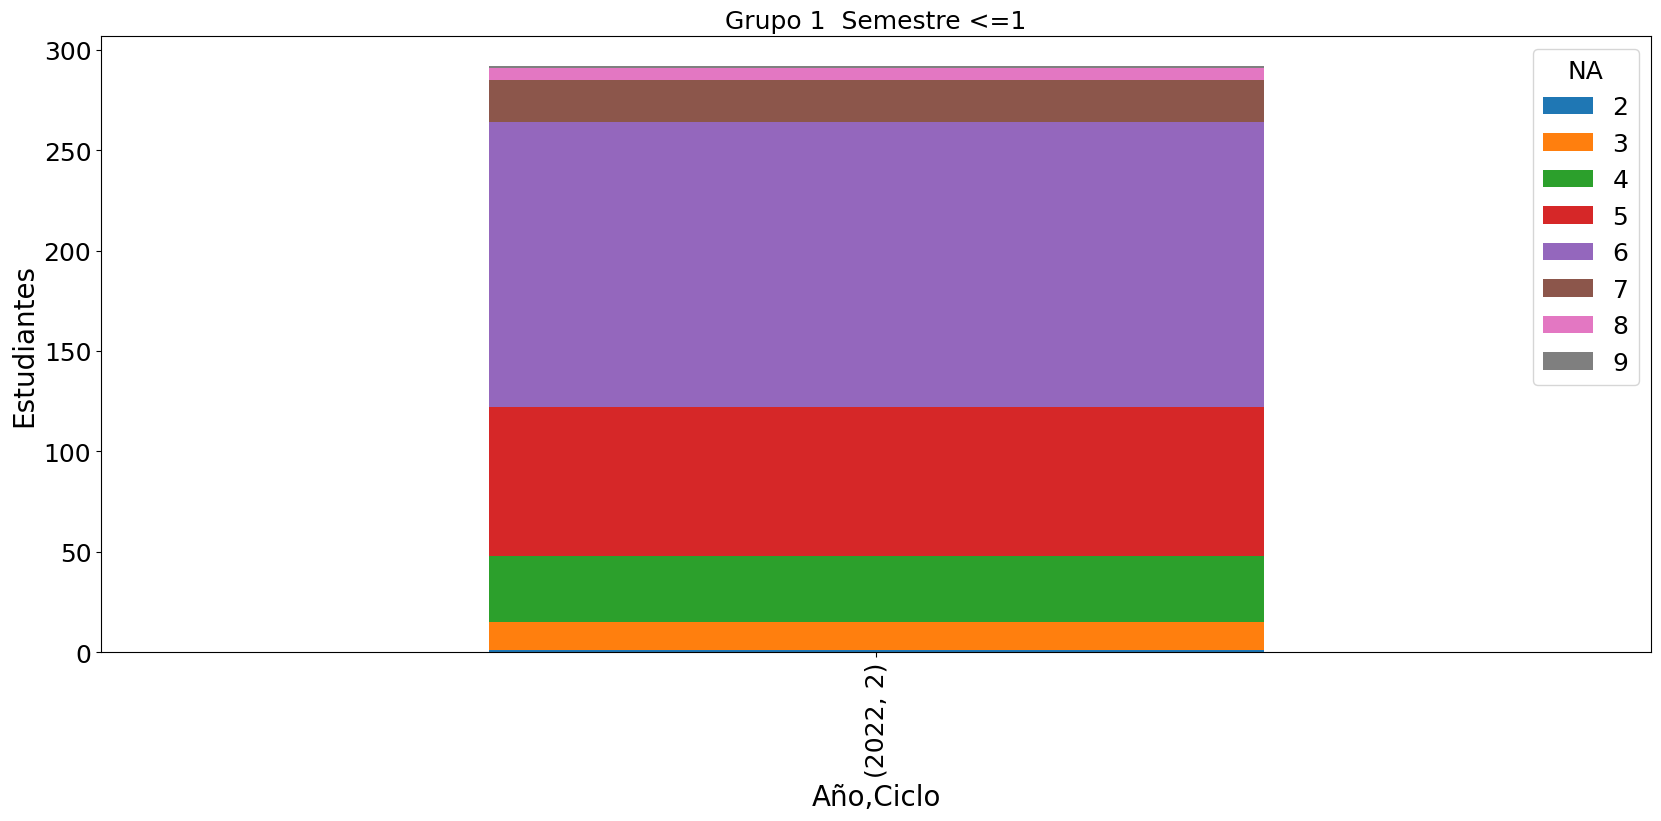

278
   Anho  ciclo  Idalumno  NA
0  2022      2       136   8
1  2022      2       241   5
2  2022      2       297   6
3  2022      2       332   5
4  2022      2       625   6


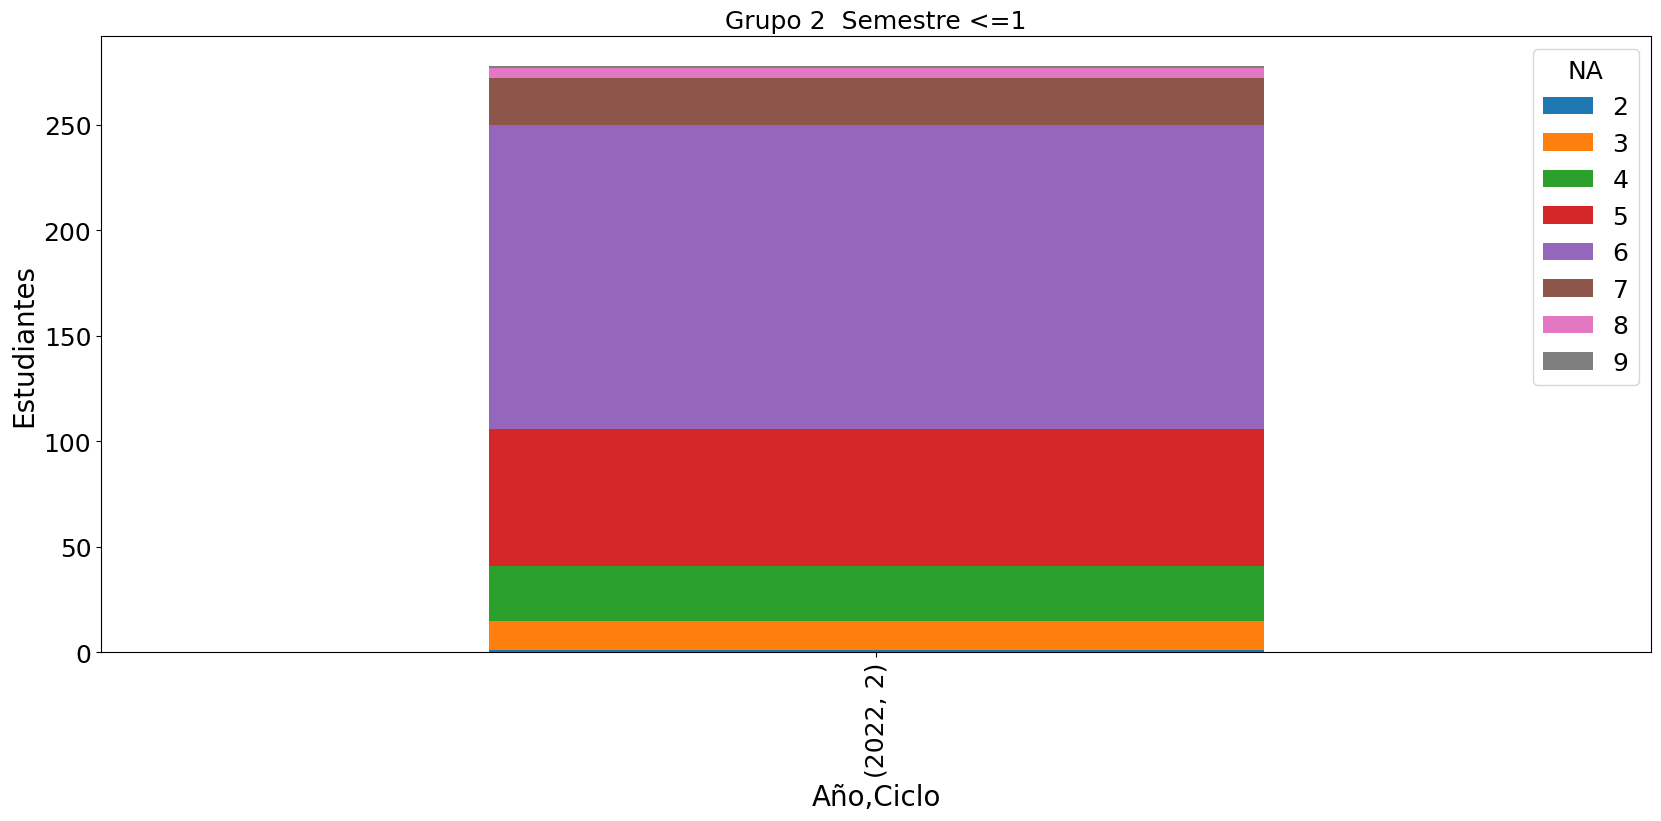

299
   Anho  ciclo  Idalumno  NA
0  2022      2       127   5
1  2022      2       136   8
2  2022      2       378   6
3  2022      2       625   6
4  2022      2       741   3


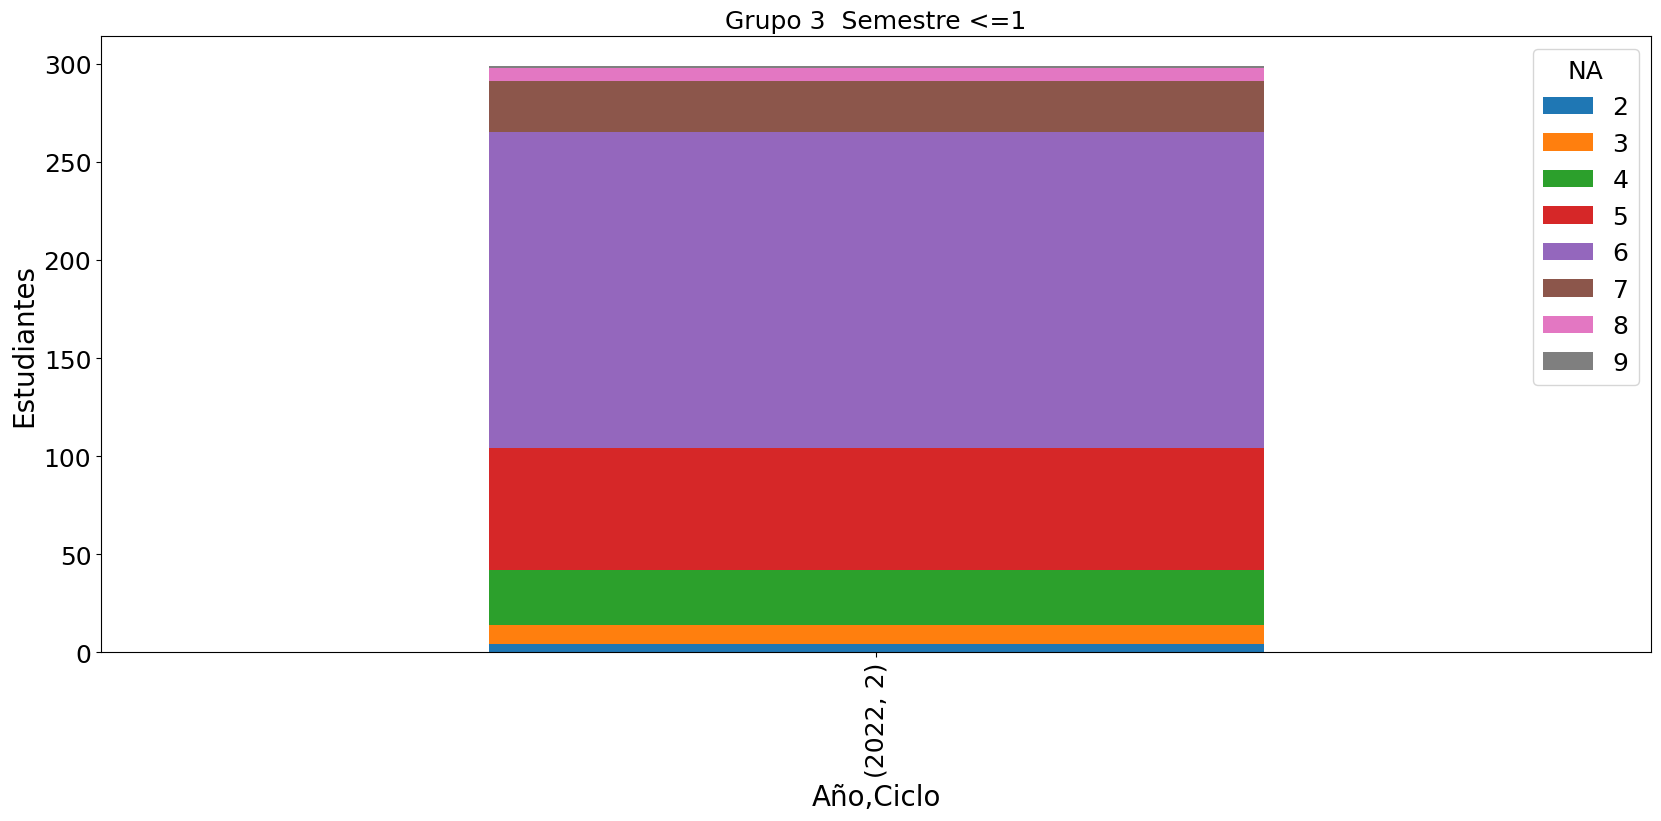

270
   Anho  ciclo  Idalumno  NA
0  2022      2       127   5
1  2022      2       134   4
2  2022      2       136   8
3  2022      2       241   5
4  2022      2       297   6


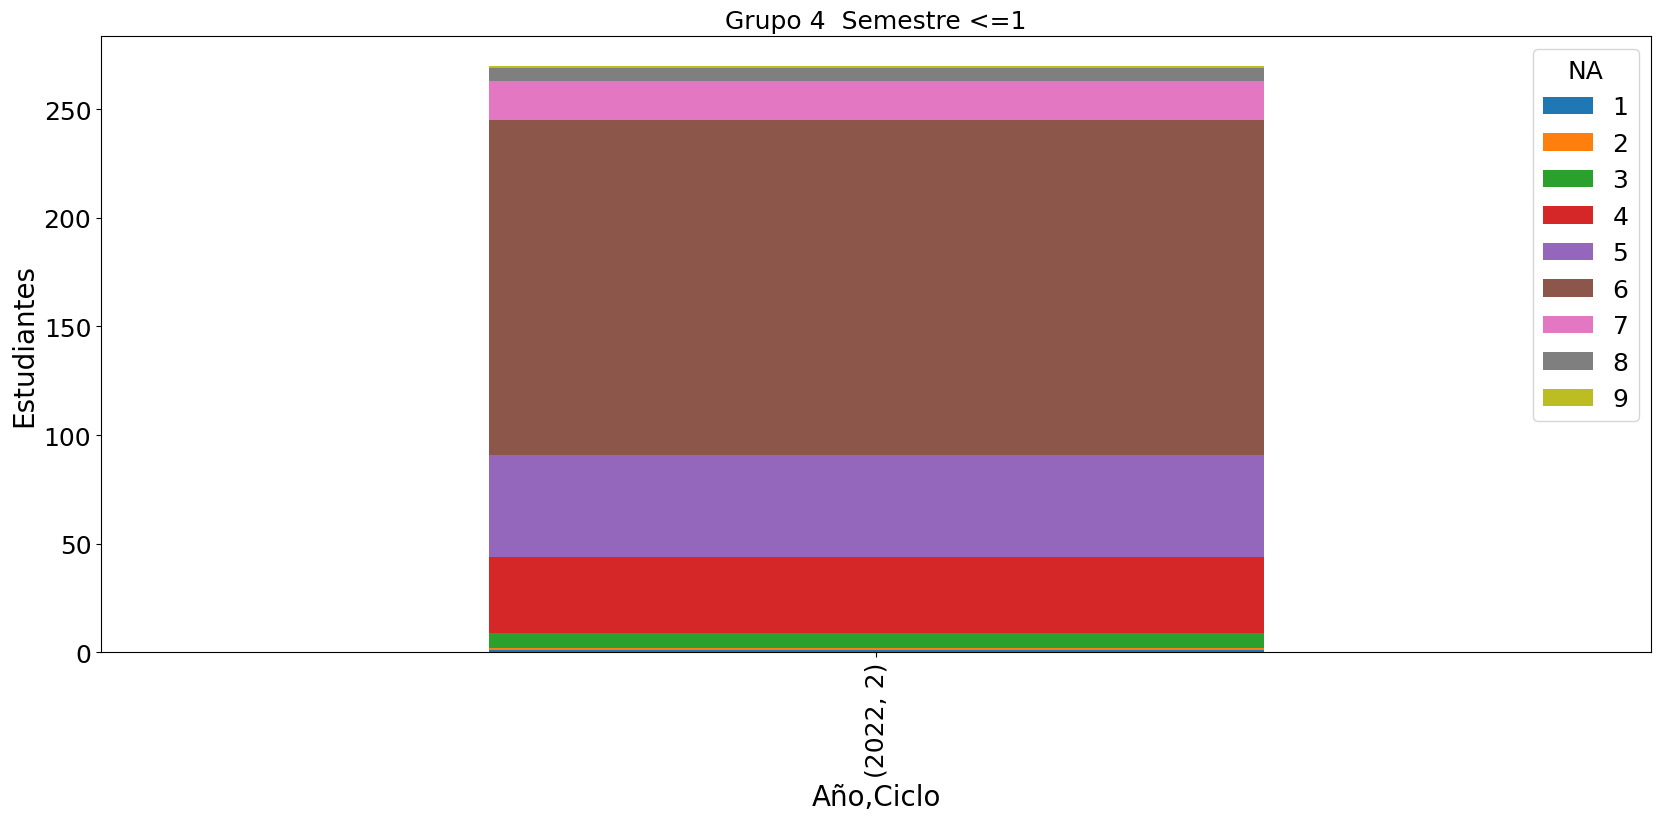

295
   Anho  ciclo  Idalumno  NA
0  2022      2       127   5
1  2022      2       214   7
2  2022      2       241   5
3  2022      2       378   6
4  2022      2       625   6


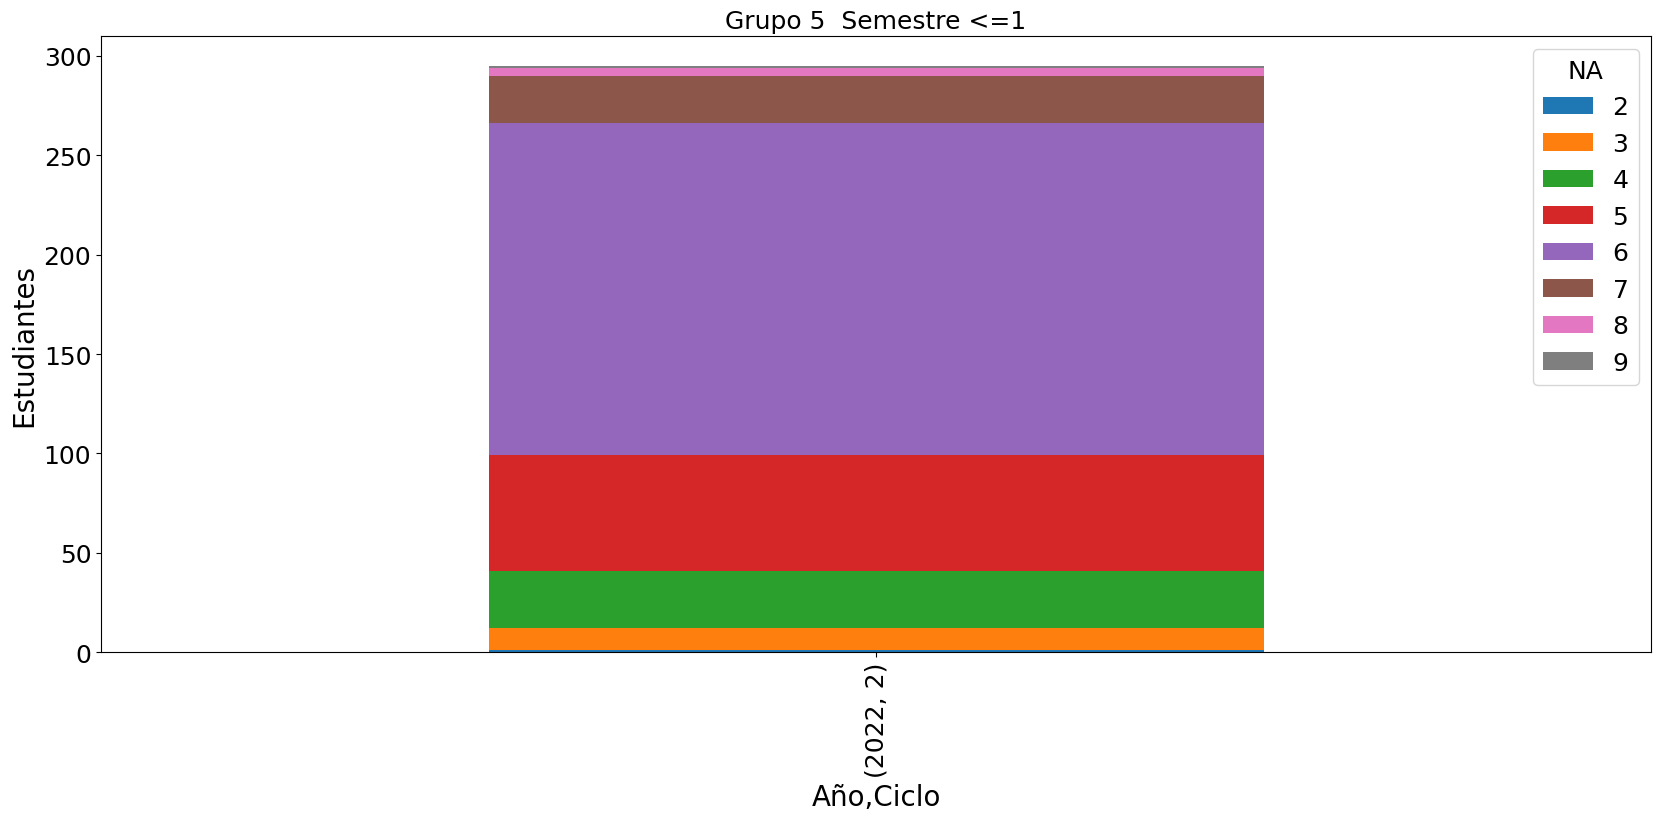

371
   Anho  ciclo  Idalumno  NA
0  2022      2        31   3
1  2022      2       127   5
2  2022      2       134   4
3  2022      2       136   8
4  2022      2       167   5


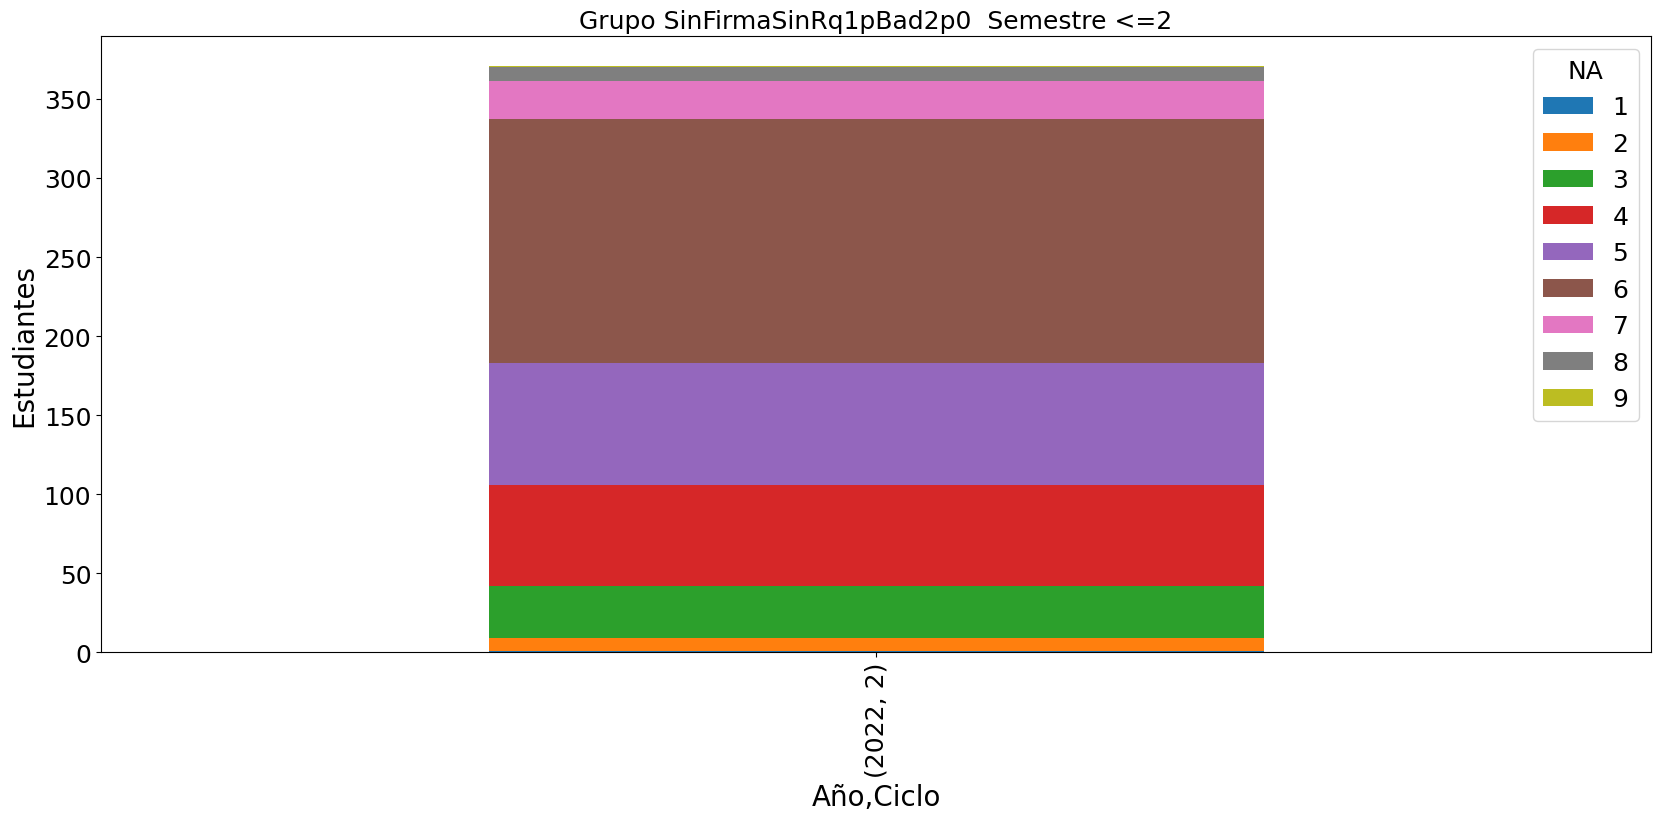

256
   Anho  ciclo  Idalumno  NA
0  2022      2       136   8
1  2022      2       214   7
2  2022      2       271   5
3  2022      2       307   5
4  2022      2       322   5


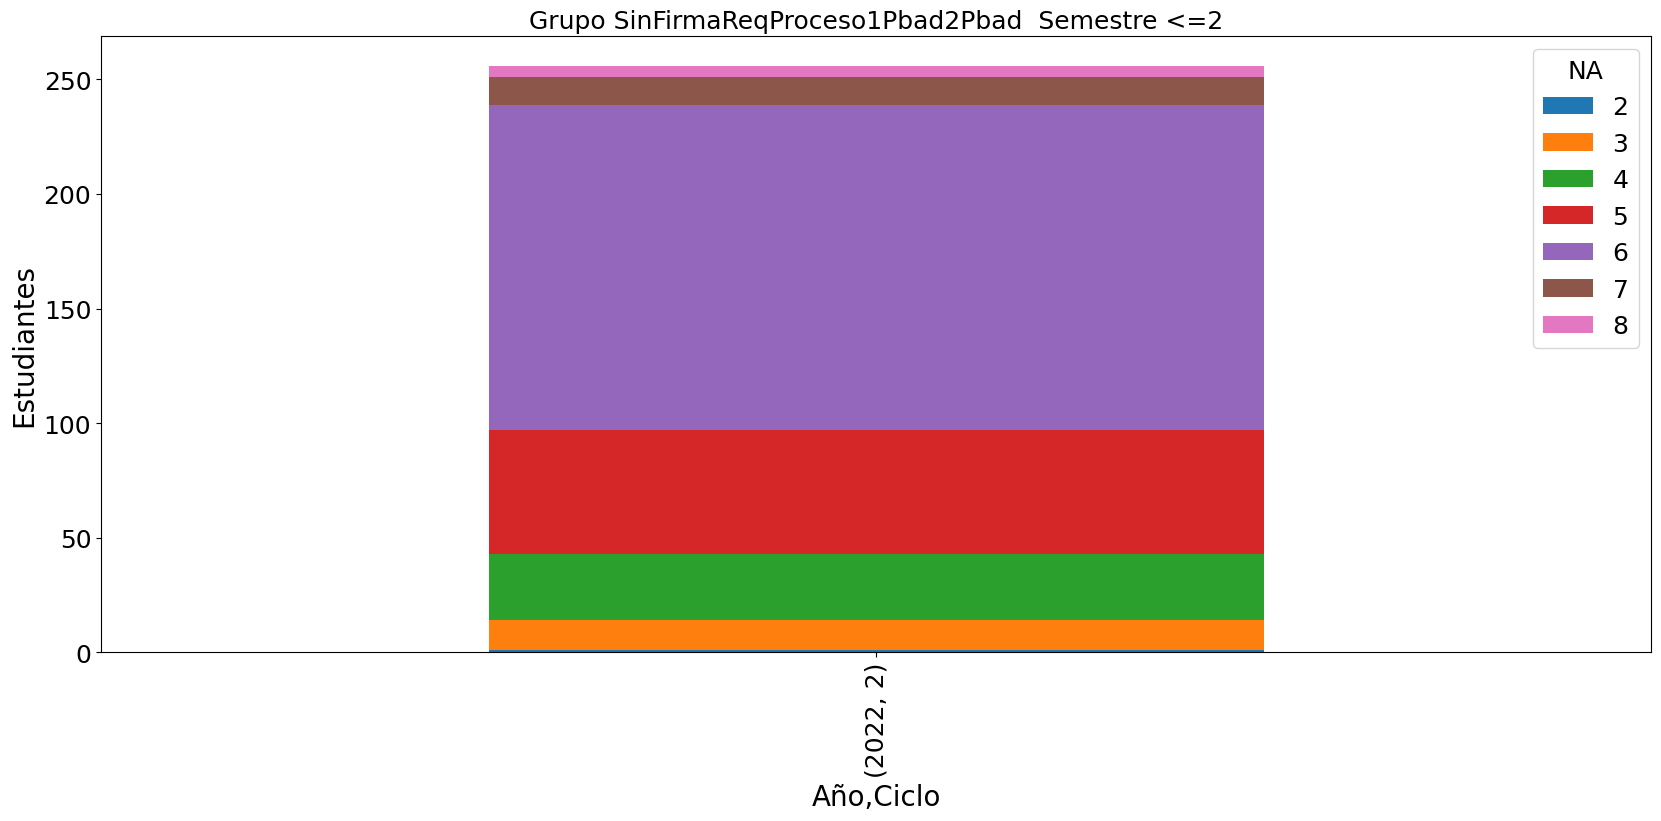

292
   Anho  ciclo  Idalumno  NA
0  2022      2       214   7
1  2022      2       241   5
2  2022      2       271   5
3  2022      2       332   5
4  2022      2       390   4


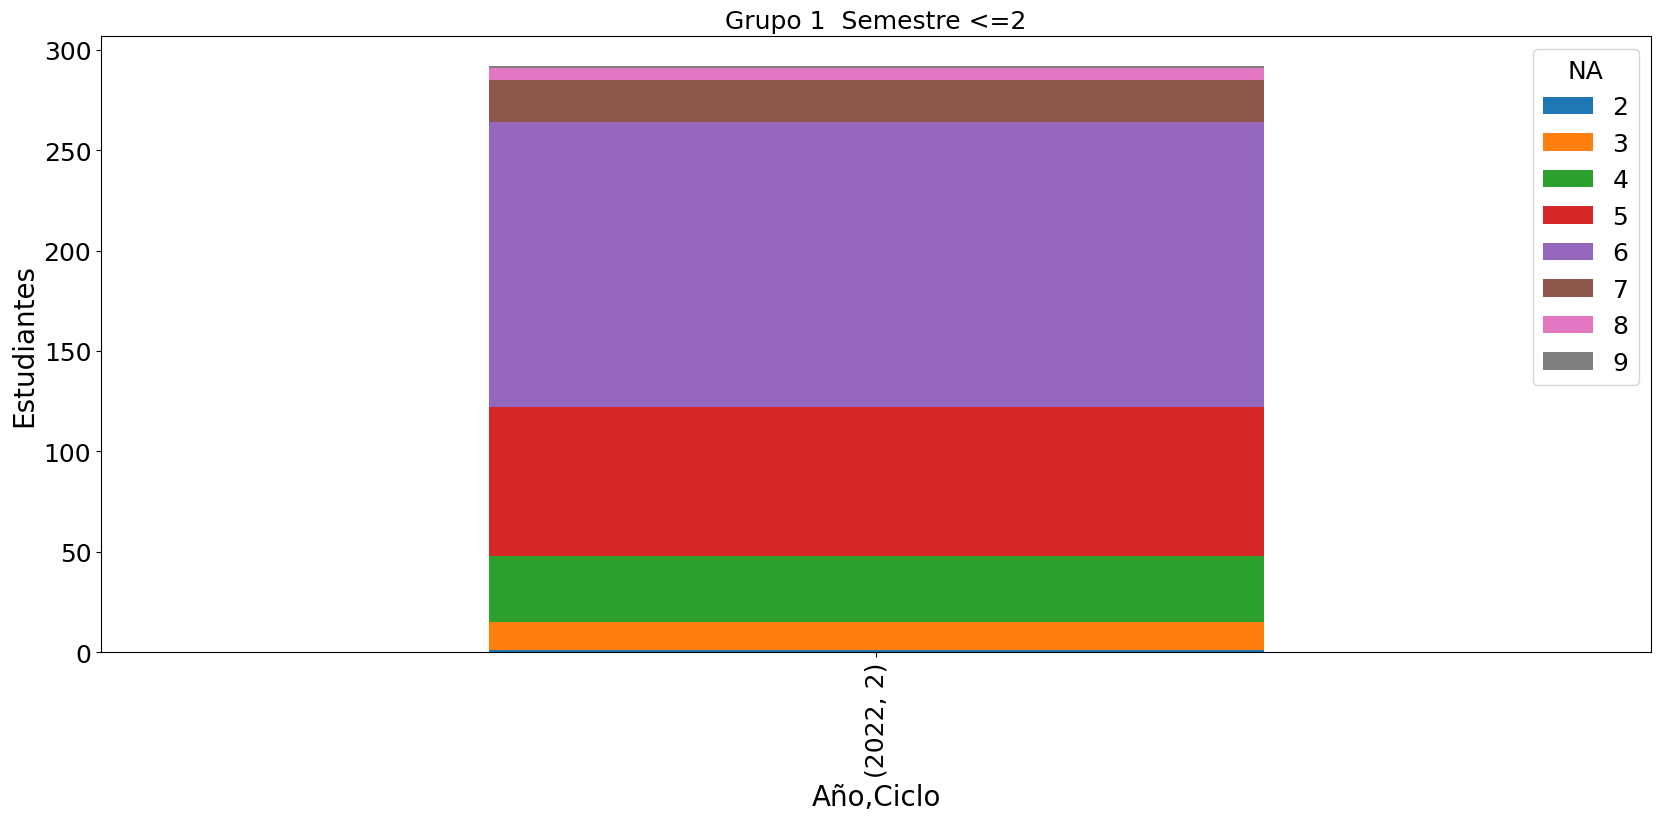

278
   Anho  ciclo  Idalumno  NA
0  2022      2       136   8
1  2022      2       241   5
2  2022      2       297   6
3  2022      2       332   5
4  2022      2       625   6


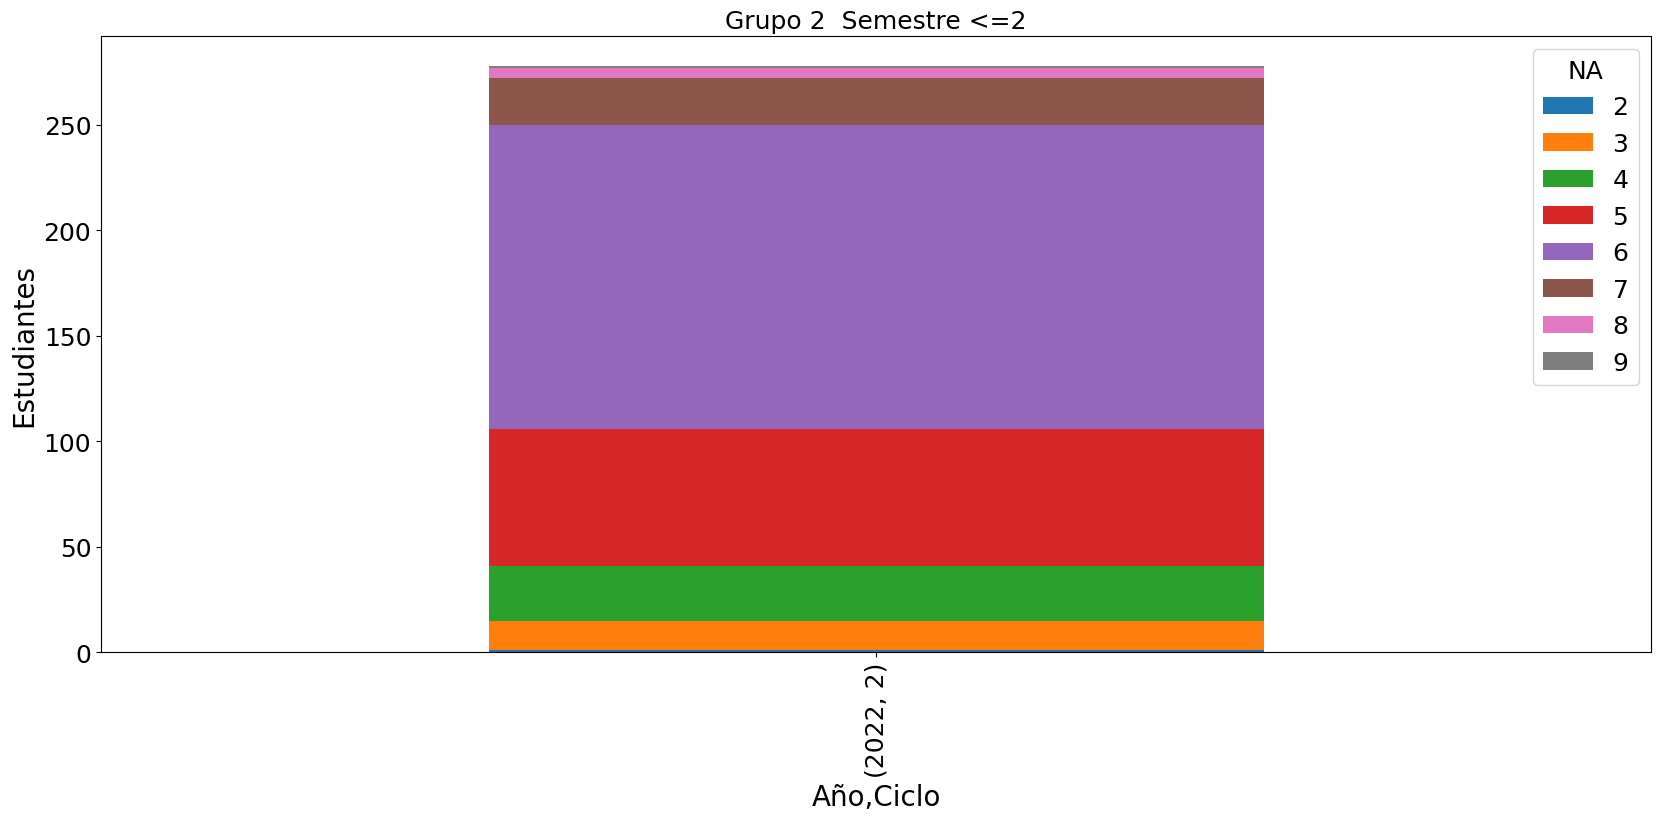

299
   Anho  ciclo  Idalumno  NA
0  2022      2       127   5
1  2022      2       136   8
2  2022      2       378   6
3  2022      2       625   6
4  2022      2       741   3


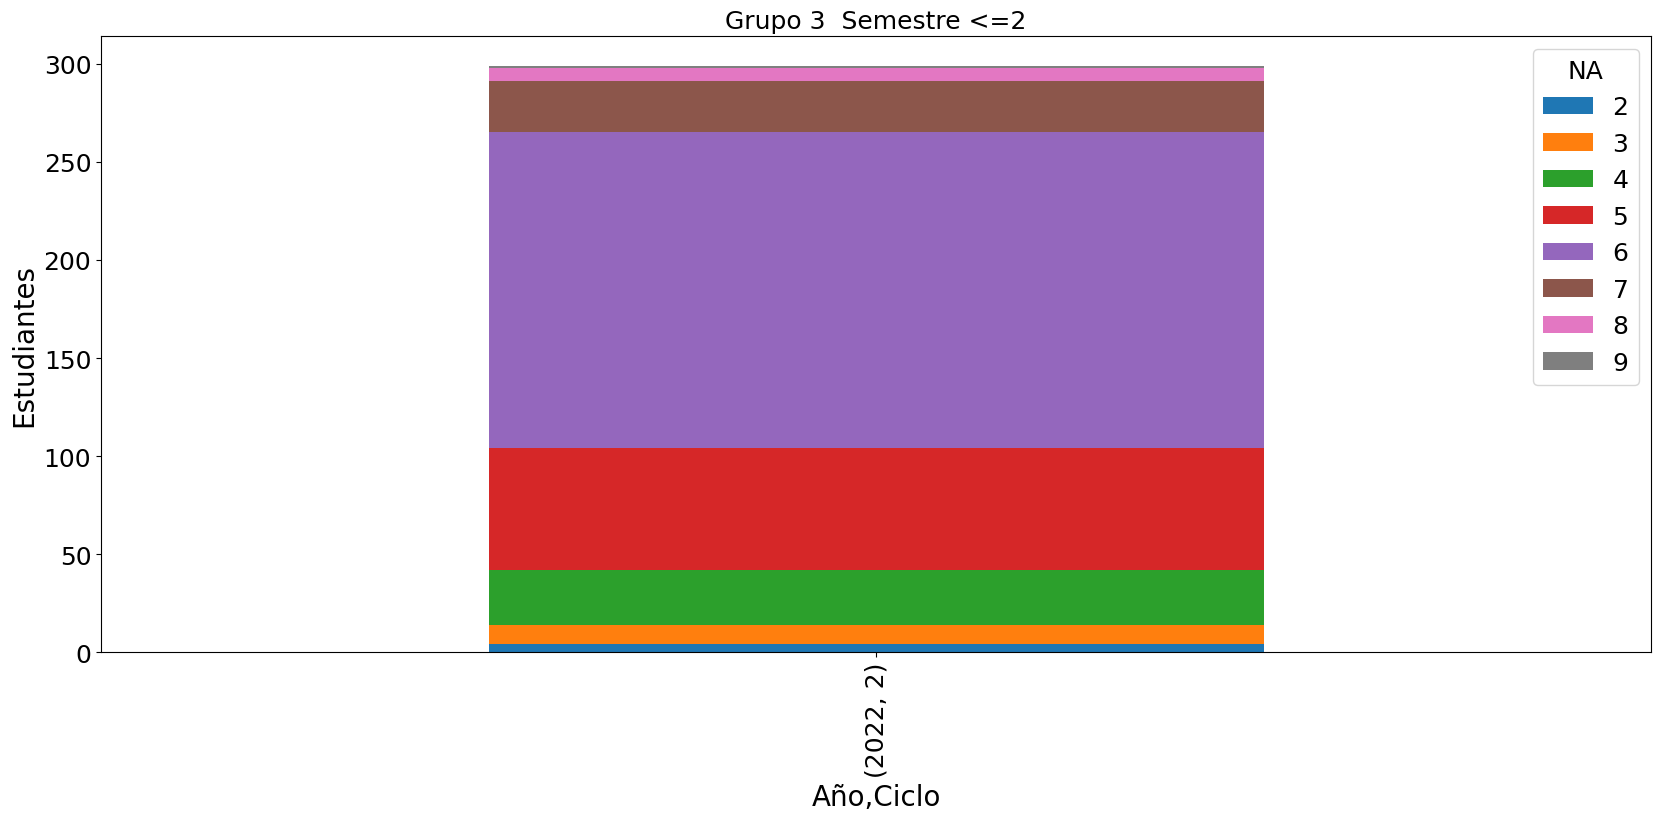

270
   Anho  ciclo  Idalumno  NA
0  2022      2       127   5
1  2022      2       134   4
2  2022      2       136   8
3  2022      2       241   5
4  2022      2       297   6


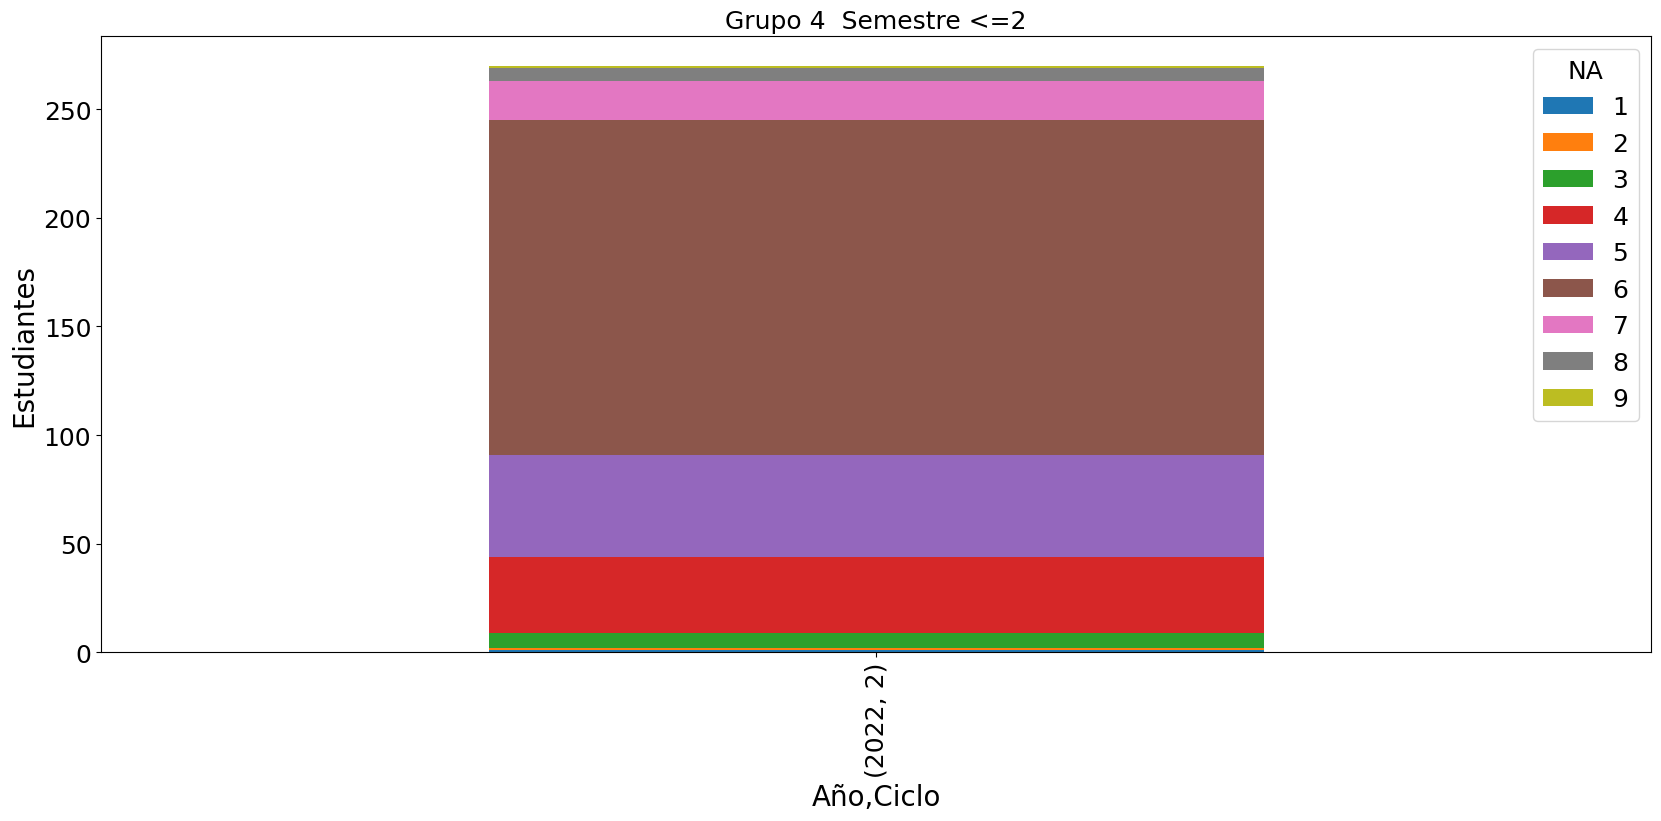

295
   Anho  ciclo  Idalumno  NA
0  2022      2       127   5
1  2022      2       214   7
2  2022      2       241   5
3  2022      2       378   6
4  2022      2       625   6


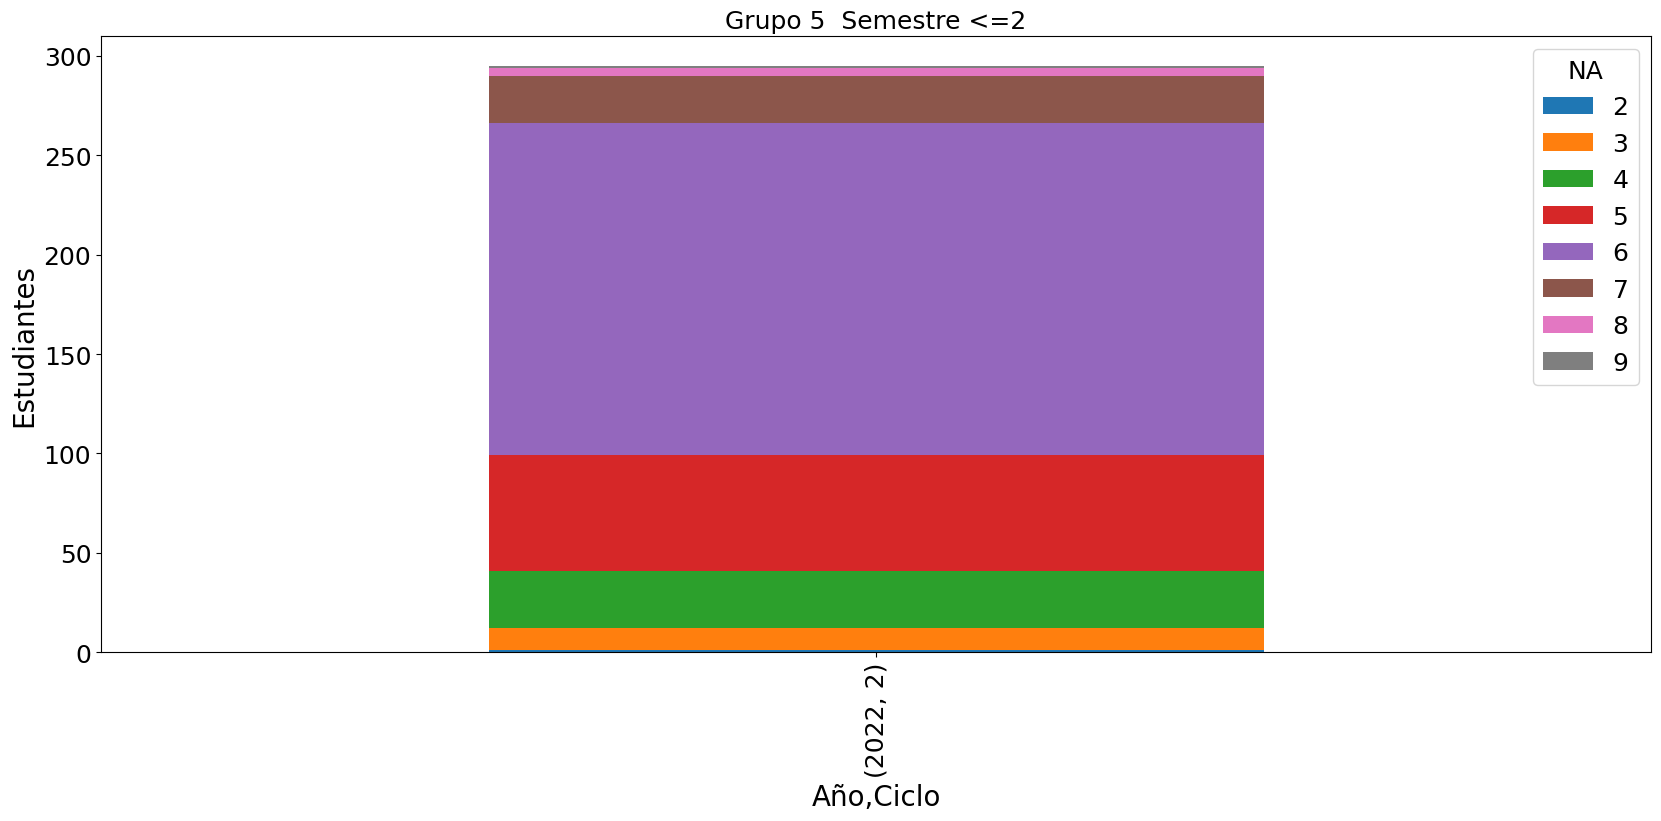

746
   Anho  ciclo  Idalumno  NA
0  2022      2         1   4
1  2022      2        15   4
2  2022      2        21   5
3  2022      2        22   7
4  2022      2        23   3


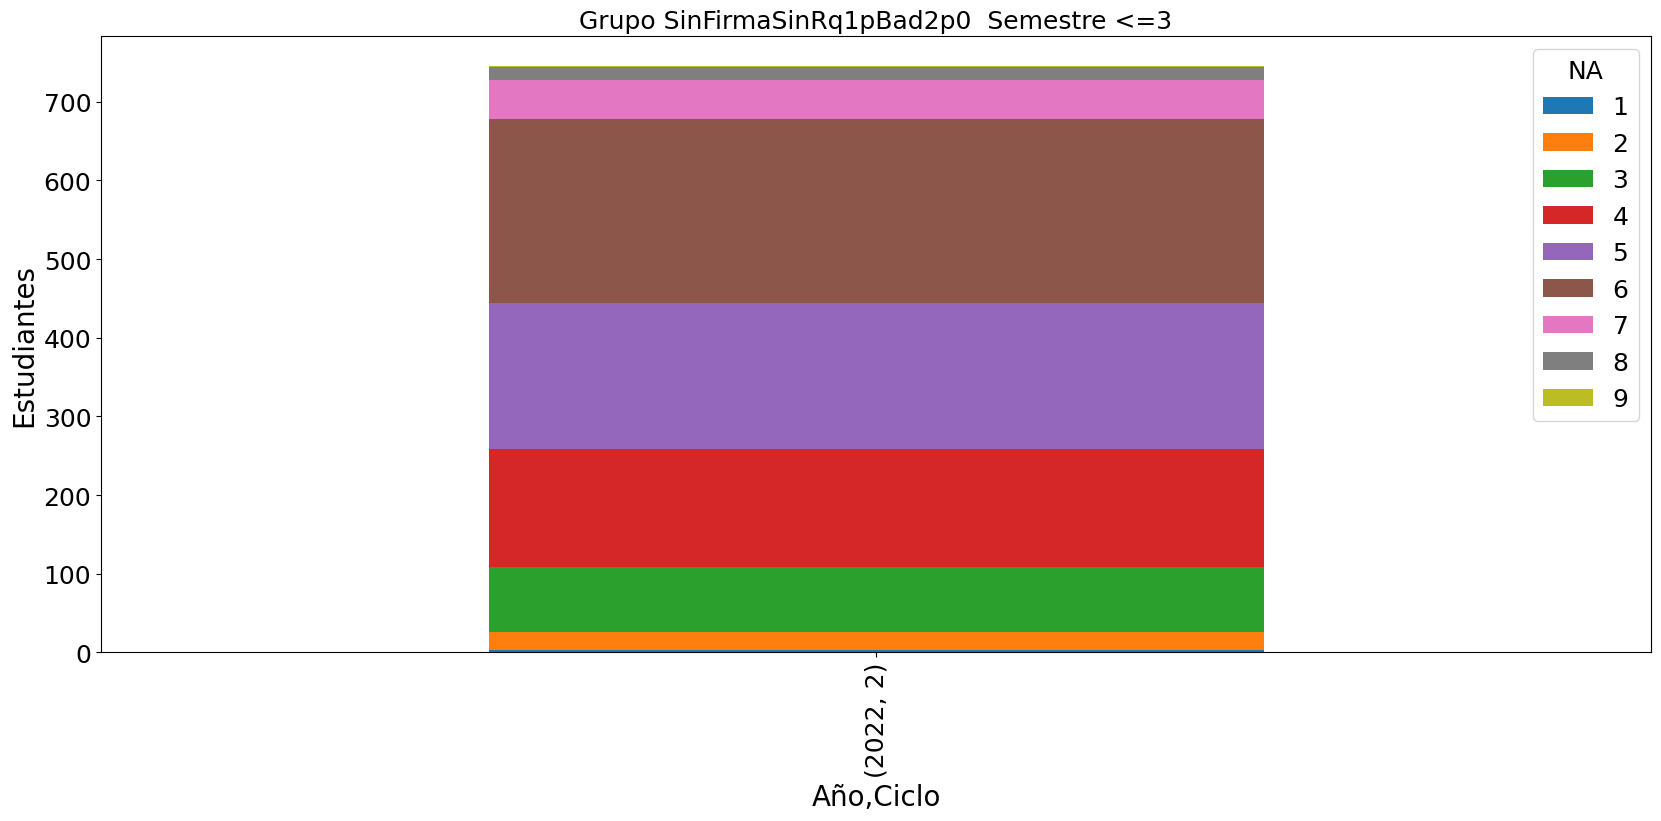

454
   Anho  ciclo  Idalumno  NA
0  2022      2        15   4
1  2022      2        95   1
2  2022      2       136   8
3  2022      2       175   3
4  2022      2       193   3


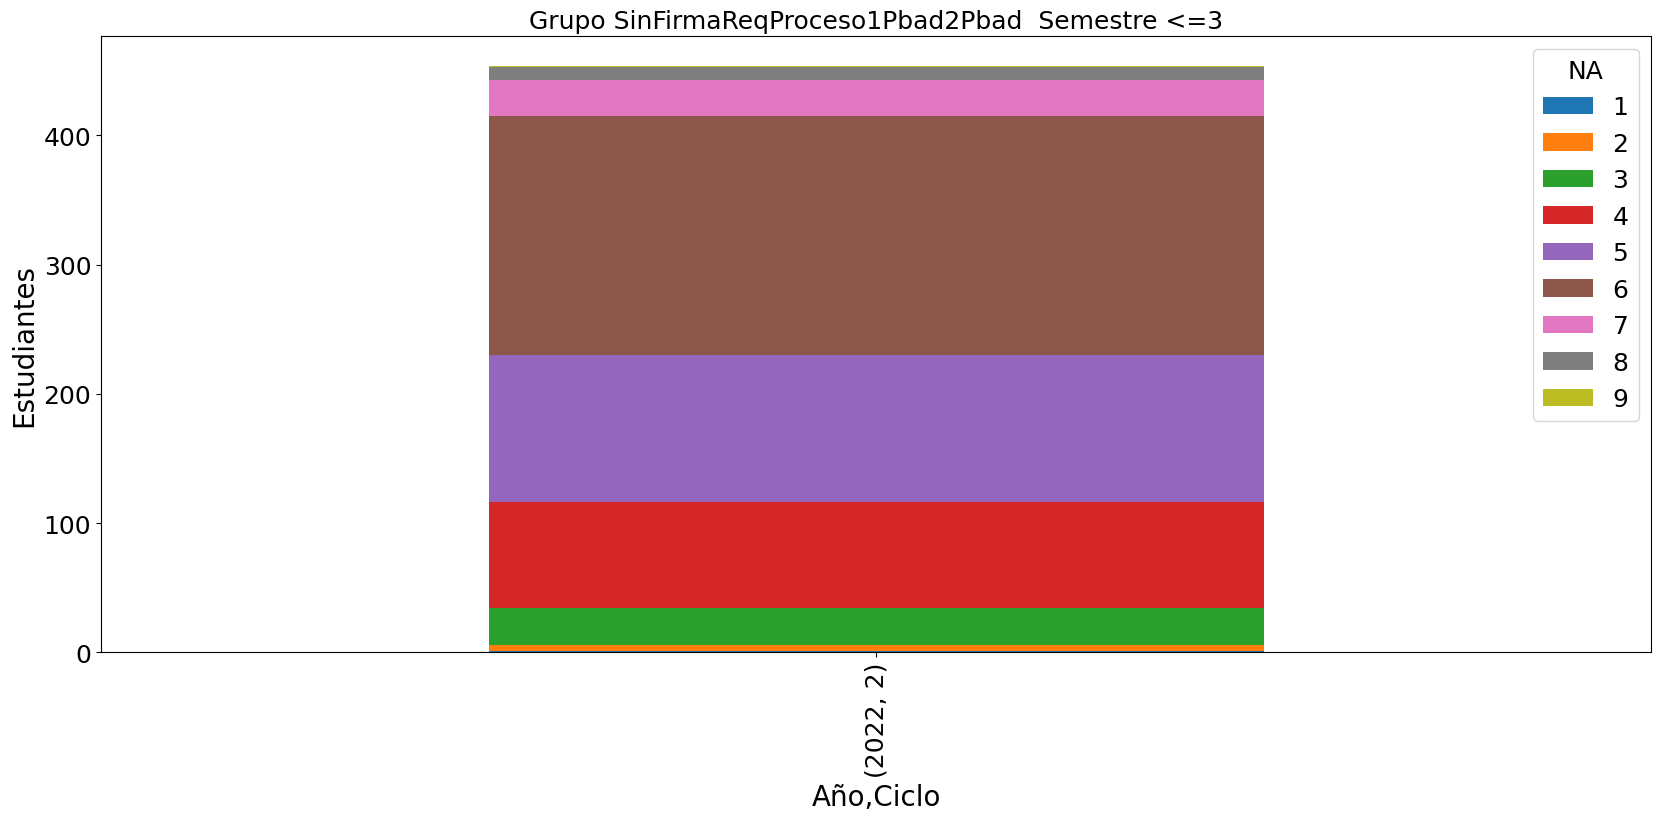

509
   Anho  ciclo  Idalumno  NA
0  2022      2        93   4
1  2022      2       190   7
2  2022      2       193   3
3  2022      2       204   5
4  2022      2       214   7


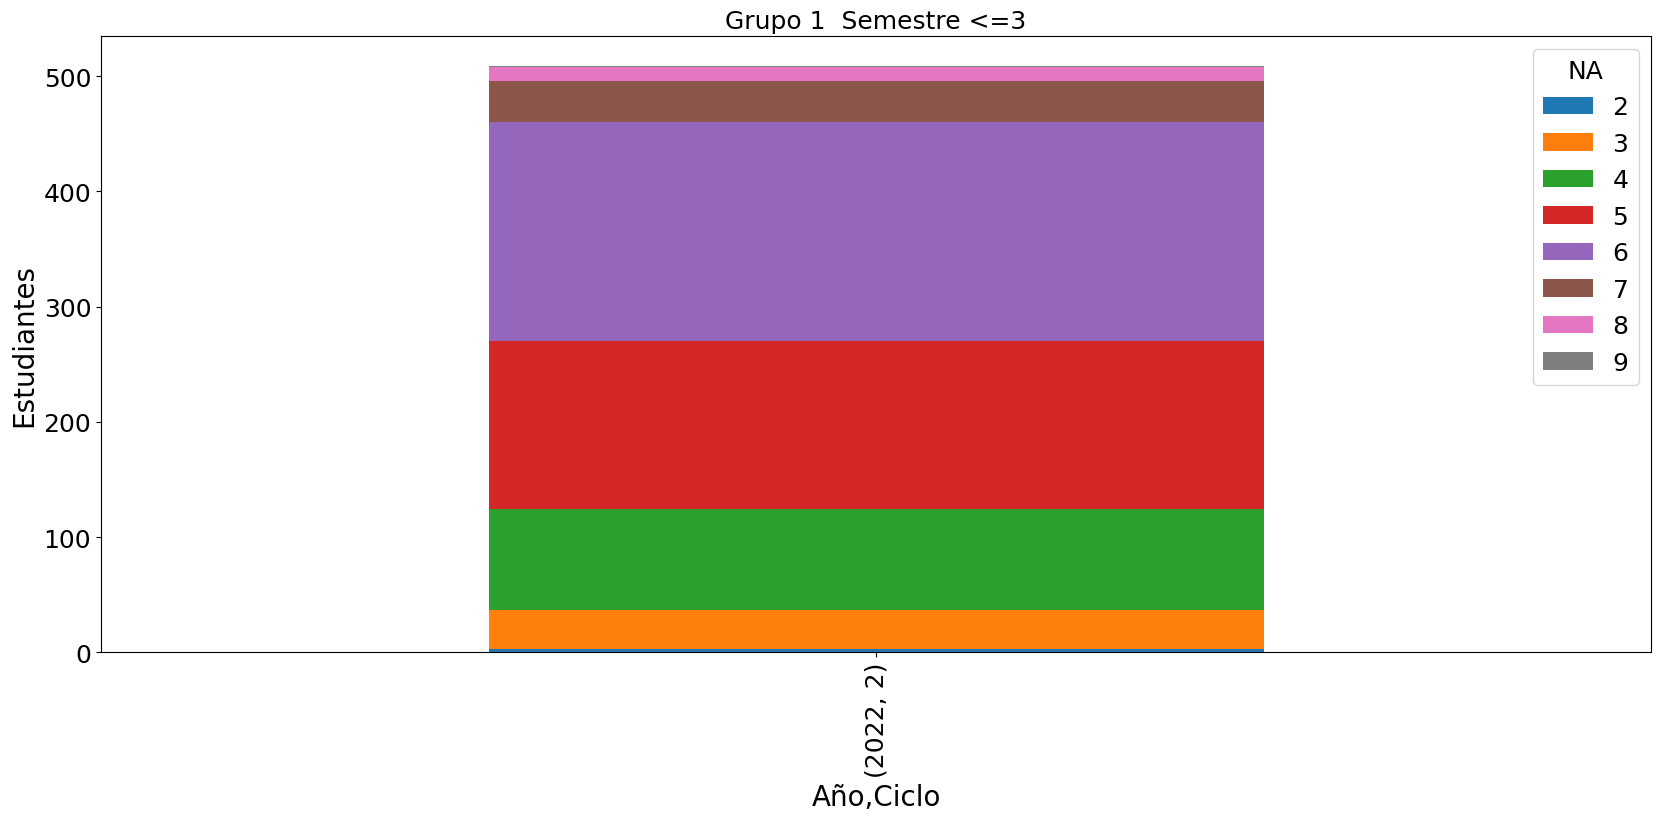

496
   Anho  ciclo  Idalumno  NA
0  2022      2        81   4
1  2022      2        94   1
2  2022      2       136   8
3  2022      2       147   6
4  2022      2       231   7


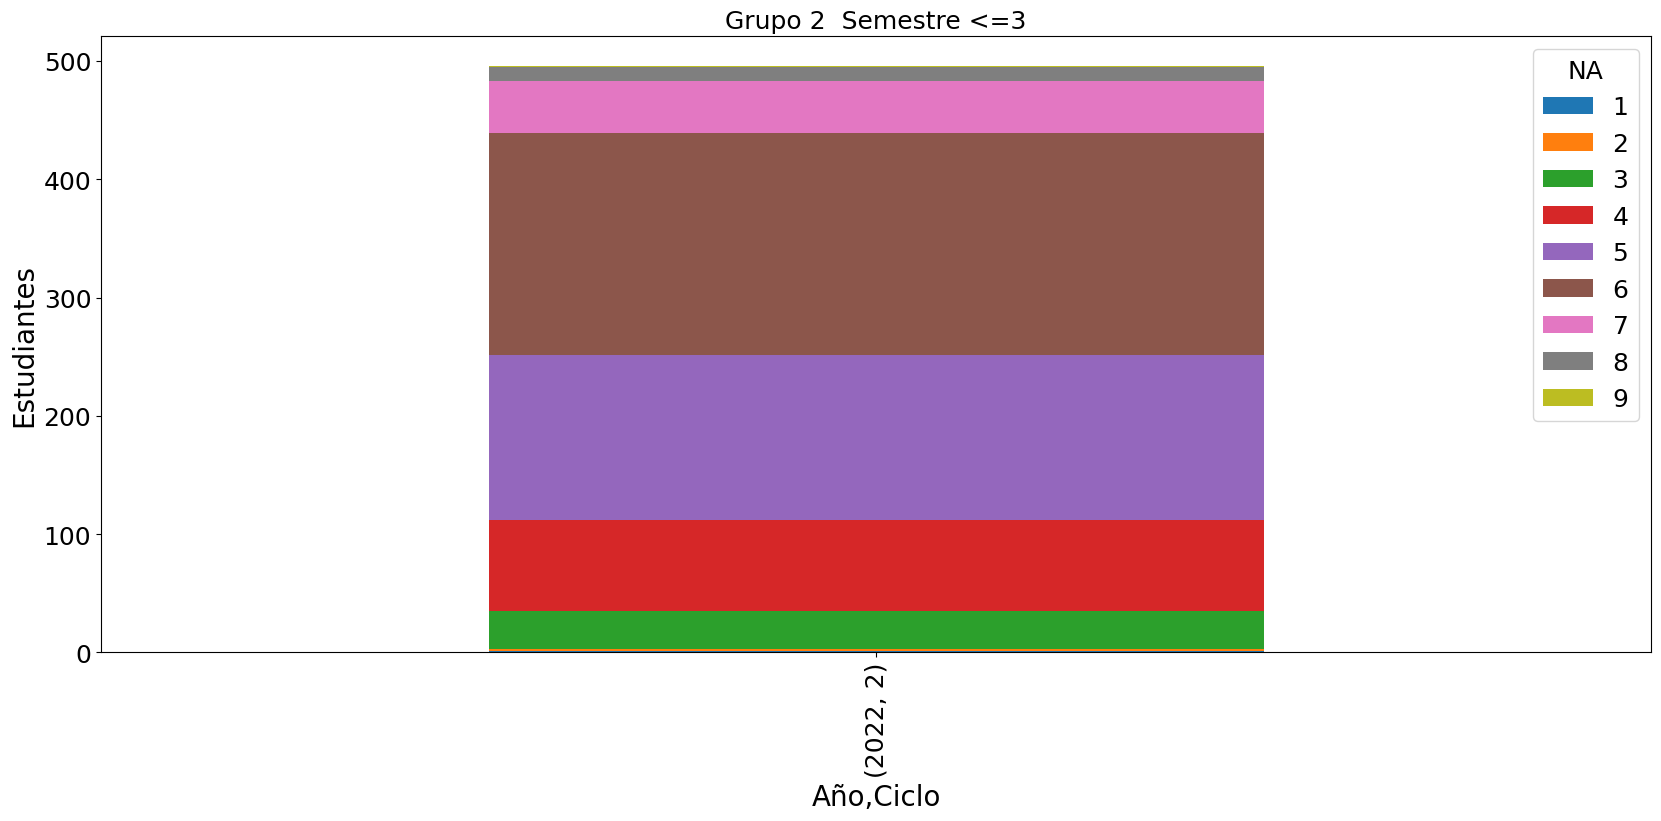

495
   Anho  ciclo  Idalumno  NA
0  2022      2        22   7
1  2022      2        23   3
2  2022      2        81   4
3  2022      2       119   6
4  2022      2       127   5


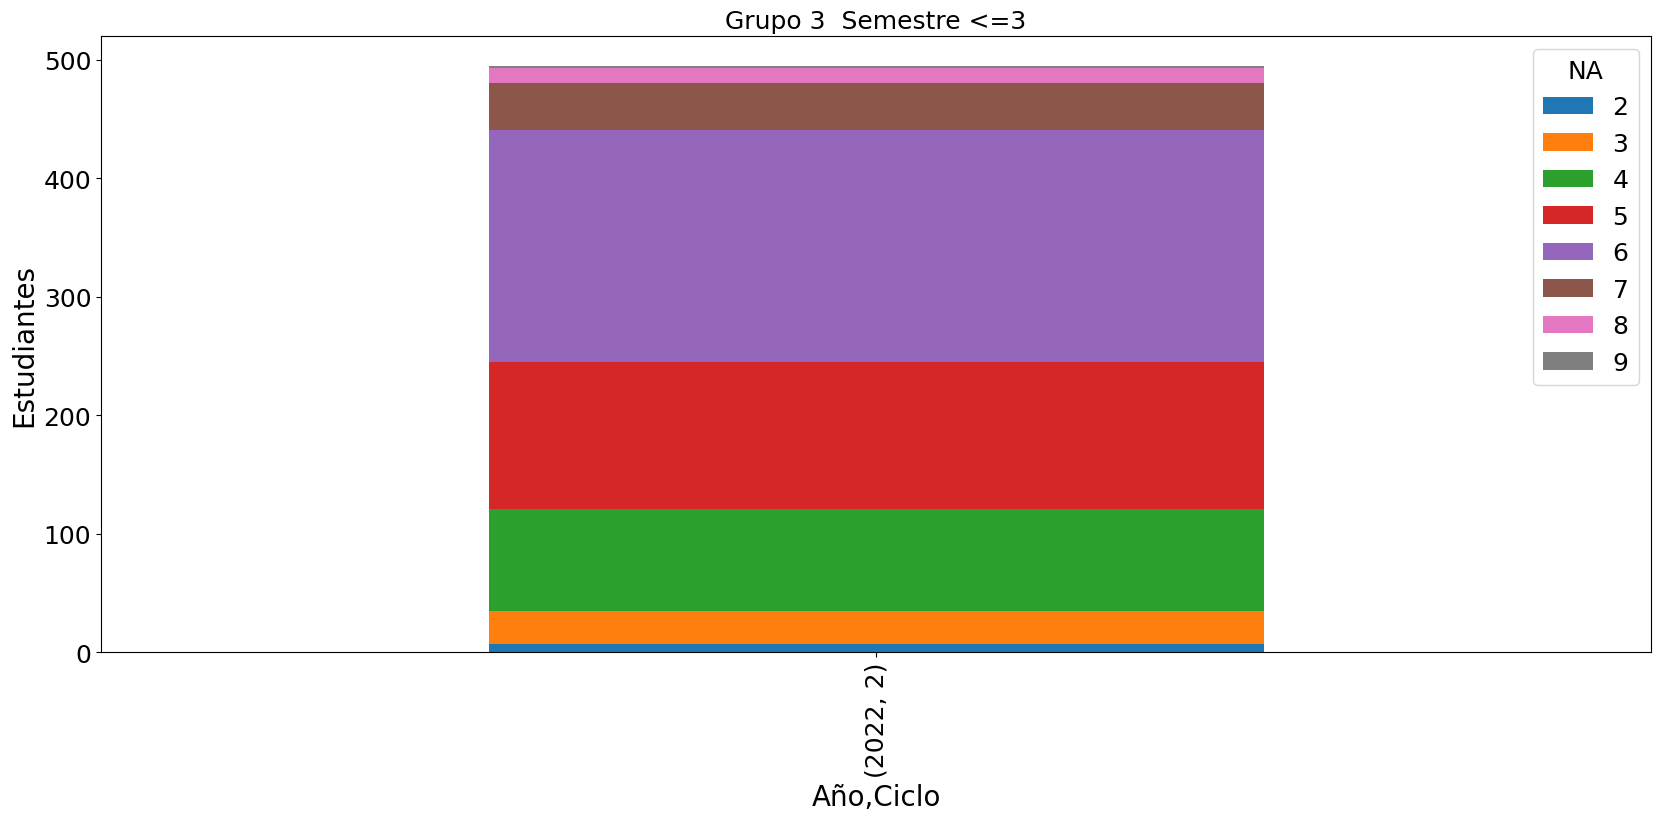

440
   Anho  ciclo  Idalumno  NA
0  2022      2        22   7
1  2022      2        59   6
2  2022      2        93   4
3  2022      2       119   6
4  2022      2       127   5


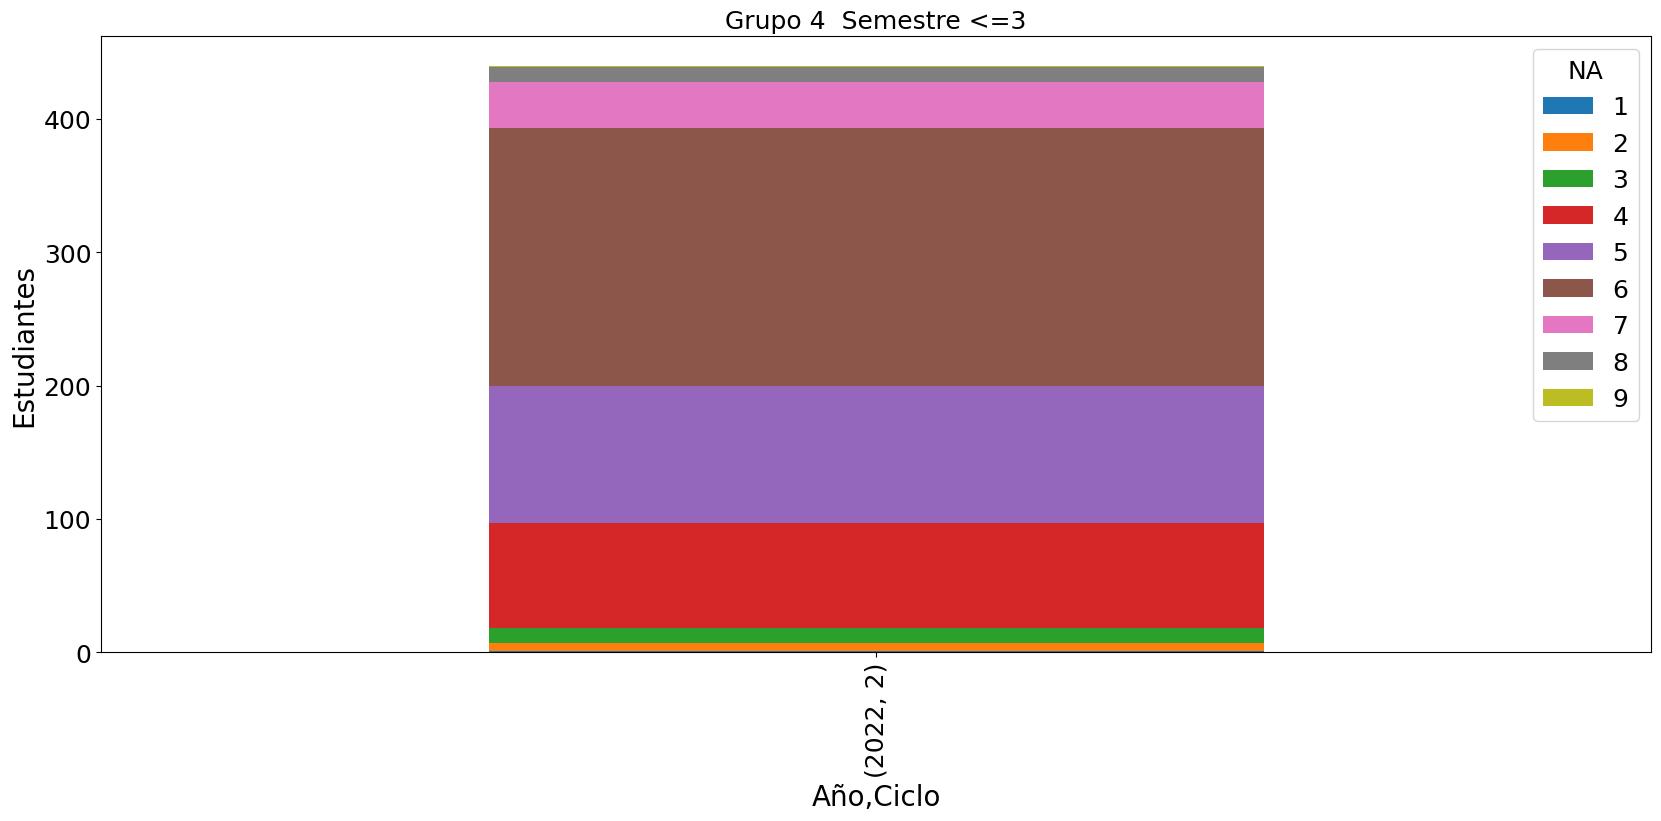

508
   Anho  ciclo  Idalumno  NA
0  2022      2         1   4
1  2022      2        22   7
2  2022      2        23   3
3  2022      2        33   4
4  2022      2       116   5


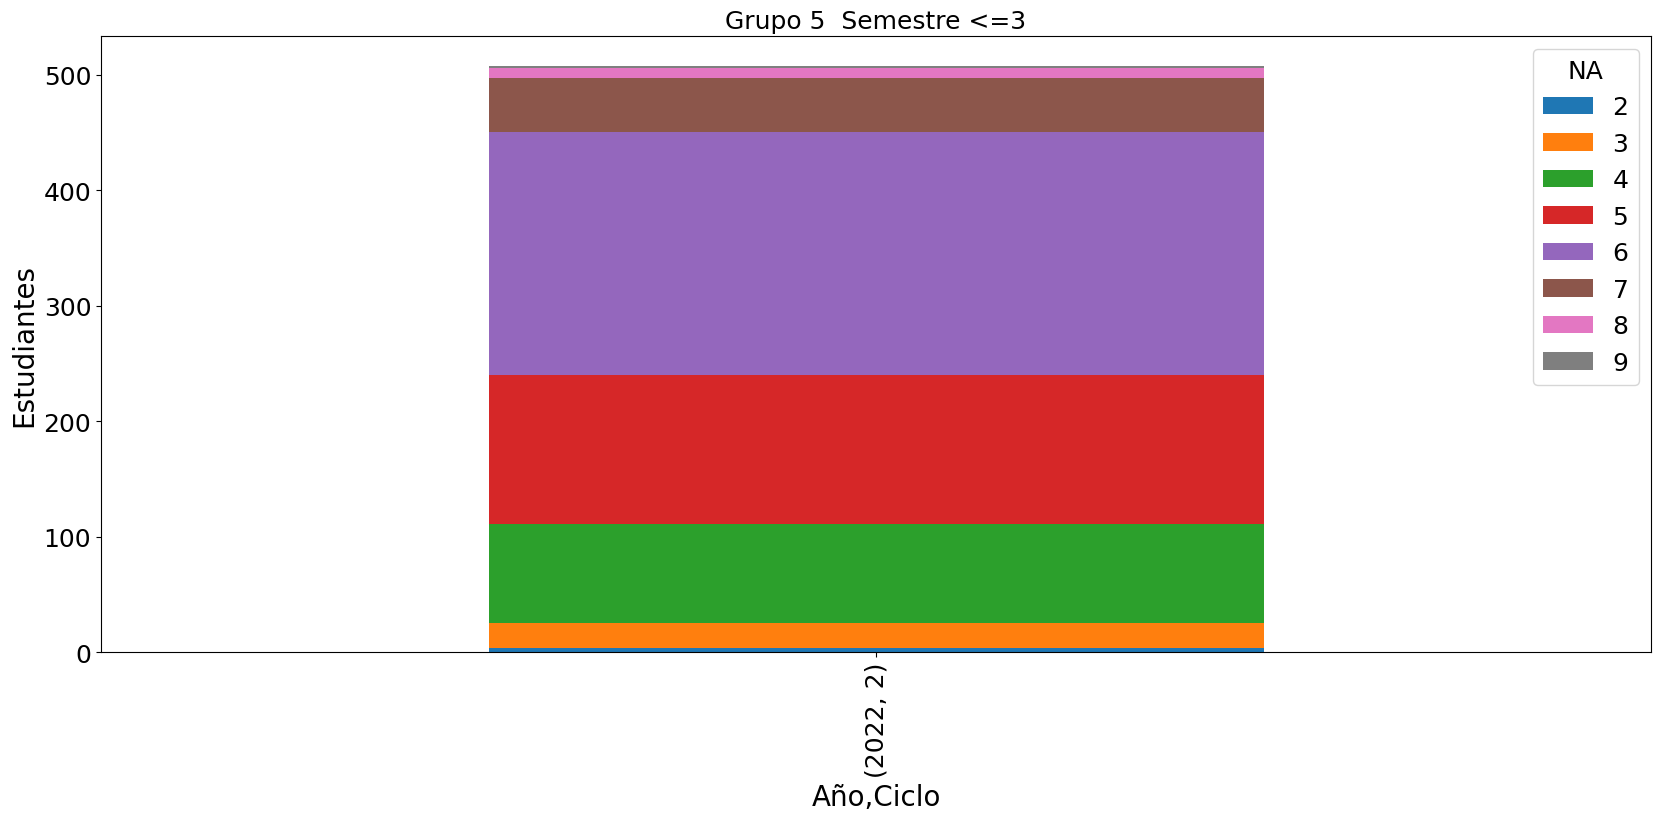

901
   Anho  ciclo  Idalumno  NA
0  2022      2         1   4
1  2022      2        15   4
2  2022      2        21   5
3  2022      2        22   7
4  2022      2        23   3


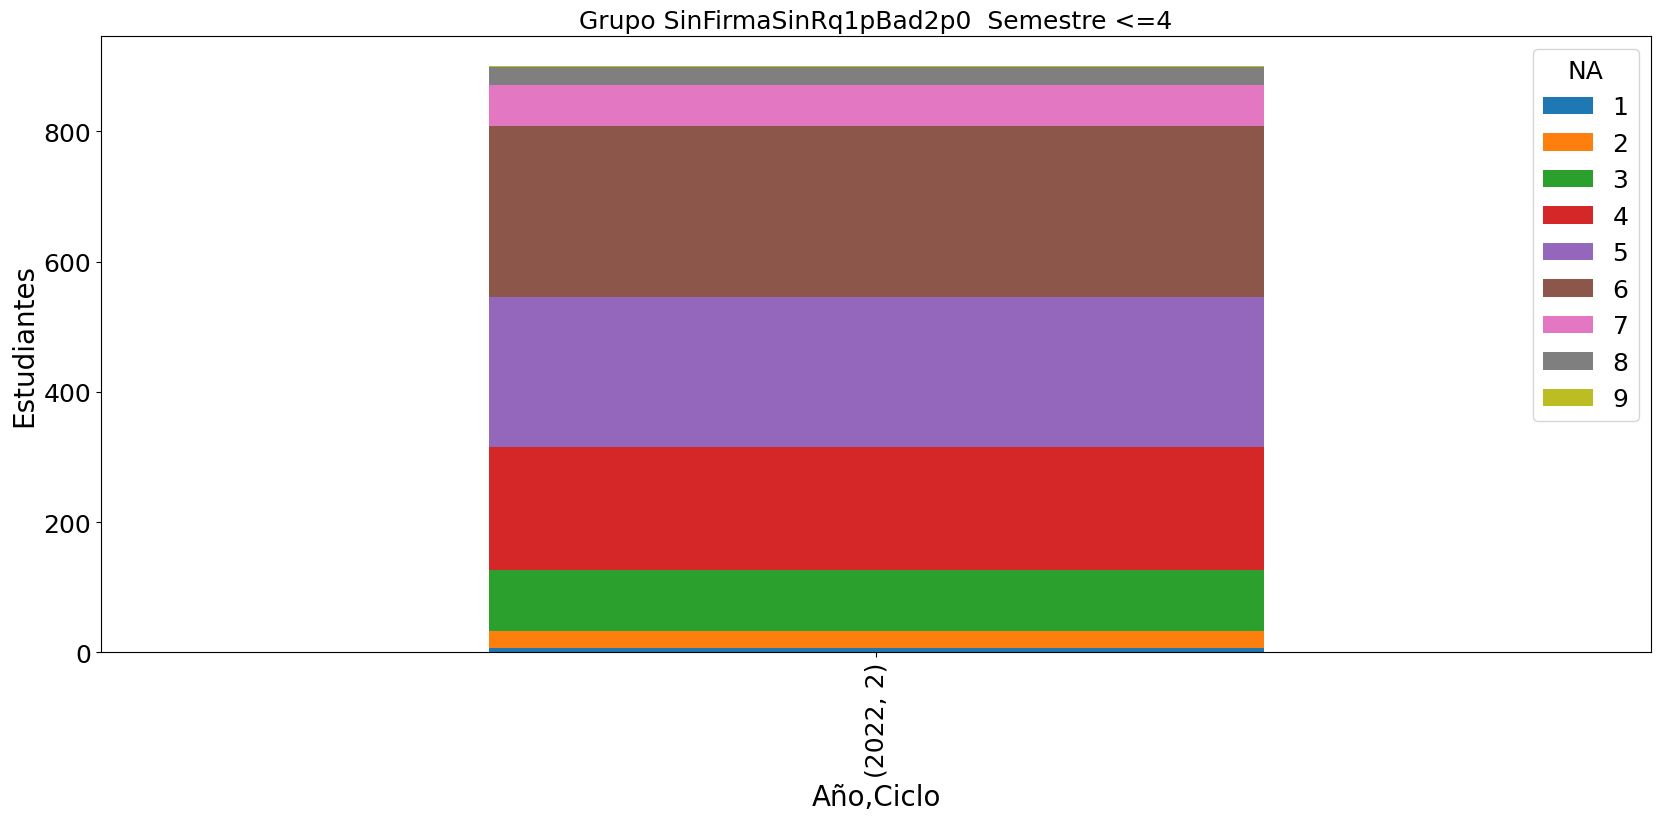

562
   Anho  ciclo  Idalumno  NA
0  2022      2        15   4
1  2022      2        32   5
2  2022      2        65   3
3  2022      2        67   1
4  2022      2        95   1


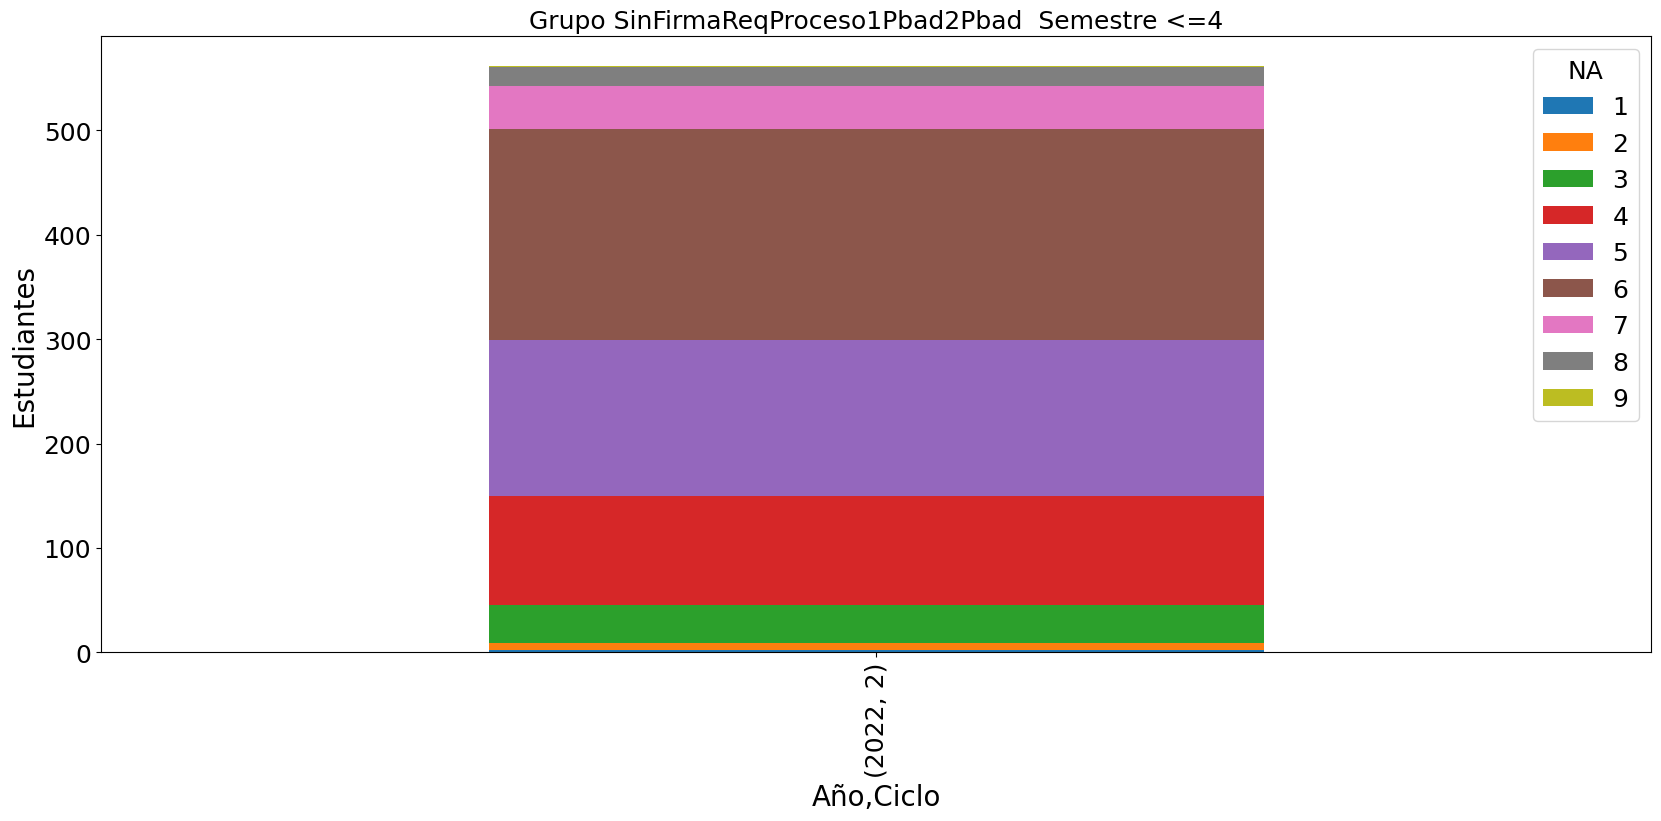

633
   Anho  ciclo  Idalumno  NA
0  2022      2        85   6
1  2022      2        93   4
2  2022      2       111   6
3  2022      2       190   7
4  2022      2       193   3


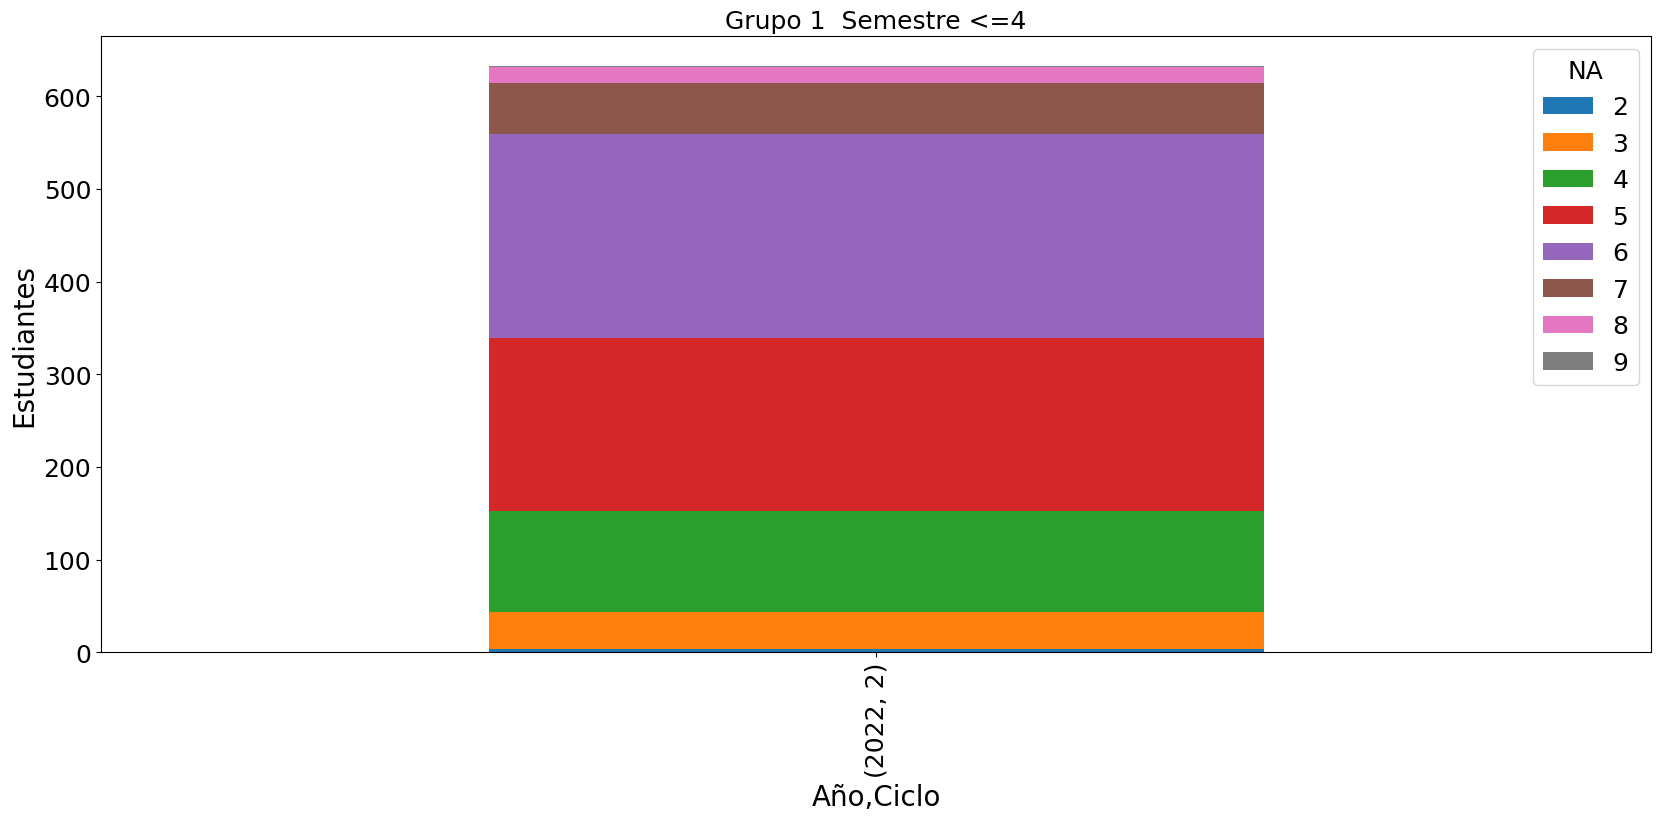

679
   Anho  ciclo  Idalumno  NA
0  2022      2         2   5
1  2022      2        81   4
2  2022      2        94   1
3  2022      2       136   8
4  2022      2       147   6


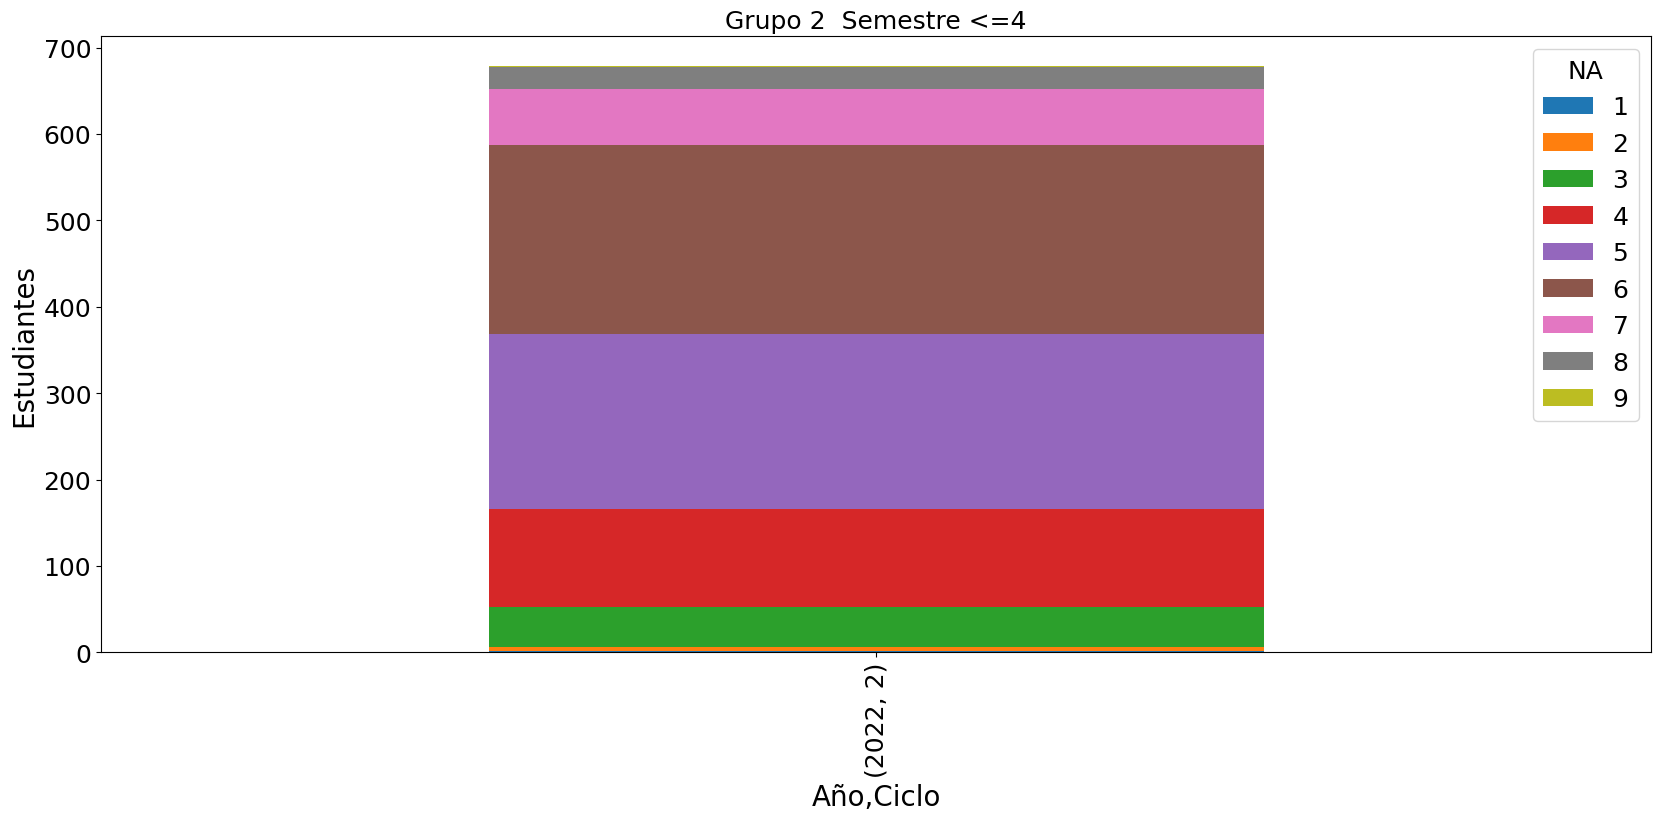

652
   Anho  ciclo  Idalumno  NA
0  2022      2        22   7
1  2022      2        23   3
2  2022      2        65   3
3  2022      2        81   4
4  2022      2       109   6


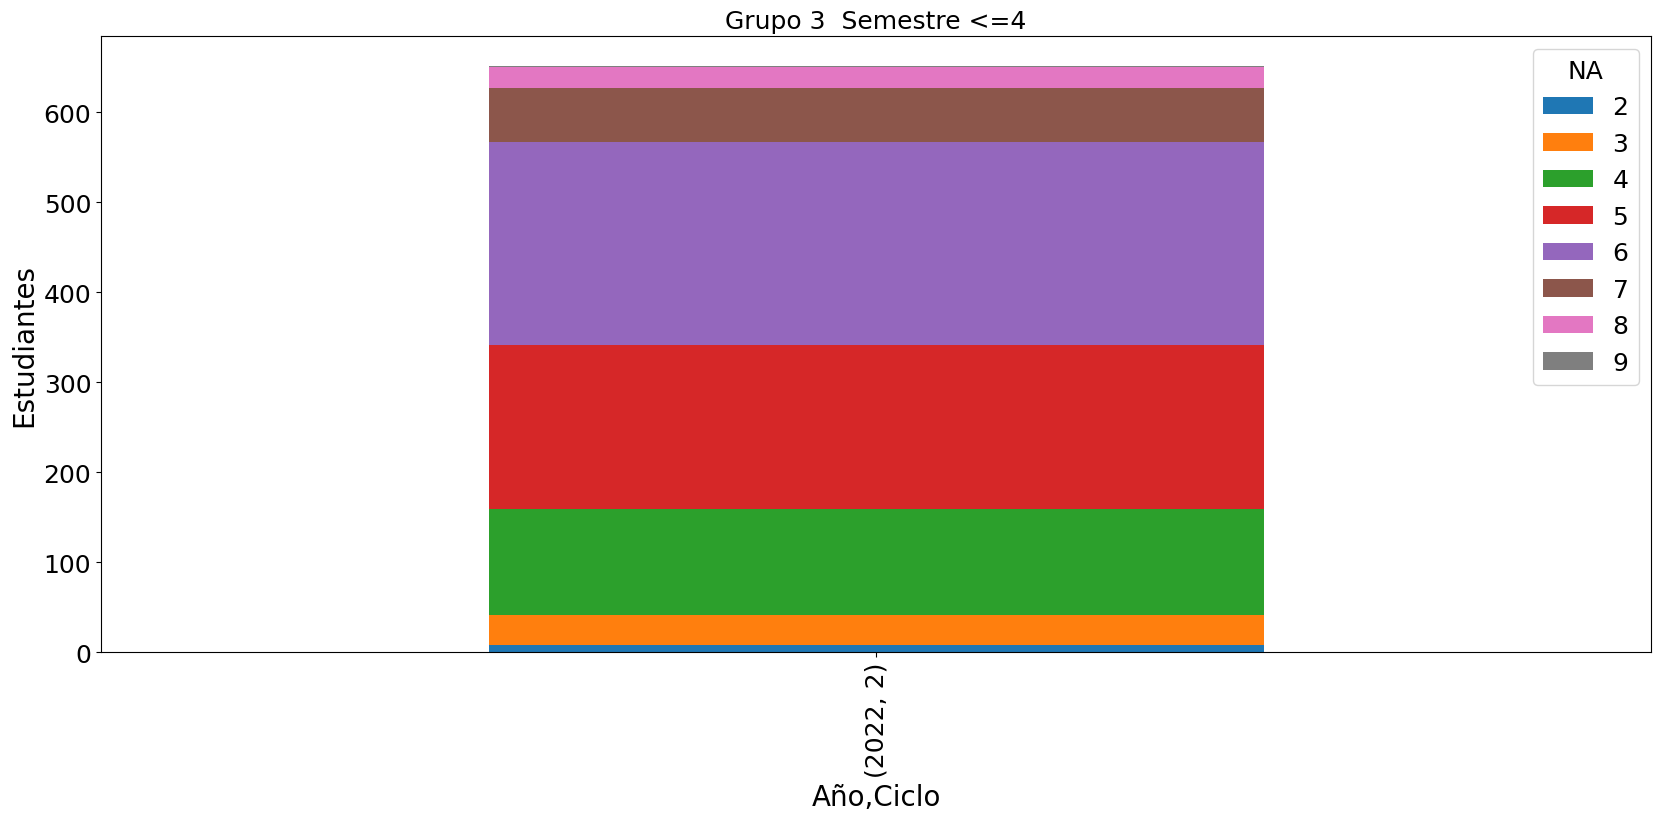

583
   Anho  ciclo  Idalumno  NA
0  2022      2         2   5
1  2022      2        22   7
2  2022      2        59   6
3  2022      2        93   4
4  2022      2       119   6


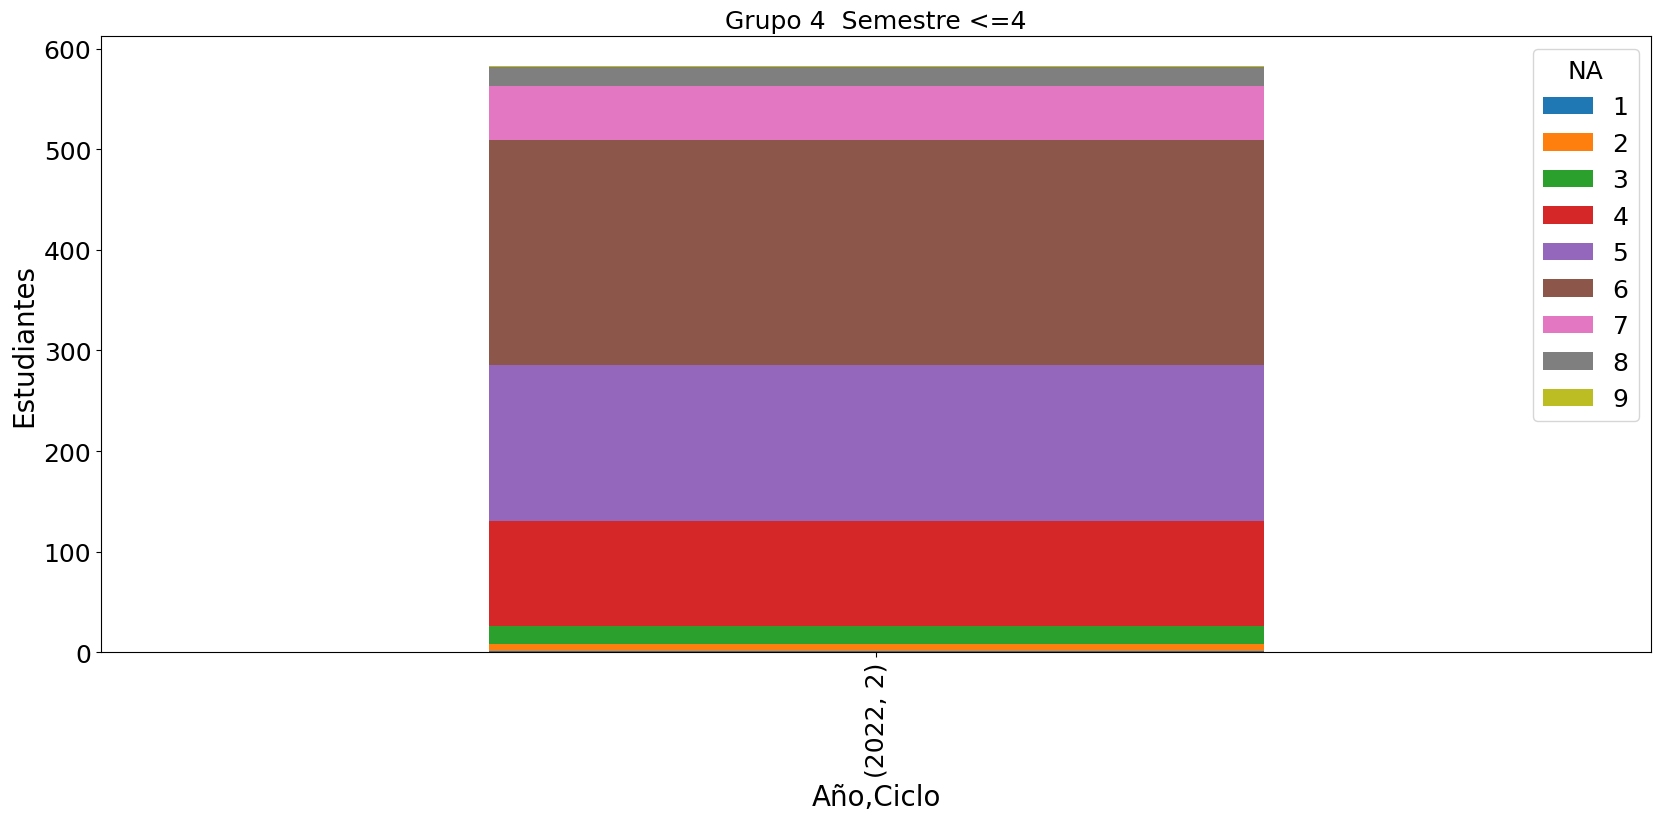

717
   Anho  ciclo  Idalumno  NA
0  2022      2         1   4
1  2022      2         2   5
2  2022      2        22   7
3  2022      2        23   3
4  2022      2        33   4


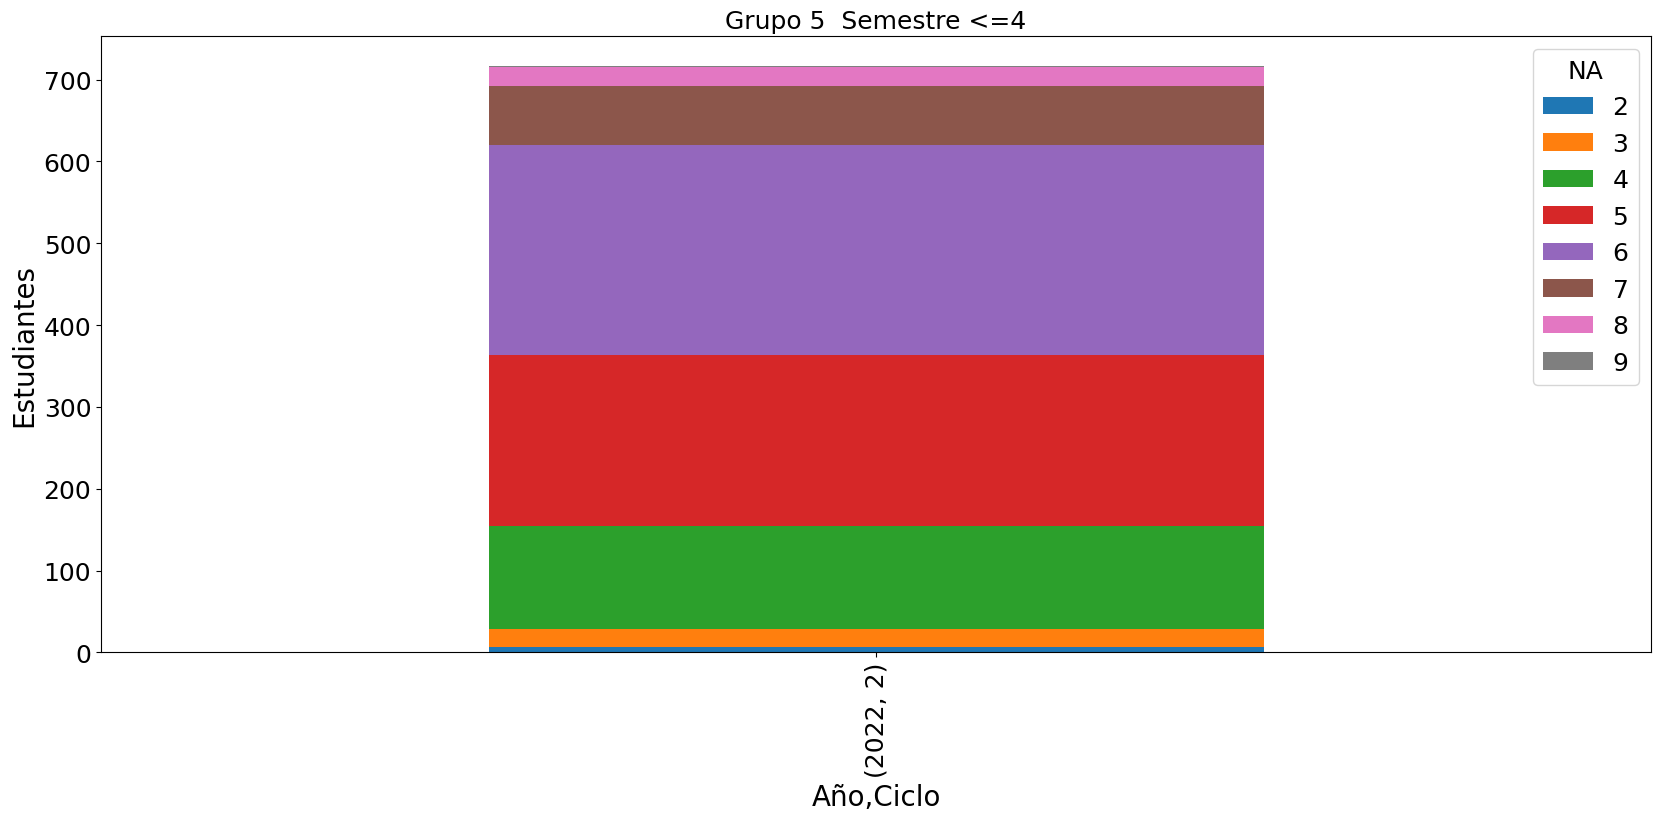

In [41]:
df=data
for s in [1,2,3,4]:
    for gg in ['SinFirmaSinRq1pBad2p0','SinFirmaReqProceso1Pbad2Pbad',1,2,3,4,5]:

        lista=df[np.logical_and(df.GrupoNoFinal==gg,df.SemestreAlumno<=s)]   
        lista=lista[['Anho','ciclo','Idalumno']]
        print(len(lista.drop_duplicates()))
        dfg=df.groupby(['Anho','ciclo','Idalumno']).apply(lambda x:len(x['Asignatura'].values) )
        dfgg=dfg.reset_index(name = 'NA')
        combined=pd.merge(dfgg,lista.drop_duplicates(), on=['Anho','ciclo','Idalumno'], how='right')
        print(combined.head())
        dfggg=combined.groupby(['Anho','ciclo','NA'])['Idalumno'].nunique()
    
        f, ax = plt.subplots(figsize=(20, 8))
        ax.set_title("Grupo "+str(gg)+"  Semestre <="+str(s) )

        dfggg.unstack().plot(kind='bar',stacked=True,ax=ax)
        plt.xlabel("Año,Ciclo")
        plt.ylabel("Estudiantes")
        plt.savefig("graficos\HistogramaNasignatures"+str(gg)+"smenor"+str(s)+".png", bbox_inches="tight")

        plt.show()

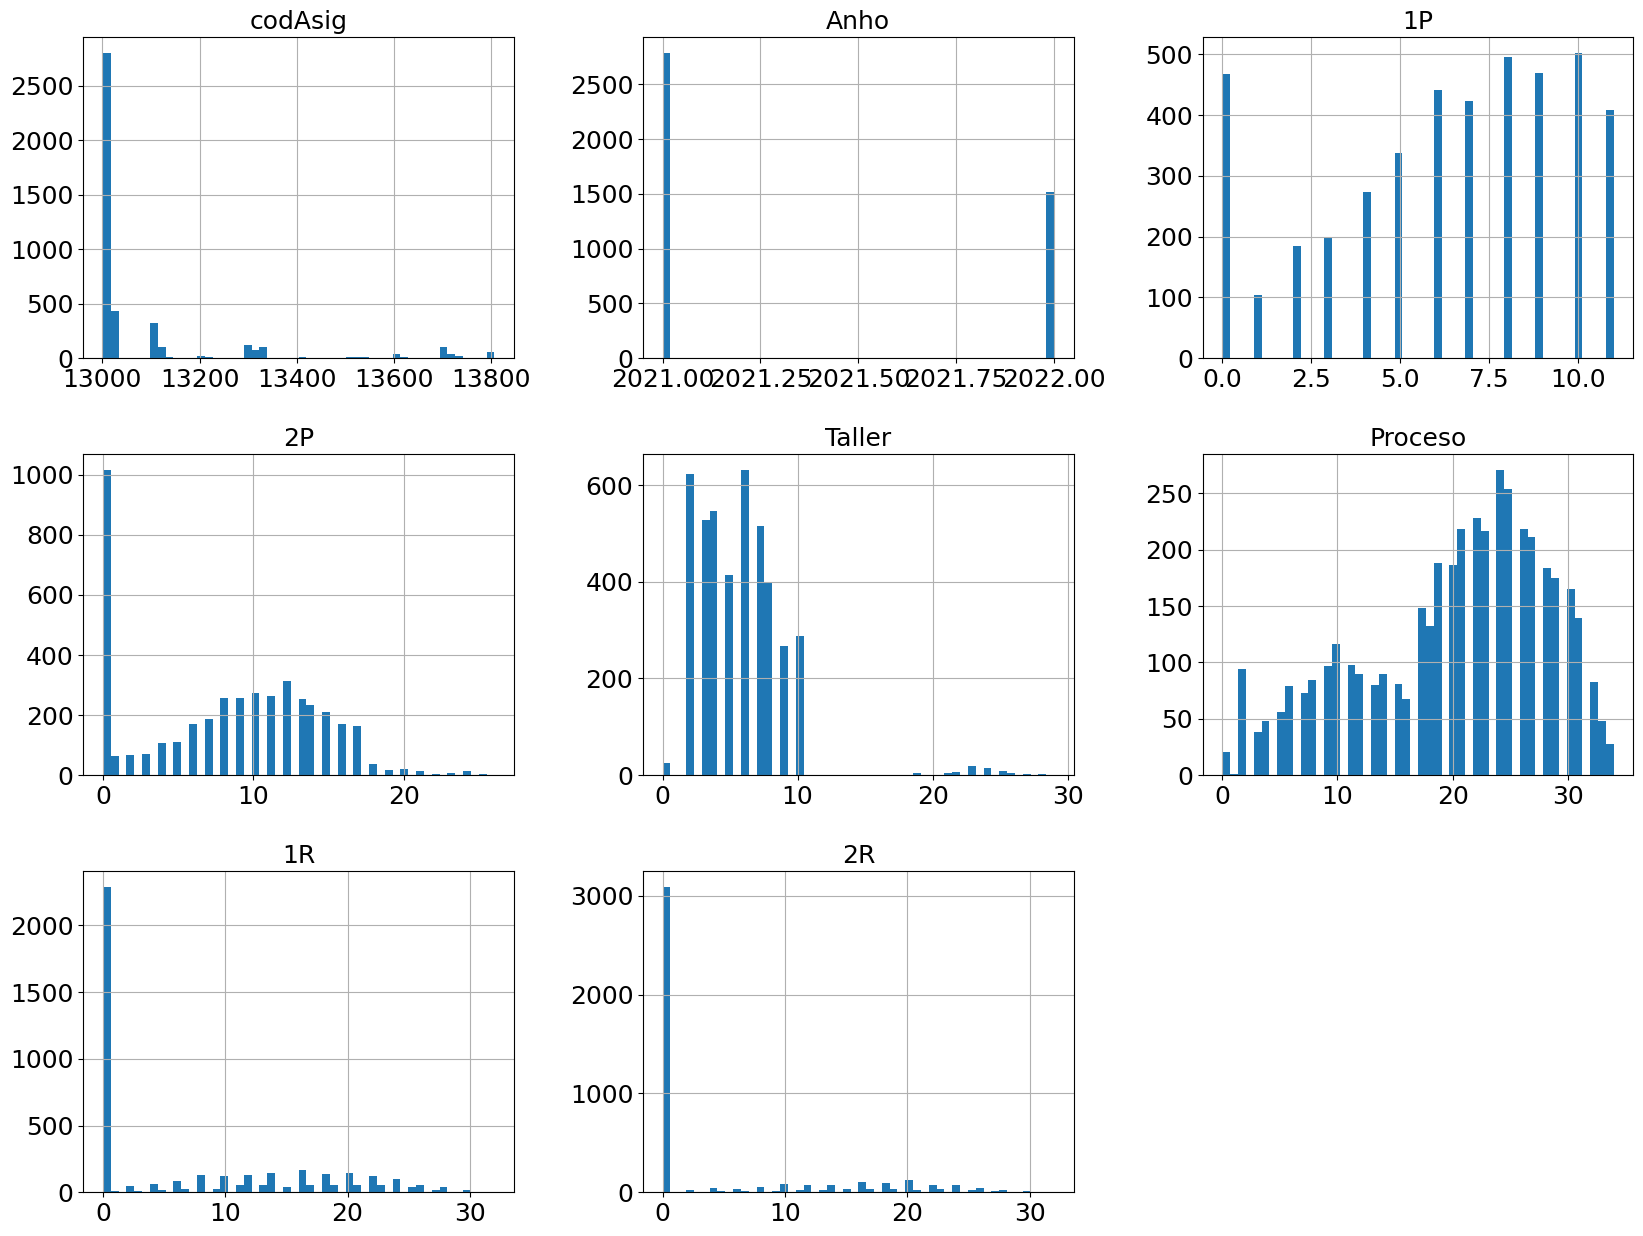

In [32]:
data[['codAsig','CarreraCod','Anho','1P','2P','Taller','Proceso','1R','2R']][grupo].hist(bins=50, figsize=(20,15))
#plt.savefig('hist.png')
plt.show()

In [33]:
data['NFnew']=data.NF.values
final=data[['puntaje1','puntaje2','puntaje3']].max(axis=1)

data['final']=final

data['NF83a']=(data['1P'].values+data['2P'].values+data['Taller'].values)/70*60.+(final/30.)*40.
data['NF83b']=final/30*100
data['NF83c']=(data['1P'].values+data['2P'].values+data['Taller'].values)/70*100
nfnew=(data[['NF83a','NF83b','NF83c']].max(axis=1)/20).astype(int)
flag=nfnew.notna()
data['NFnew'][flag]=nfnew[flag]


C:\Users\yoda\AppData\Local\Temp\ipykernel_5452\3317816976.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['NFnew'][flag]=nfnew[flag]


In [47]:
data[['NF83a','NF83b','NF83c']].head()

,NF83a,NF83b,NF83c
0,76.190476,83.333333,71.428571
1,NaN,NaN,0.000000
2,NaN,NaN,24.285714
3,NaN,NaN,10.000000
4,70.095238,46.666667,85.714286


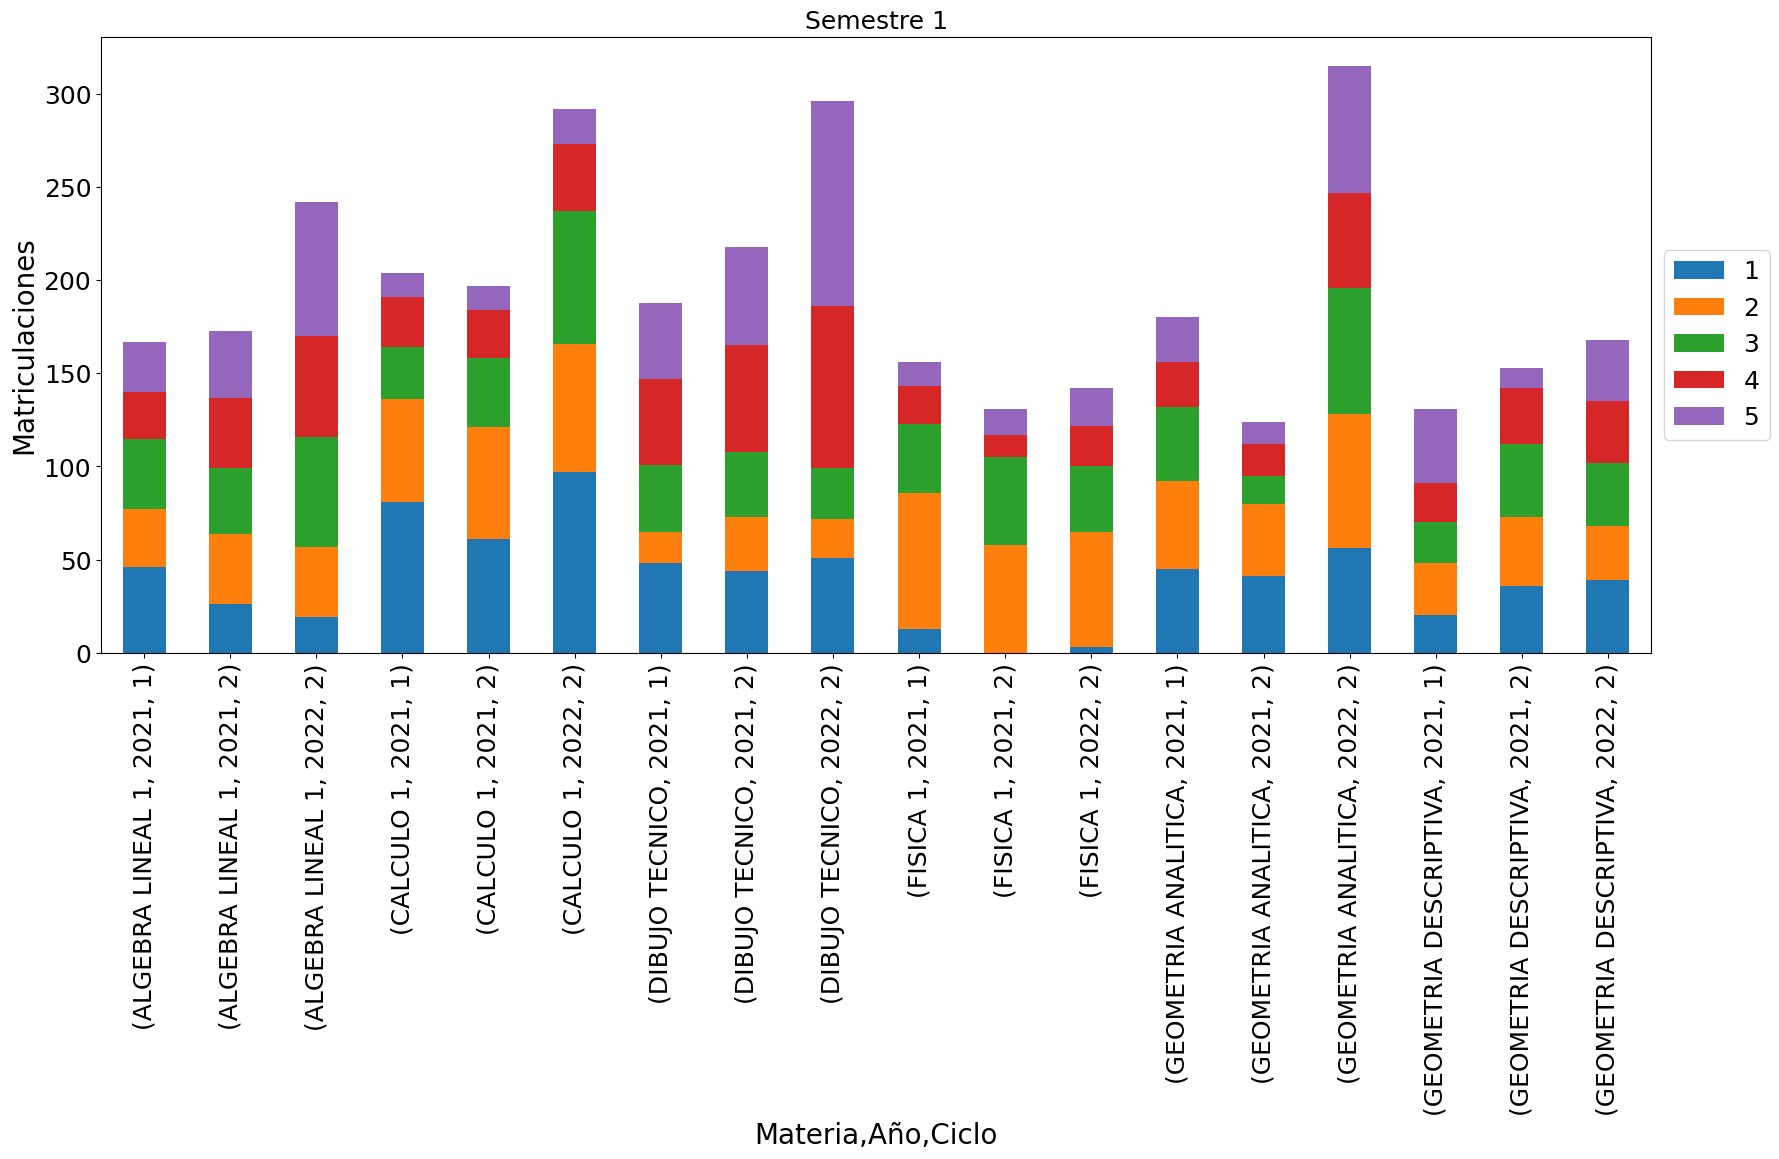

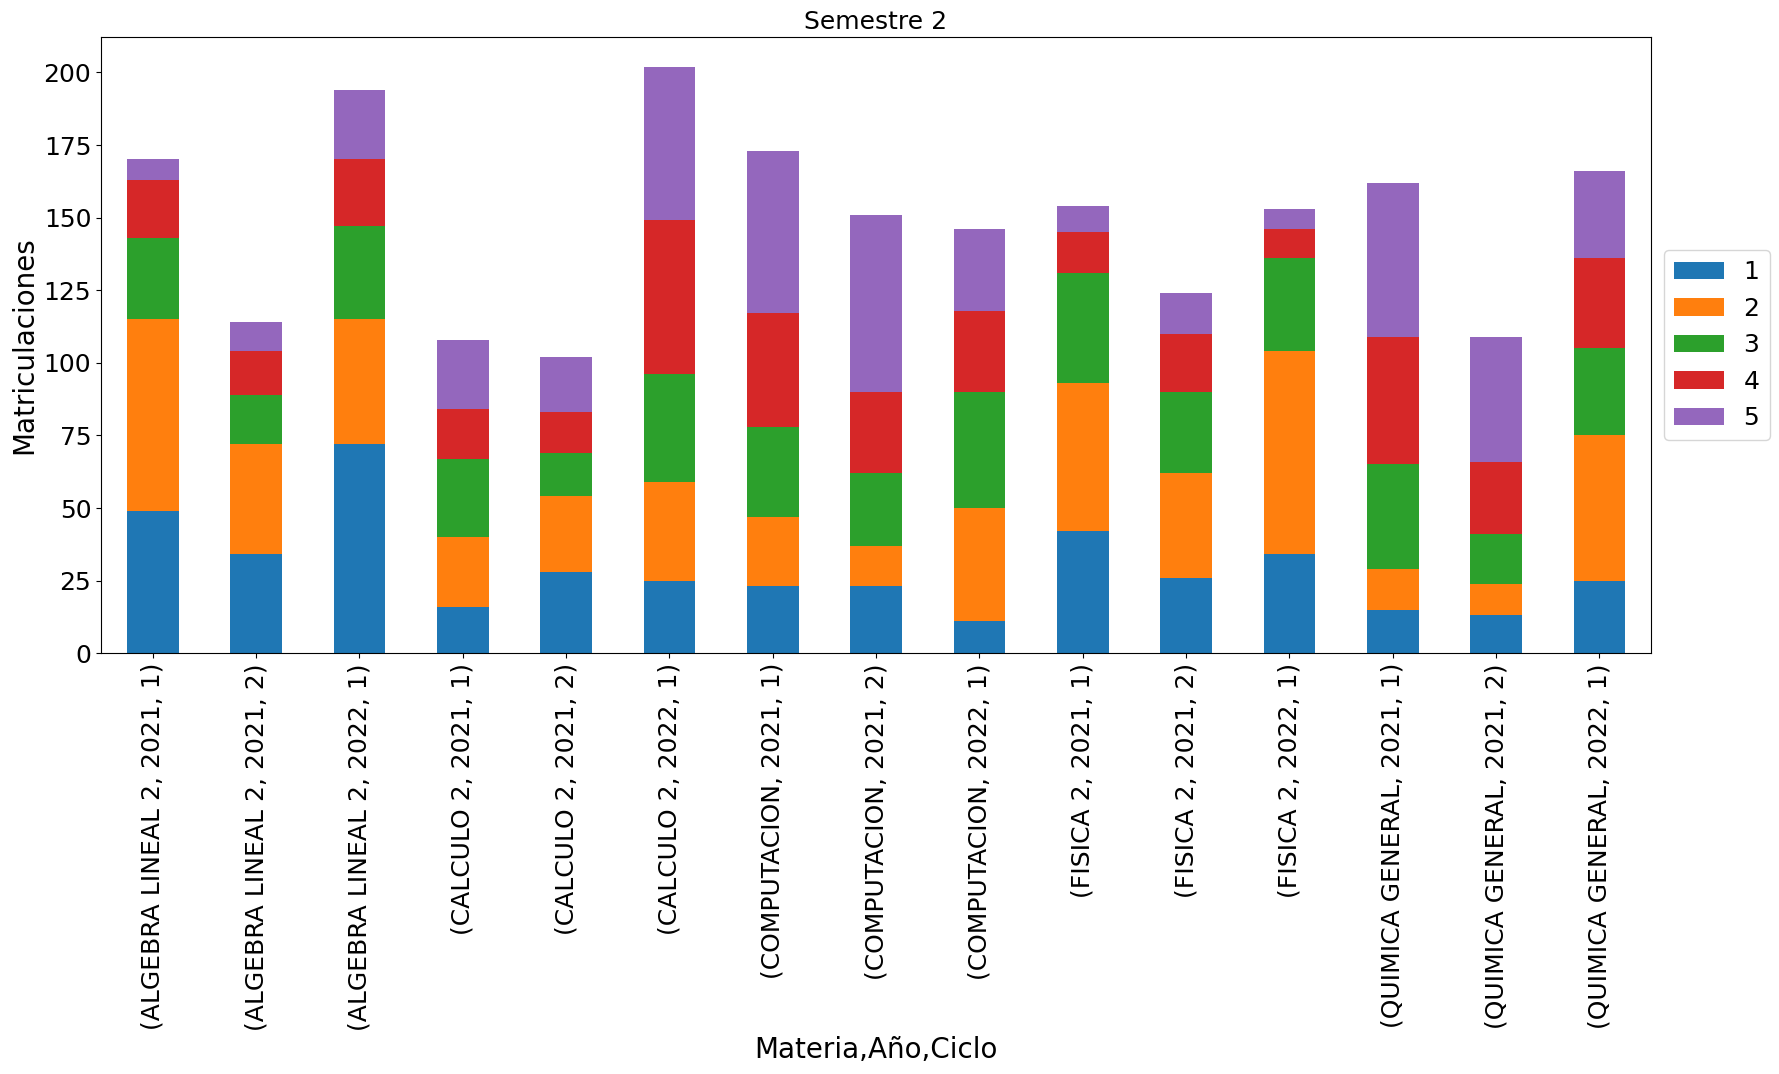

C:\Users\yoda\AppData\Local\Temp\ipykernel_5452\773242047.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df=df[data.Asignatura!=asig]
C:\Users\yoda\AppData\Local\Temp\ipykernel_5452\773242047.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df=df[data.Asignatura!=asig]
C:\Users\yoda\AppData\Local\Temp\ipykernel_5452\773242047.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df=df[np.logical_and(data.Semestre==semestre,data.NF>=1)].groupby(['Asignatura','Anho','ciclo','NF'])['Idalumno'].nunique()


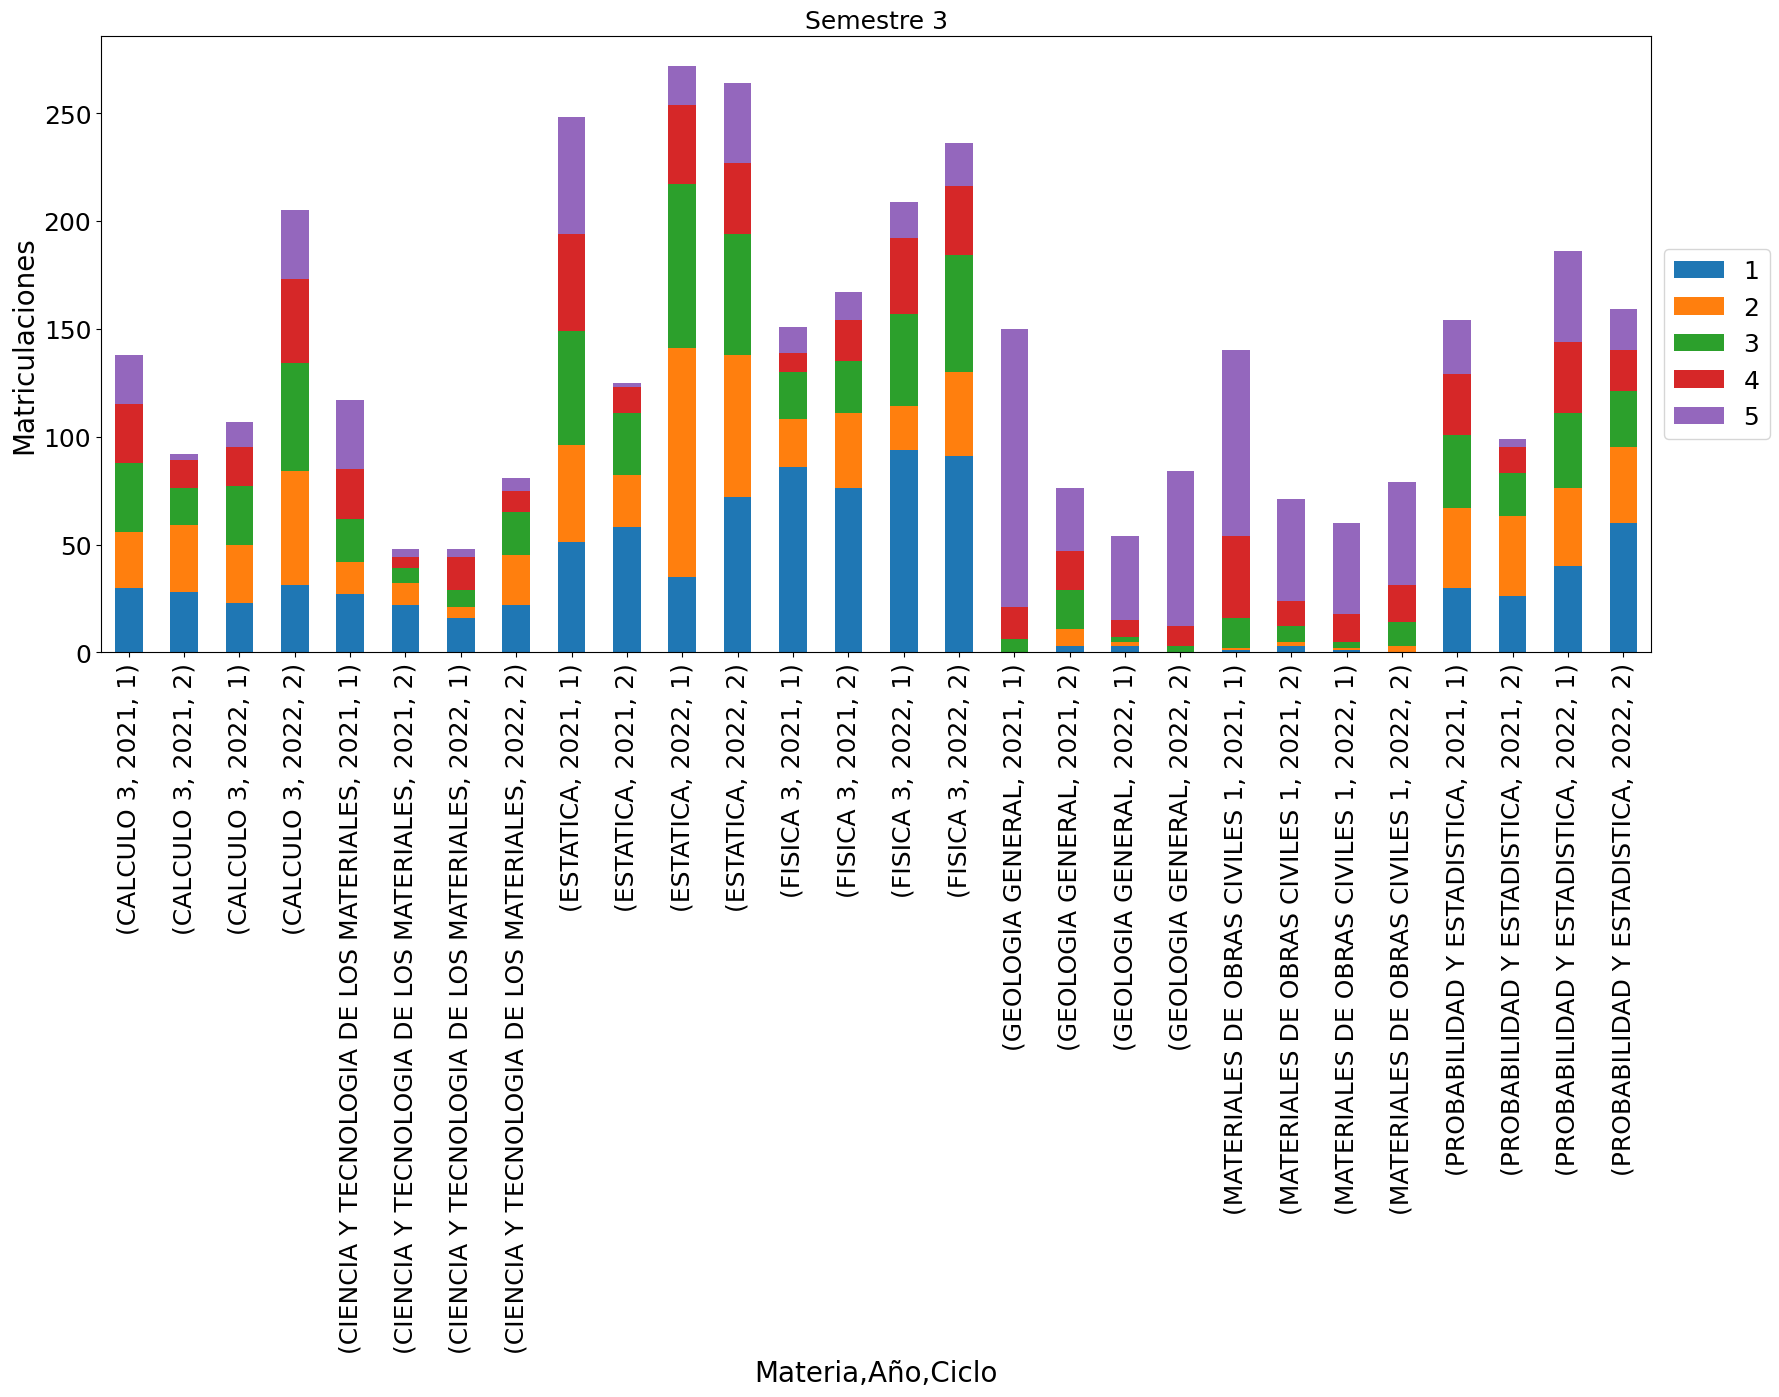

C:\Users\yoda\AppData\Local\Temp\ipykernel_5452\773242047.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df=df[data.Asignatura!=asig]
C:\Users\yoda\AppData\Local\Temp\ipykernel_5452\773242047.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df=df[data.Asignatura!=asig]
C:\Users\yoda\AppData\Local\Temp\ipykernel_5452\773242047.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df=df[data.Asignatura!=asig]
C:\Users\yoda\AppData\Local\Temp\ipykernel_5452\773242047.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df=df[data.Asignatura!=asig]
C:\Users\yoda\AppData\Local\Temp\ipykernel_5452\773242047.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df=df[data.Asignatura!=asig]
C:\Users\yoda\AppData\Local\Temp\ipykernel_5452\773242047.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df=

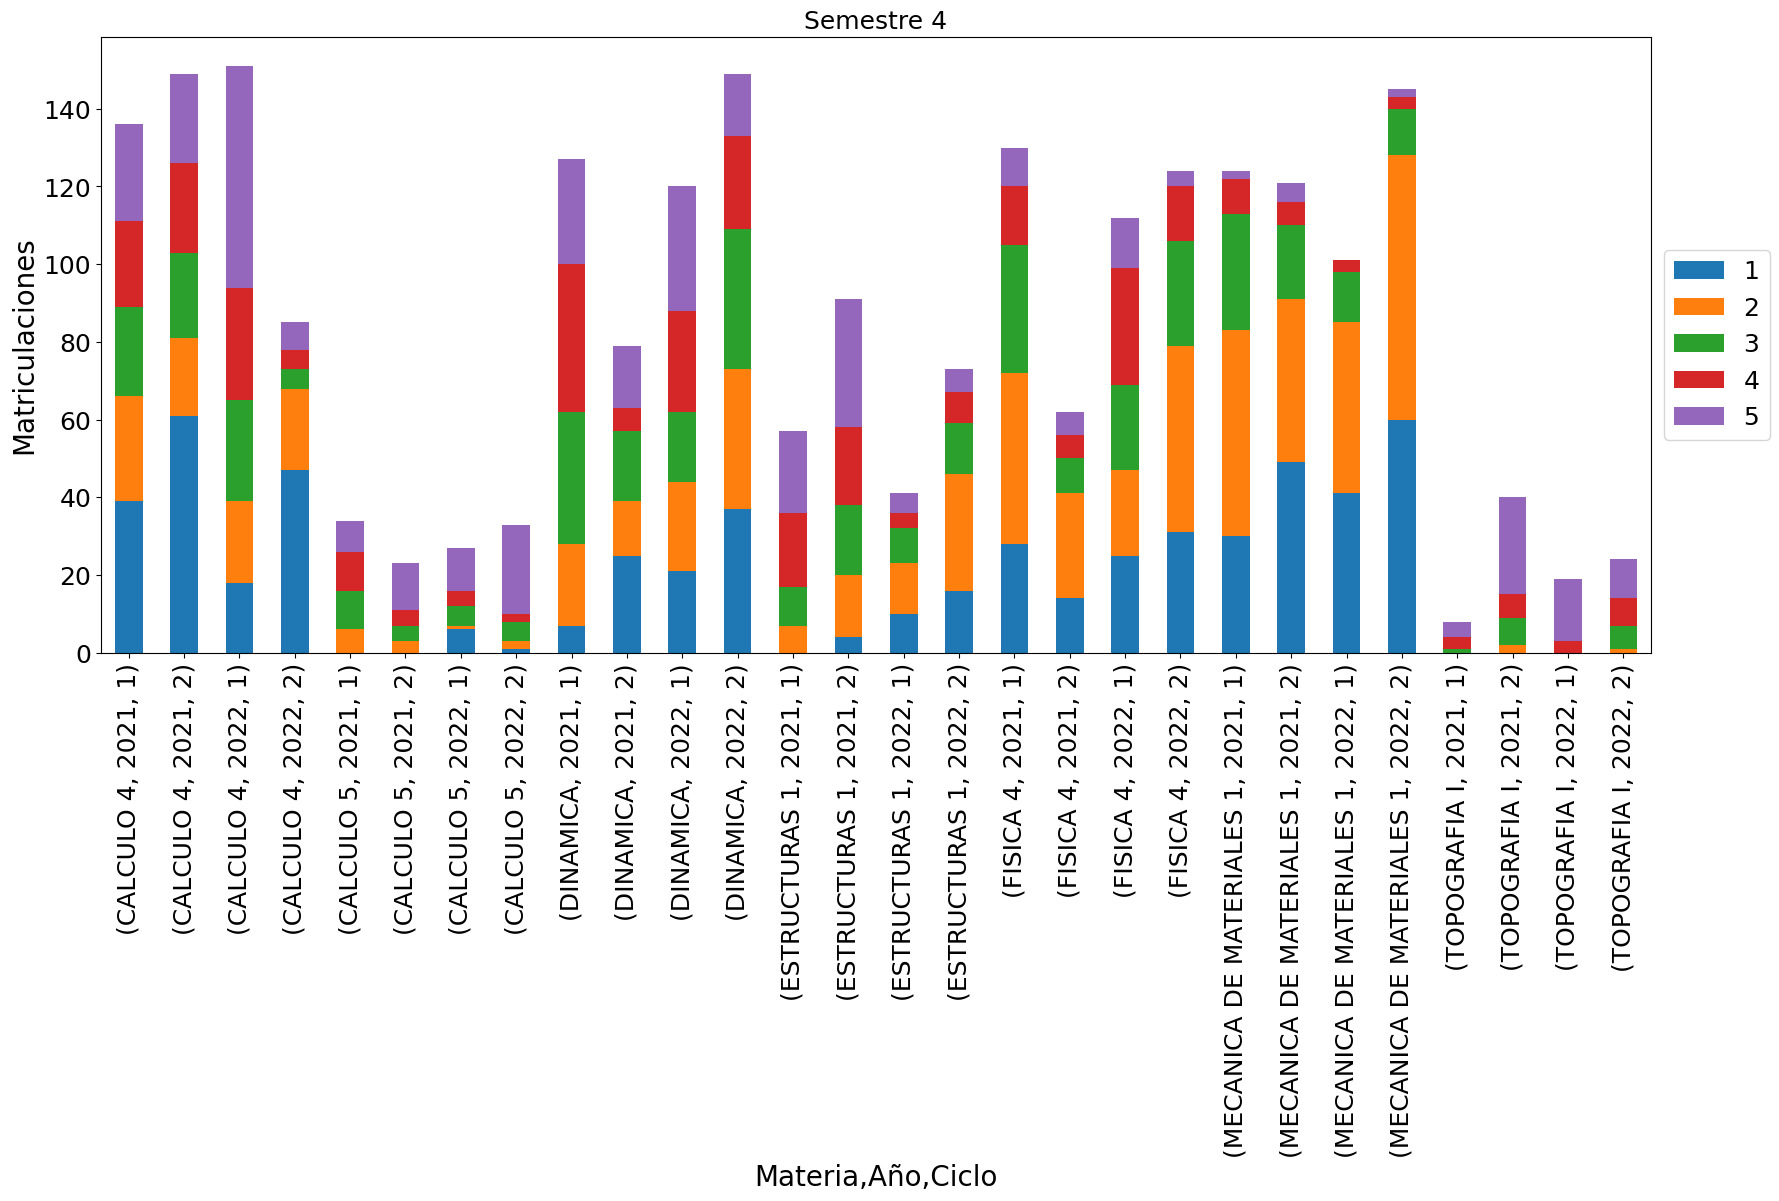

In [34]:
for semestre in [1,2,3,4]:
    dfg=data[data.Semestre==semestre].groupby(['Asignatura'])['Idalumno'].nunique()
    df=data
    for asig in dfg.index[dfg<100].tolist():
        df=df[data.Asignatura!=asig]
    df=df[np.logical_and(data.Semestre==semestre,data.NF>=1)].groupby(['Asignatura','Anho','ciclo','NF'])['Idalumno'].nunique()

   # df=df[df.values>50]
    f, ax = plt.subplots(figsize=(20, 8))
    ax.set_title("Semestre "+str(semestre))

    df.unstack().plot(kind='bar', stacked=True,ax=ax)
  
    #ax.legend(carreras)
    plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))

    #ax.get_legend().remove()
    plt.xlabel("Materia,Año,Ciclo")
    plt.ylabel("Matriculaciones")
    plt.savefig("graficos\GraficoNF"+str(semestre)+".png", bbox_inches="tight")
    plt.show()

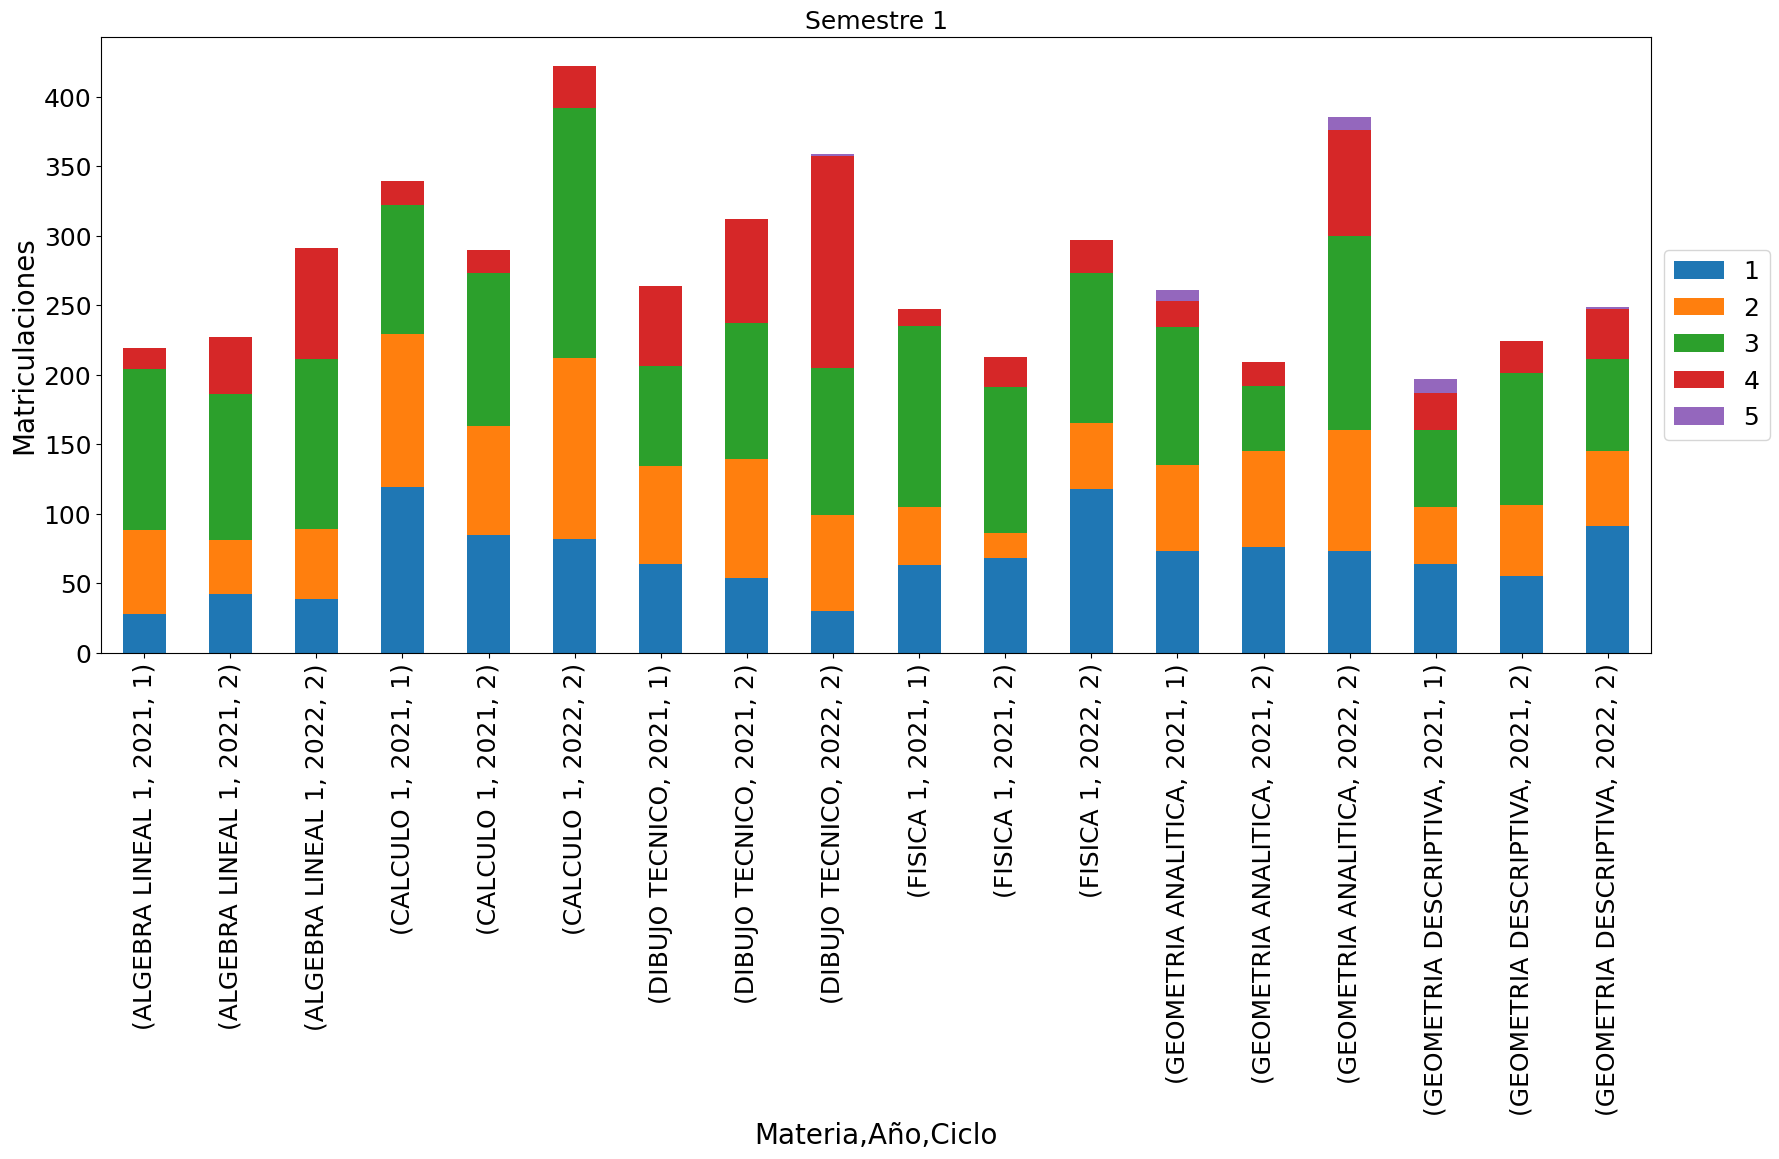

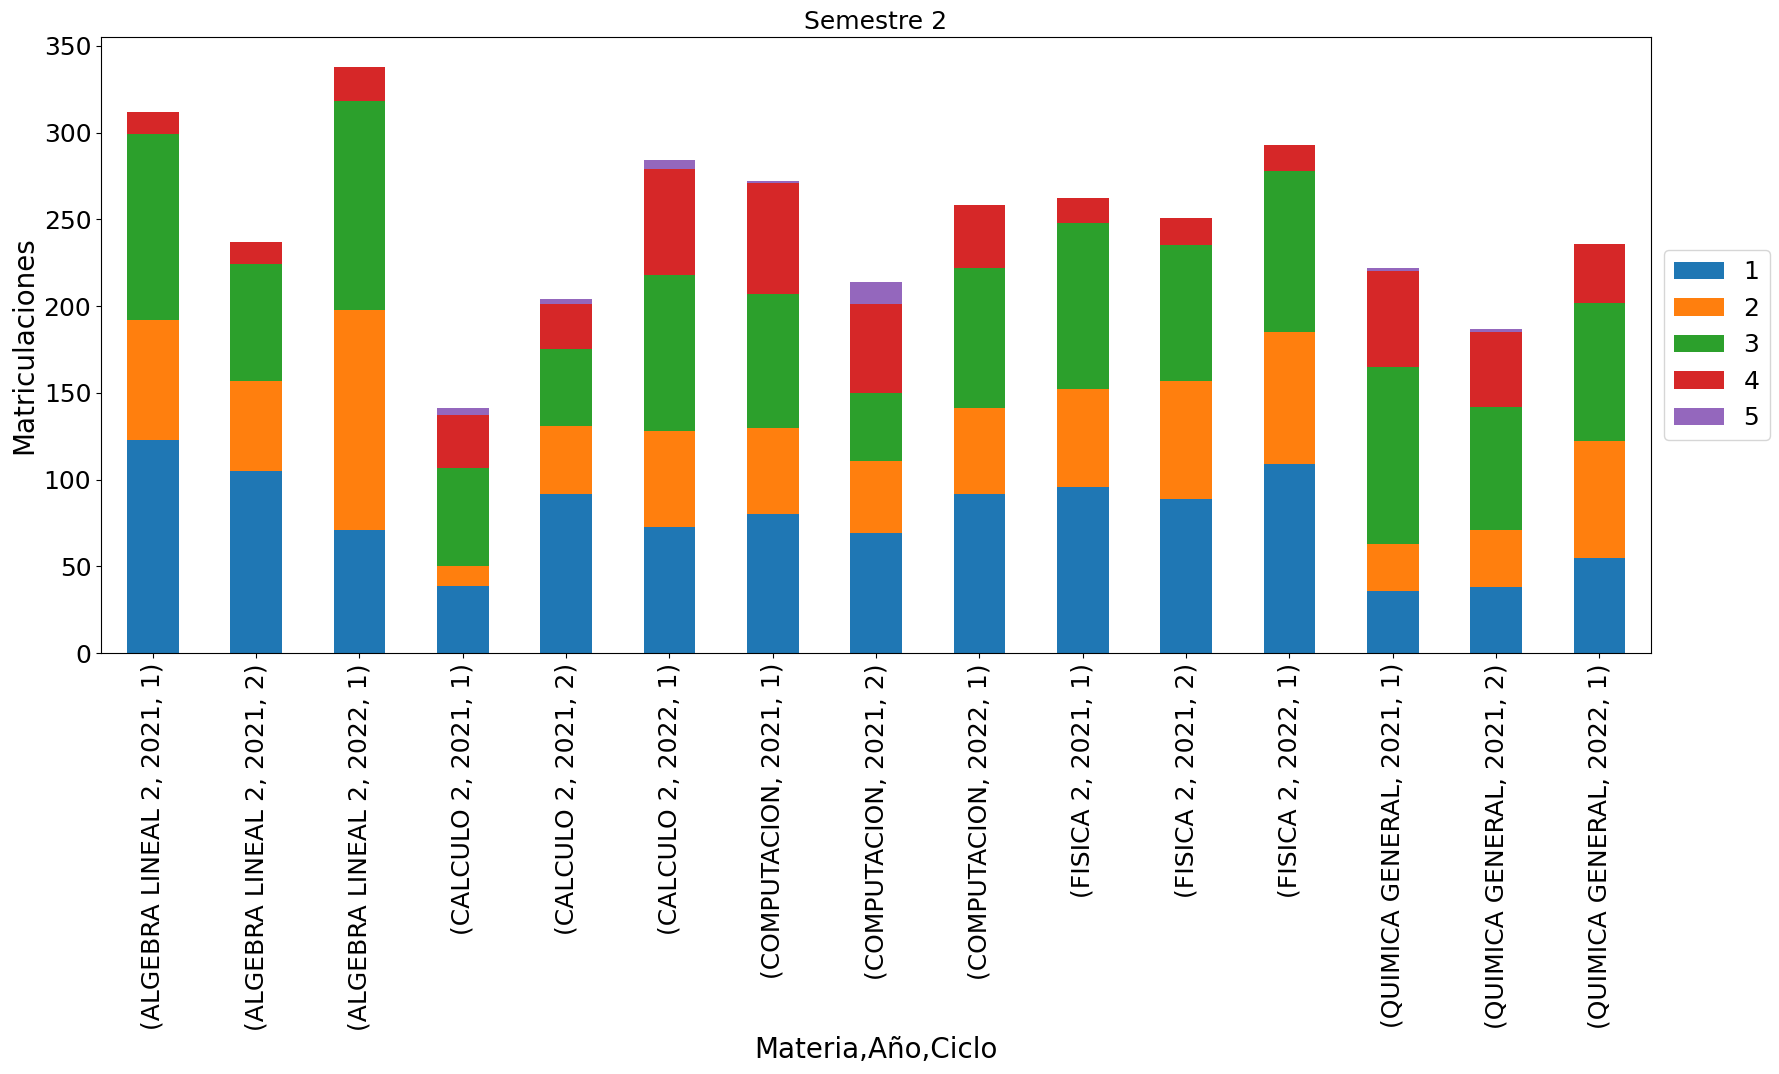

C:\Users\yoda\AppData\Local\Temp\ipykernel_5452\1330245867.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df=df[data.Asignatura!=asig]
C:\Users\yoda\AppData\Local\Temp\ipykernel_5452\1330245867.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df=df[data.Asignatura!=asig]
C:\Users\yoda\AppData\Local\Temp\ipykernel_5452\1330245867.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df=df[np.logical_and(data.Semestre==semestre,data.NFnew>=1)].groupby(['Asignatura','Anho','ciclo','NFnew'])['Idalumno'].nunique()


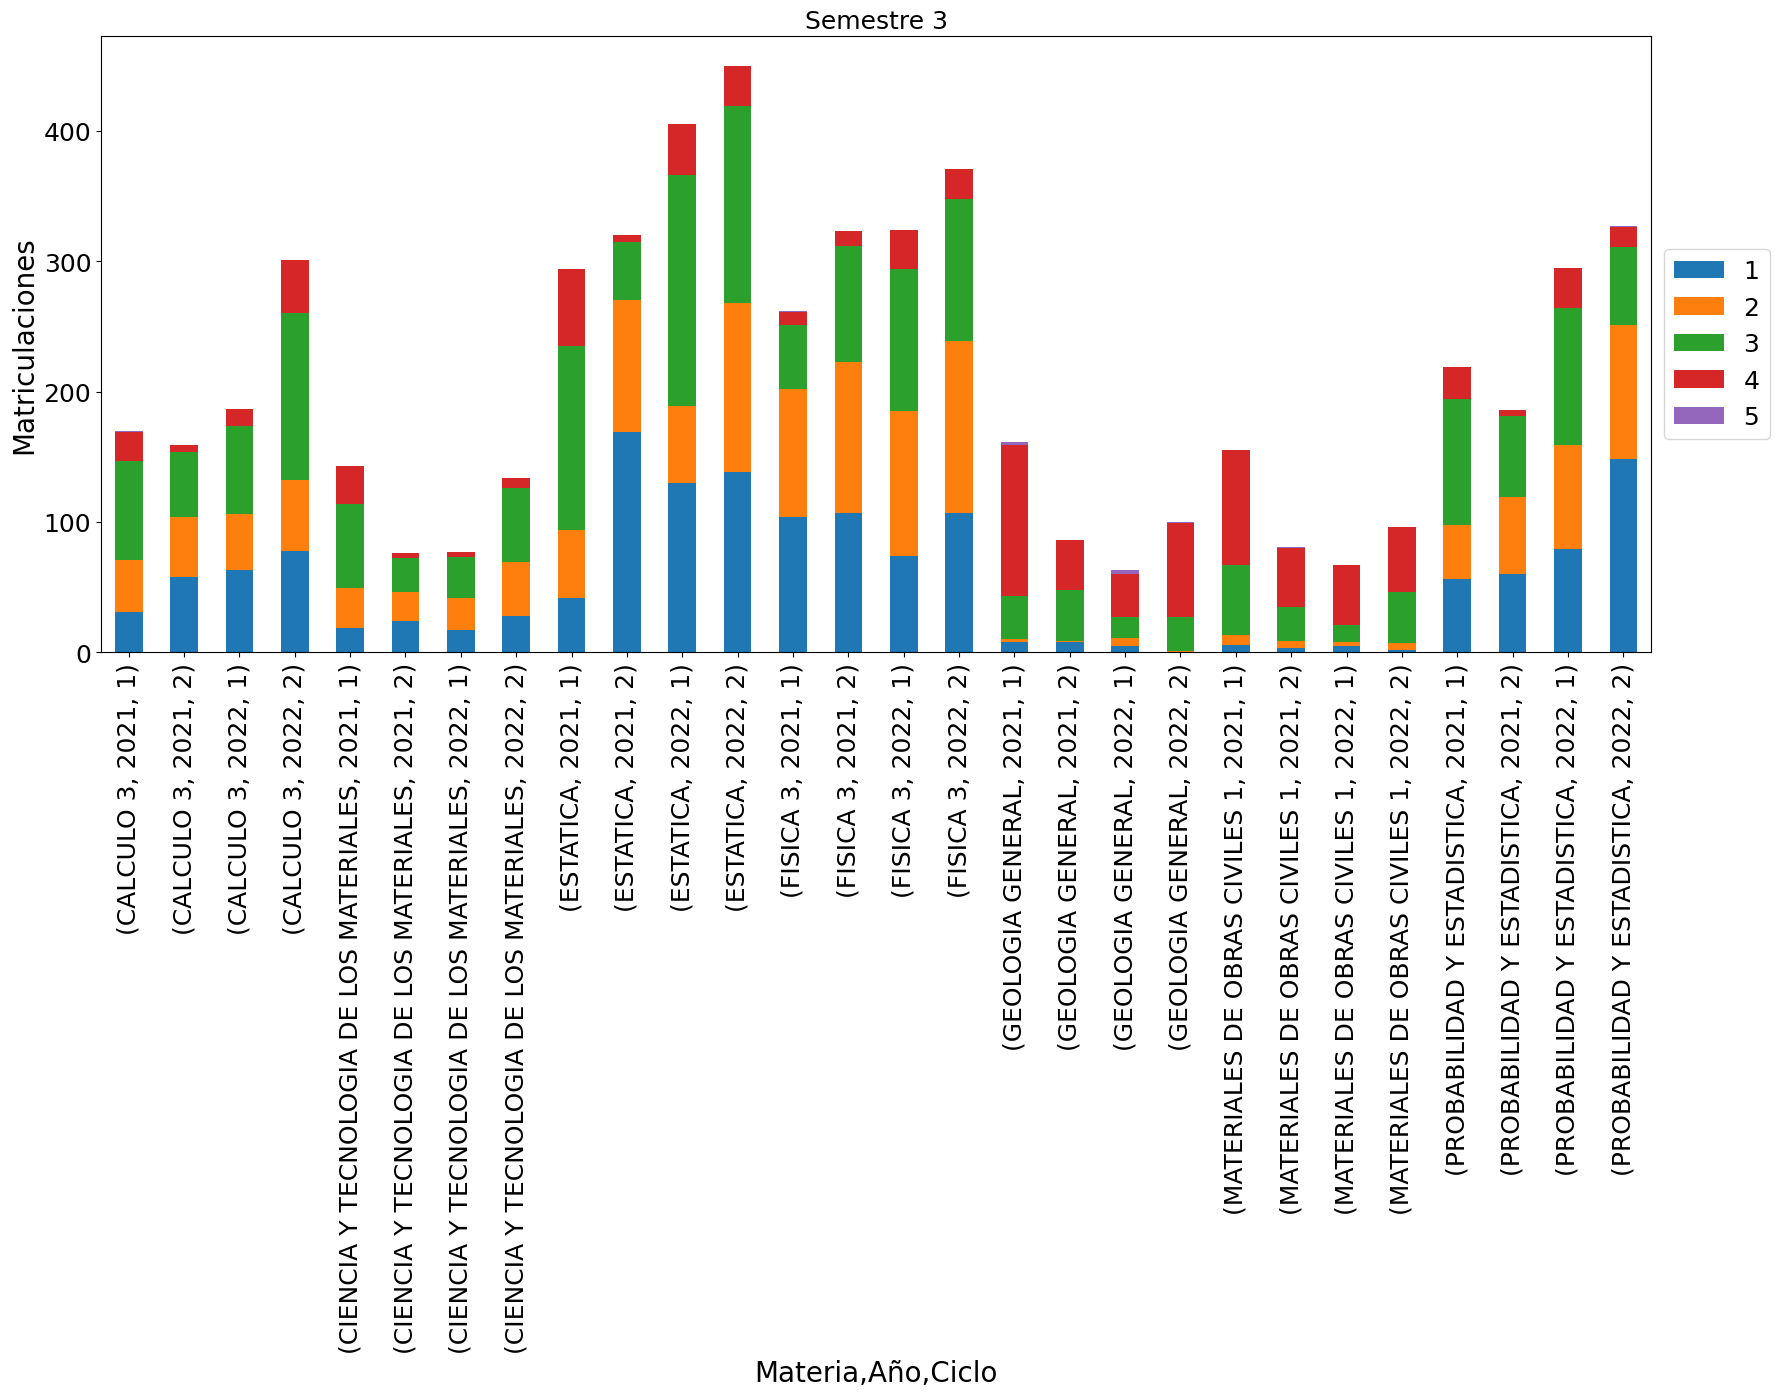

C:\Users\yoda\AppData\Local\Temp\ipykernel_5452\1330245867.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df=df[data.Asignatura!=asig]
C:\Users\yoda\AppData\Local\Temp\ipykernel_5452\1330245867.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df=df[data.Asignatura!=asig]
C:\Users\yoda\AppData\Local\Temp\ipykernel_5452\1330245867.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df=df[data.Asignatura!=asig]
C:\Users\yoda\AppData\Local\Temp\ipykernel_5452\1330245867.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df=df[data.Asignatura!=asig]
C:\Users\yoda\AppData\Local\Temp\ipykernel_5452\1330245867.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df=df[data.Asignatura!=asig]
C:\Users\yoda\AppData\Local\Temp\ipykernel_5452\1330245867.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.

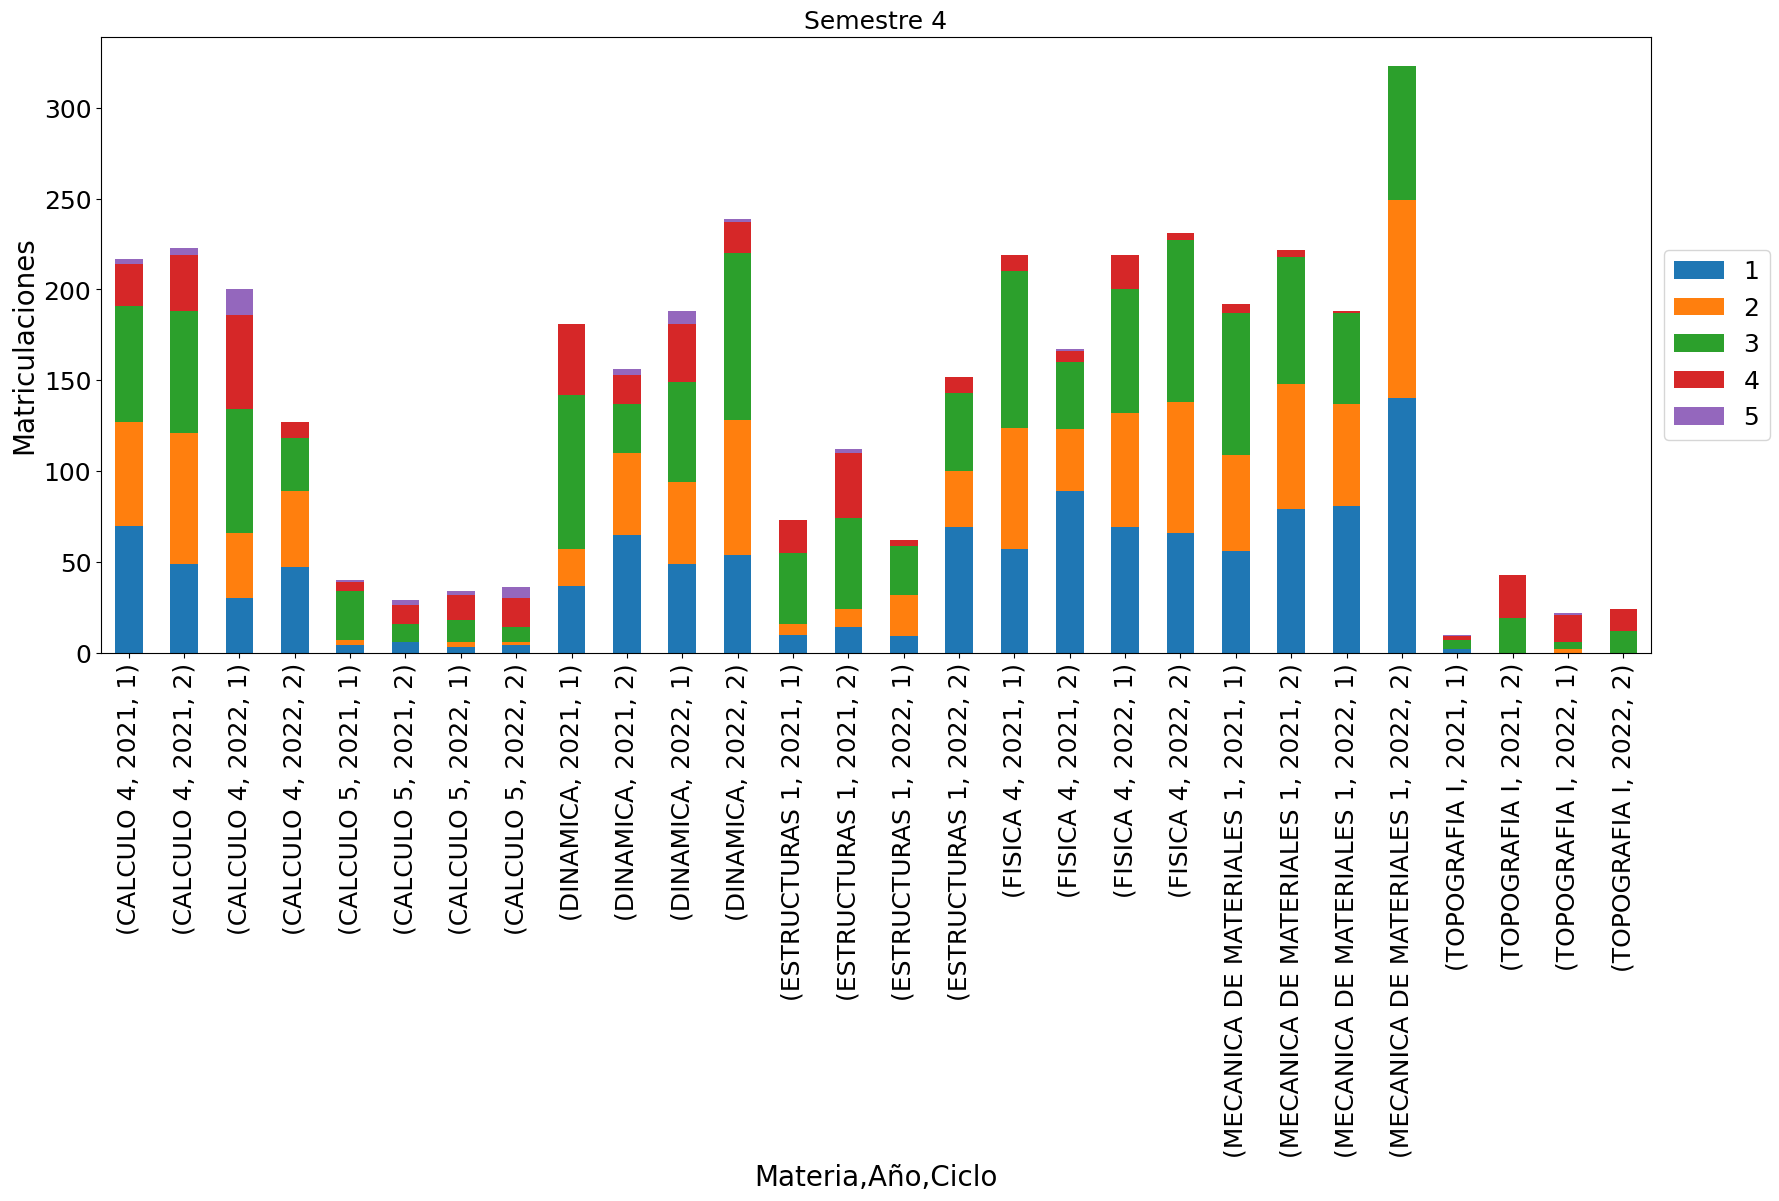

In [48]:
for semestre in [1,2,3,4]:
    dfg=data[data.Semestre==semestre].groupby(['Asignatura'])['Idalumno'].nunique()
    df=data
    for asig in dfg.index[dfg<100].tolist():
        df=df[data.Asignatura!=asig]
    df=df[np.logical_and(data.Semestre==semestre,data.NFnew>=1)].groupby(['Asignatura','Anho','ciclo','NFnew'])['Idalumno'].nunique()

   # df=df[df.values>50]
    f, ax = plt.subplots(figsize=(20, 8))
    ax.set_title("Semestre "+str(semestre))

    df.unstack().plot(kind='bar', stacked=True,ax=ax)
  
    #ax.legend(carreras)
    plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))

    #ax.get_legend().remove()
    plt.xlabel("Materia,Año,Ciclo")
    plt.ylabel("Matriculaciones")
    plt.savefig("graficos\GraficoNF"+str(semestre)+".png", bbox_inches="tight")
    plt.show()

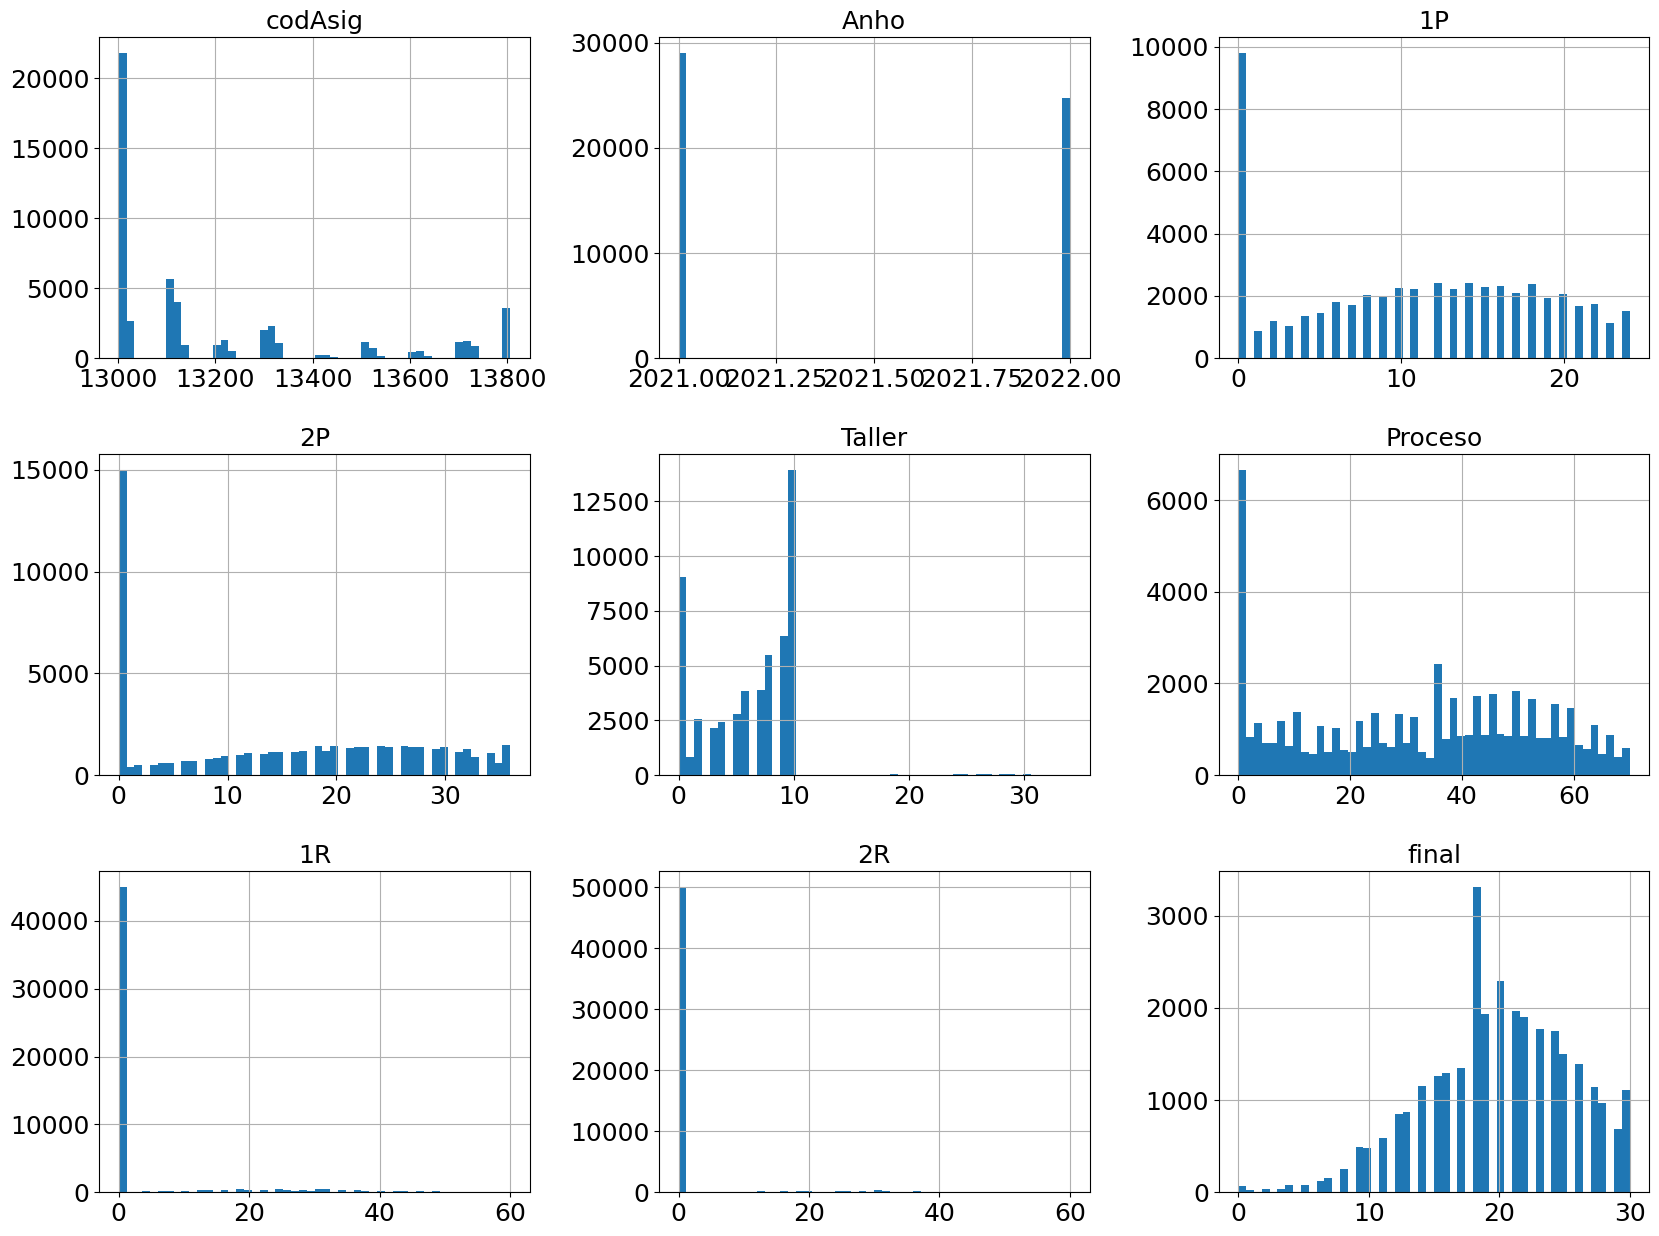

In [36]:
data[['codAsig','CarreraCod','Anho','1P','2P','Taller','Proceso','1R','2R','final']].hist(bins=50, figsize=(20,15))
#plt.savefig('hist.png')
plt.show()

In [37]:
from scipy import stats

6
3
0
0
Semestre 1 Asignatura FISICA 1
0
1
Semestre 1 Asignatura DIBUJO TECNICO
0
2
Semestre 1 Asignatura CALCULO 1
1
0
Semestre 1 Asignatura ALGEBRA LINEAL 1
1
1
Semestre 1 Asignatura GEOMETRIA DESCRIPTIVA
1
2
Semestre 1 Asignatura GEOMETRIA ANALITICA
6


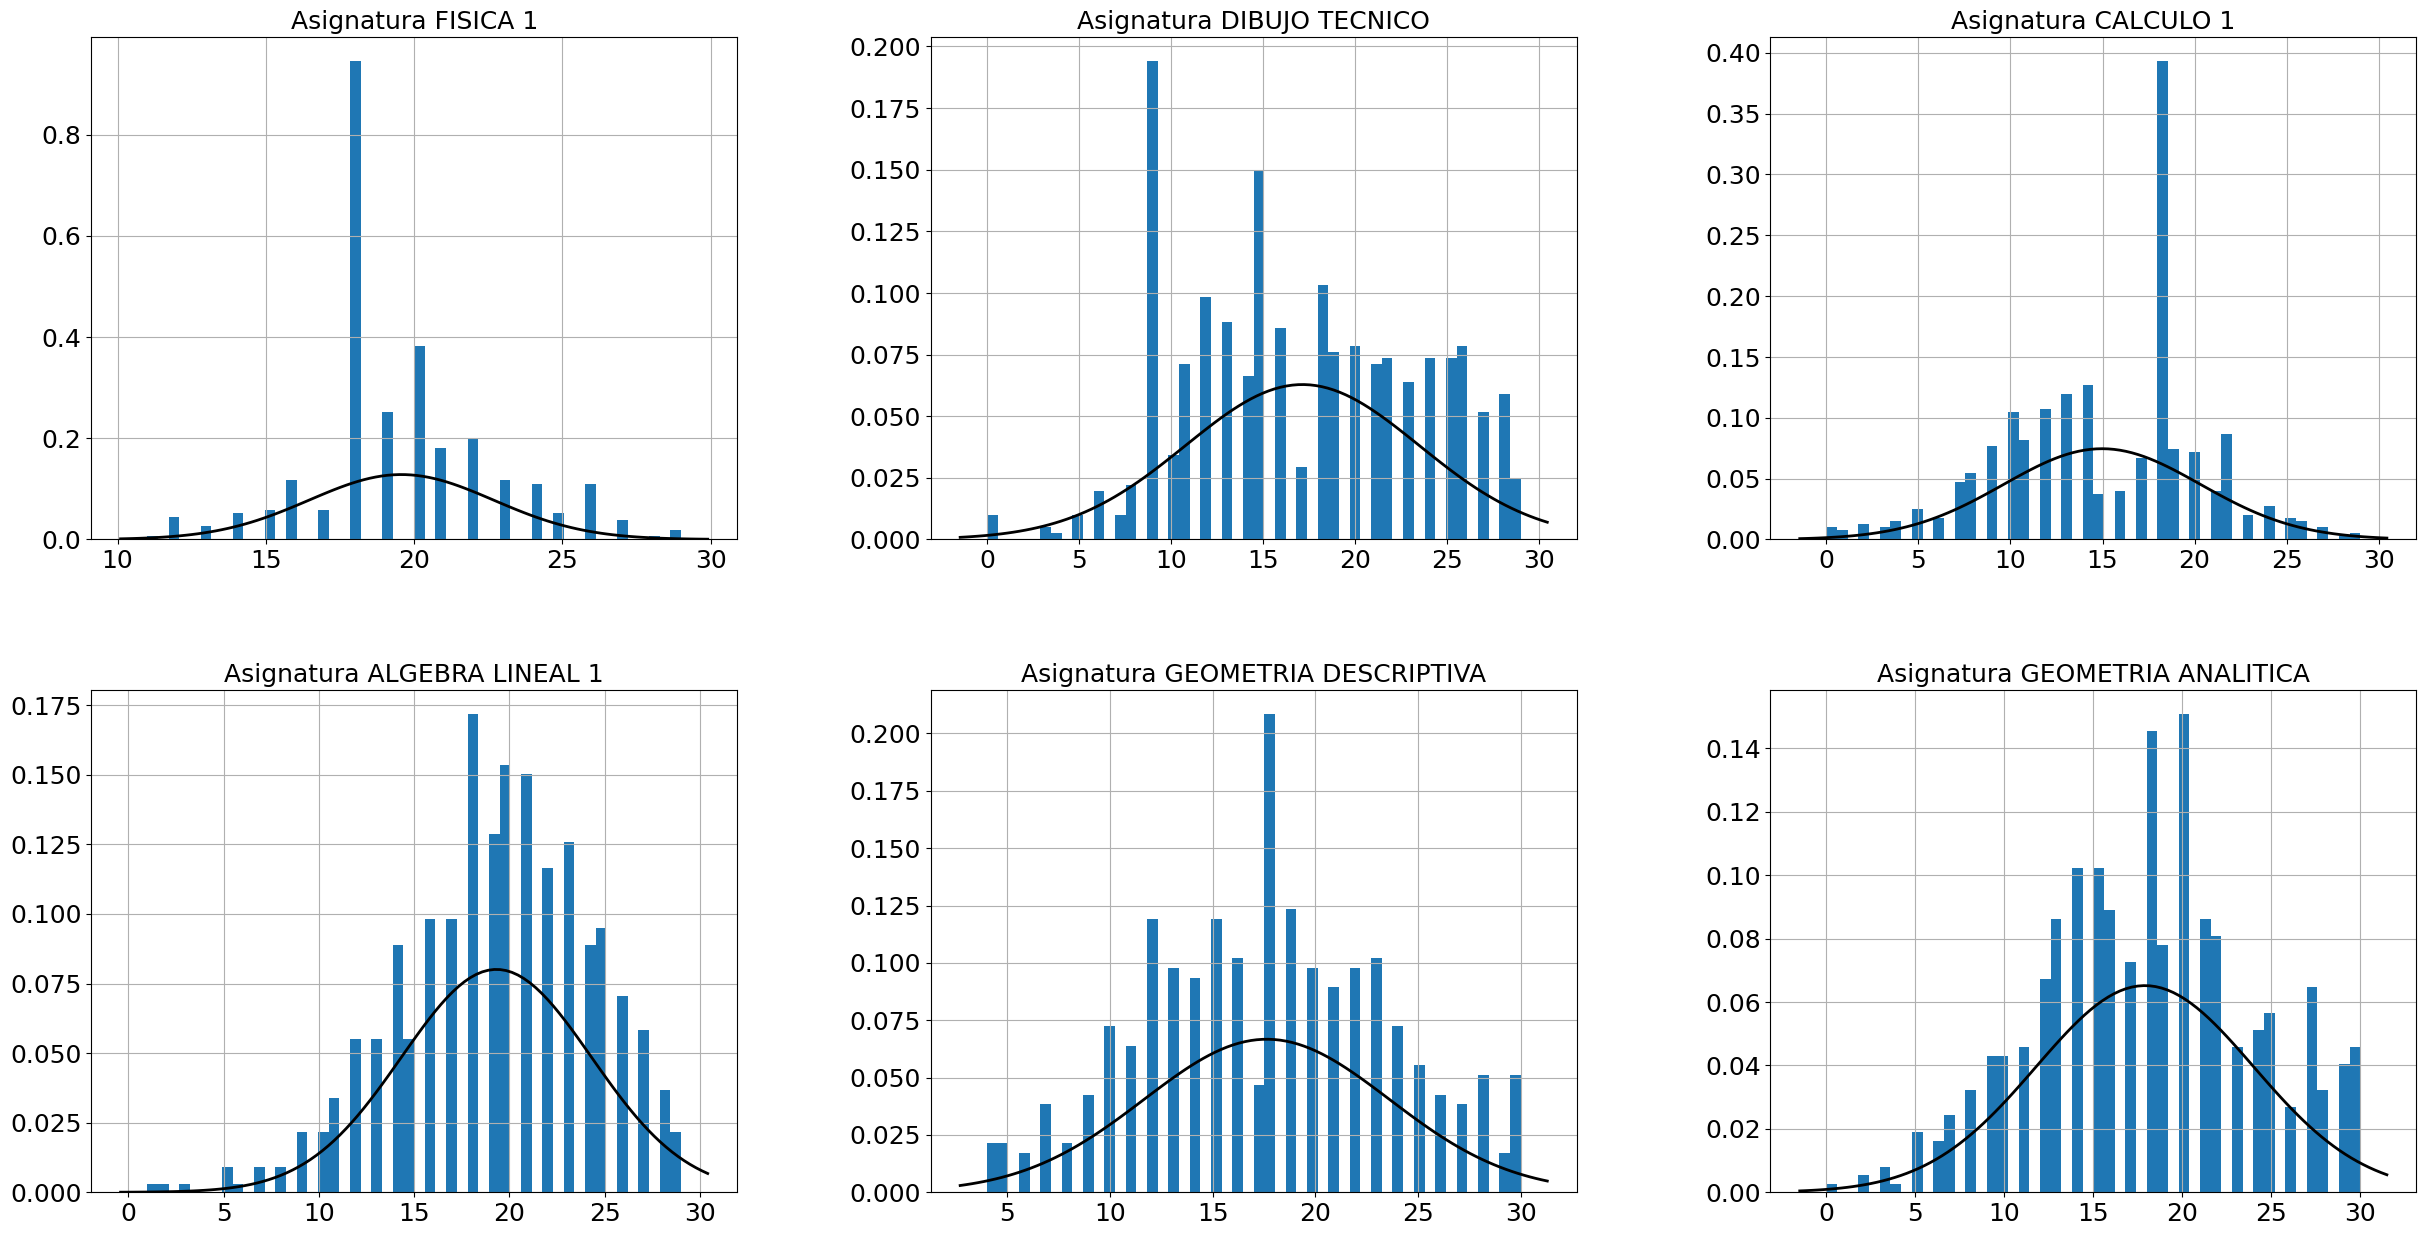

5
2
0
0
Semestre 2 Asignatura CALCULO 2
0
1
Semestre 2 Asignatura COMPUTACION
0
2
Semestre 2 Asignatura FISICA 2
1
0
Semestre 2 Asignatura ALGEBRA LINEAL 2
1
1
Semestre 2 Asignatura QUIMICA GENERAL
5
1
2


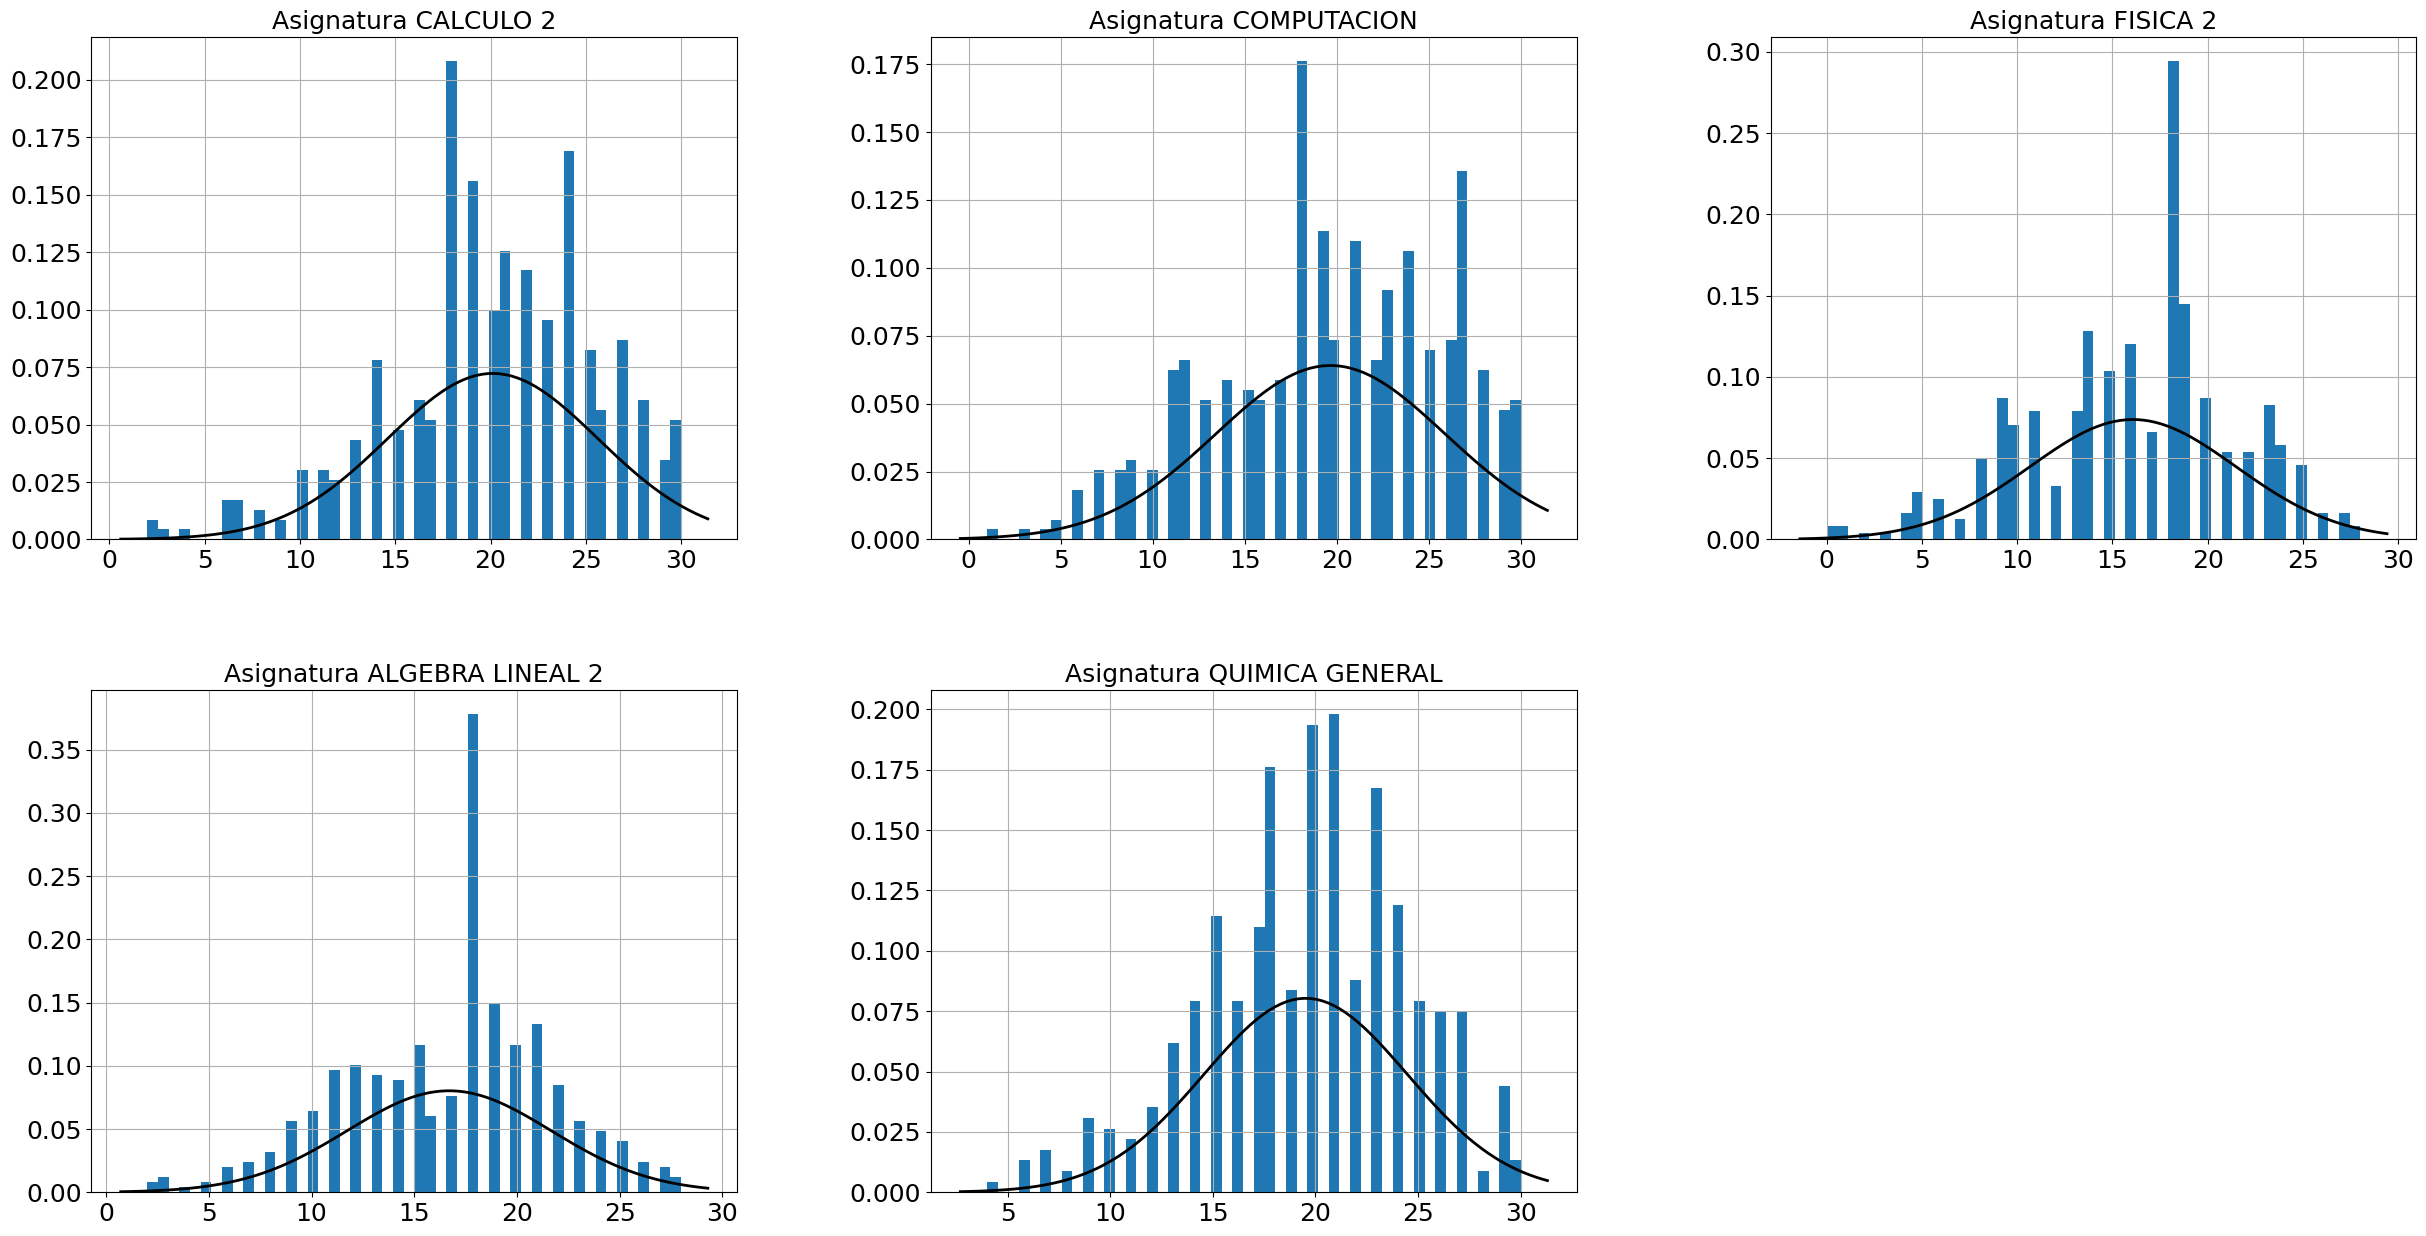

10
4
0
0
Semestre 3 Asignatura ESTATICA
0
1
Semestre 3 Asignatura CIENCIA Y TECNOLOGIA DE LOS MATERIALES
0
2
Semestre 3 Asignatura FISICA GRAVIMETRICA
1
0
Semestre 3 Asignatura PROBABILIDAD Y ESTADISTICA
1
1
Semestre 3 Asignatura CALCULO 3
1
2
Semestre 3 Asignatura MATERIALES DE OBRAS CIVILES 1
2
0
Semestre 3 Asignatura GEOLOGIA GENERAL
2
1
Semestre 3 Asignatura FISICA 3
2
2
Semestre 3 Asignatura ELECTROMAGNETISMO 1
3
0
Semestre 3 Asignatura SISTEMA DE REDES 1
10
3
1
3
2


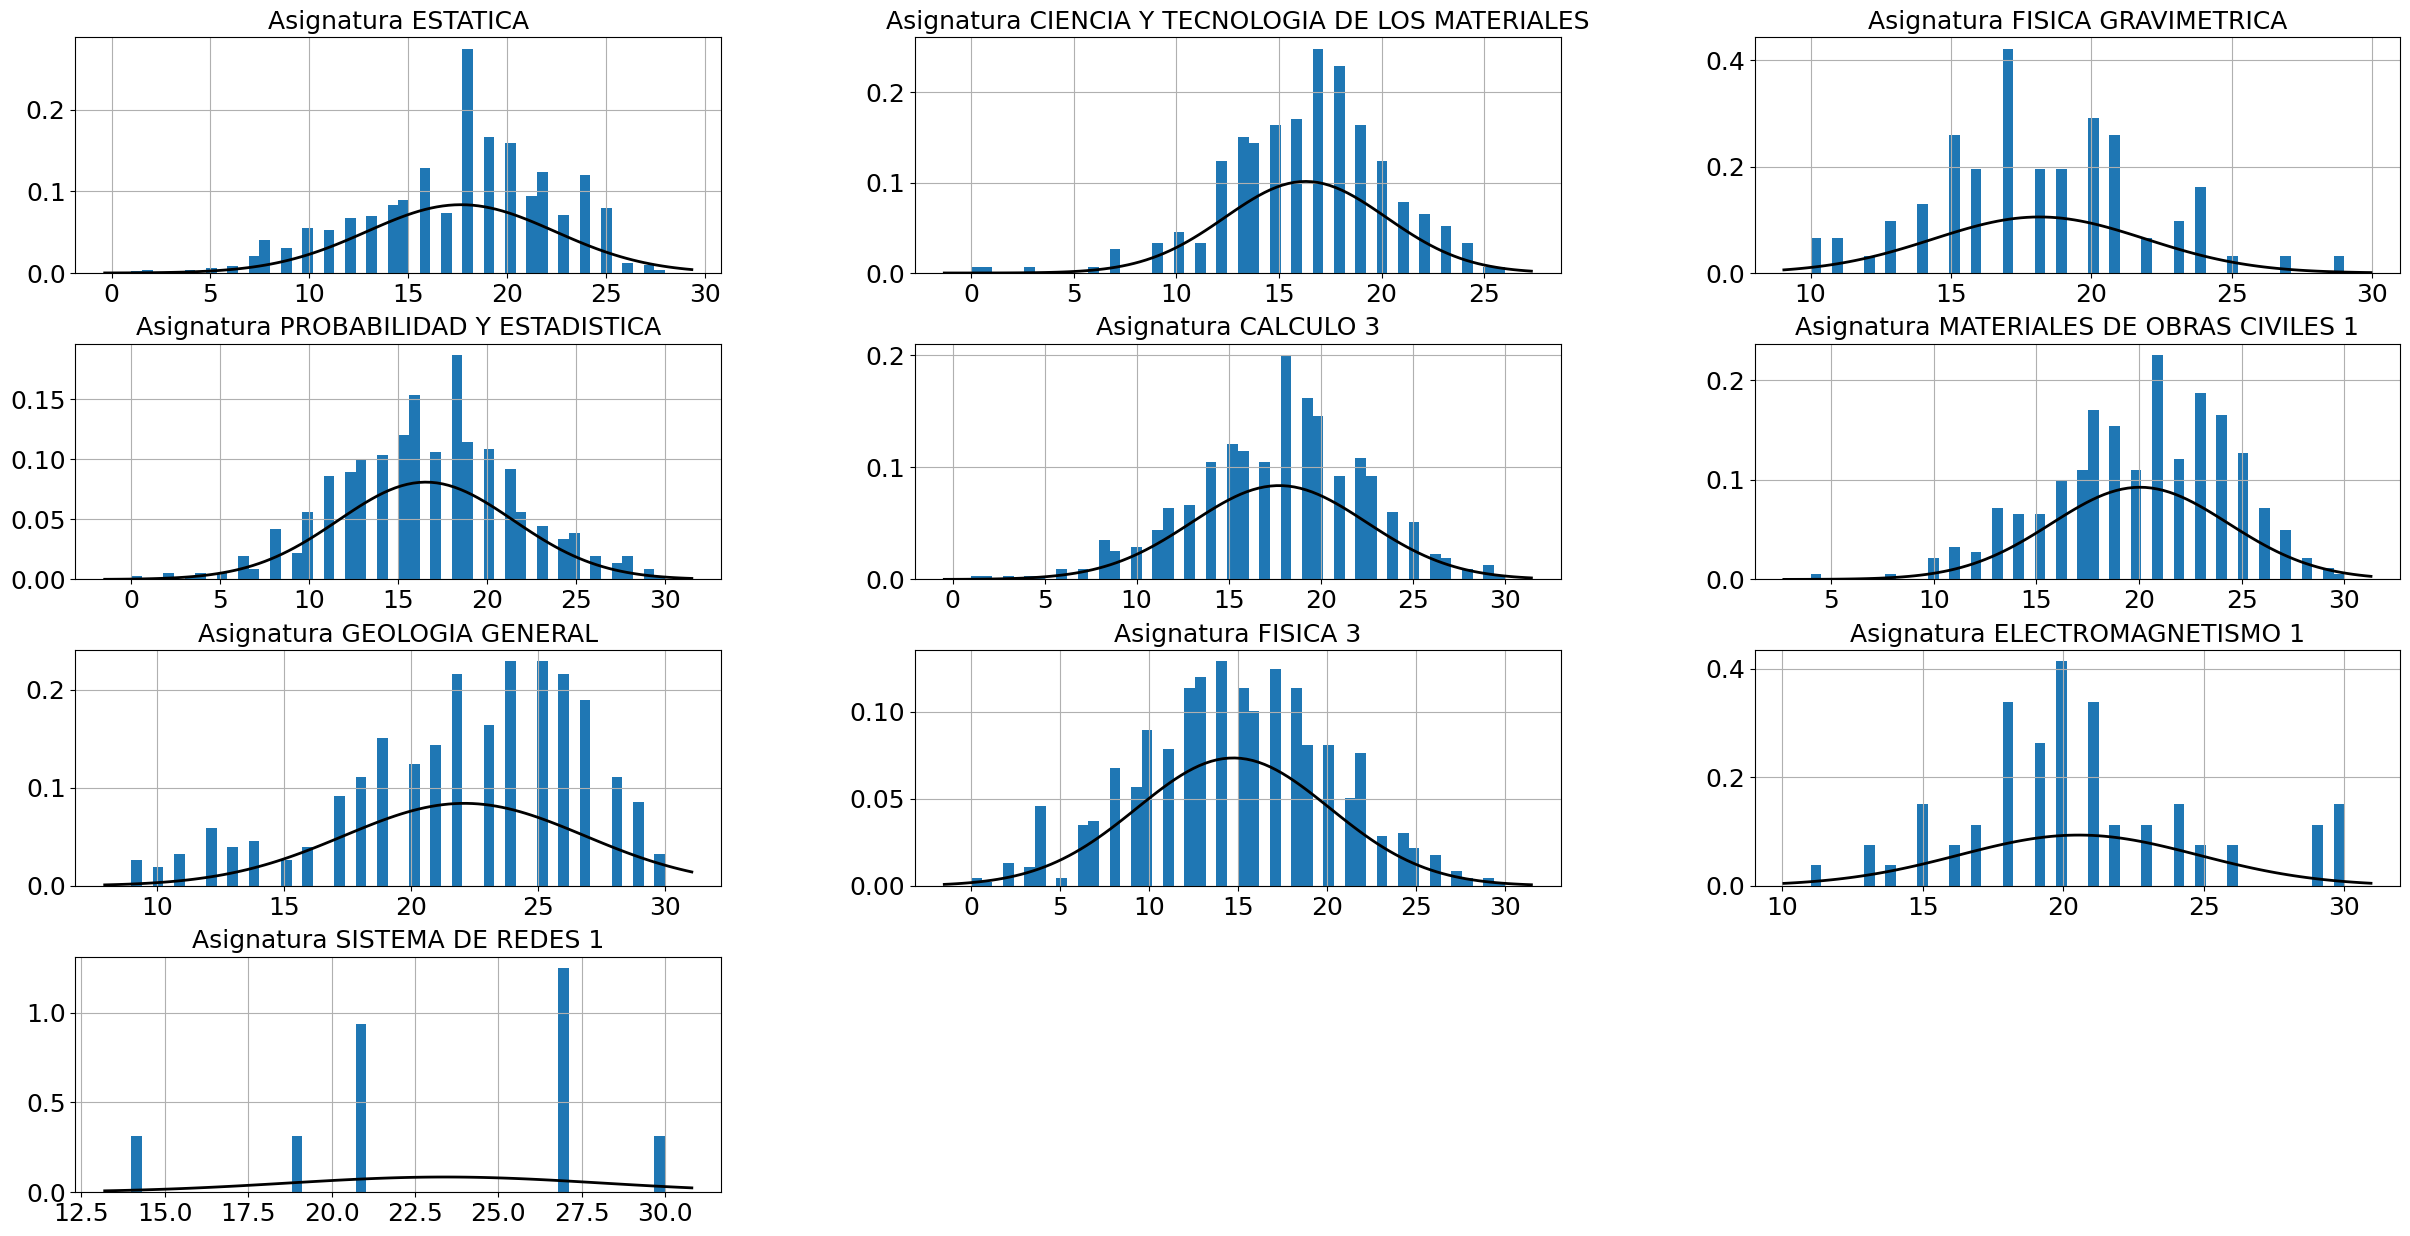

17
6
0
0
Semestre 4 Asignatura FISICA DE SEMICONDUCTORES
0
1
Semestre 4 Asignatura CALCULO 5
0
2
Semestre 4 Asignatura CALCULO 4
1
0
Semestre 4 Asignatura FISICA 4
1
1
Semestre 4 Asignatura FOTOGRAMETRIA I
1
2
Semestre 4 Asignatura GEOLOGIA DEL PARAGUAY
2
0
Semestre 4 Asignatura MECANICA DE MATERIALES 1
2
1
Semestre 4 Asignatura TOPOGRAFIA I
2
2
Semestre 4 Asignatura DINAMICA
3
0
Semestre 4 Asignatura ESTRUCTURAS 1
3
1
Semestre 4 Asignatura CIENCIAS SOCIALES
3
2
Semestre 4 Asignatura TEORIA DE CIRCUITOS
4
0
Semestre 4 Asignatura METODOS NUMERICOS
4
1
Semestre 4 Asignatura PROGRAMACION ORIENTADA A OBJETOS
4
2
Semestre 4 Asignatura LENGUAJE DE PROGRAMACION
5
0
Semestre 4 Asignatura TEORIA DE CIRCUITOS 1
5
1
Semestre 4 Asignatura ELECTROMAGNETISMO 2
17
5
2


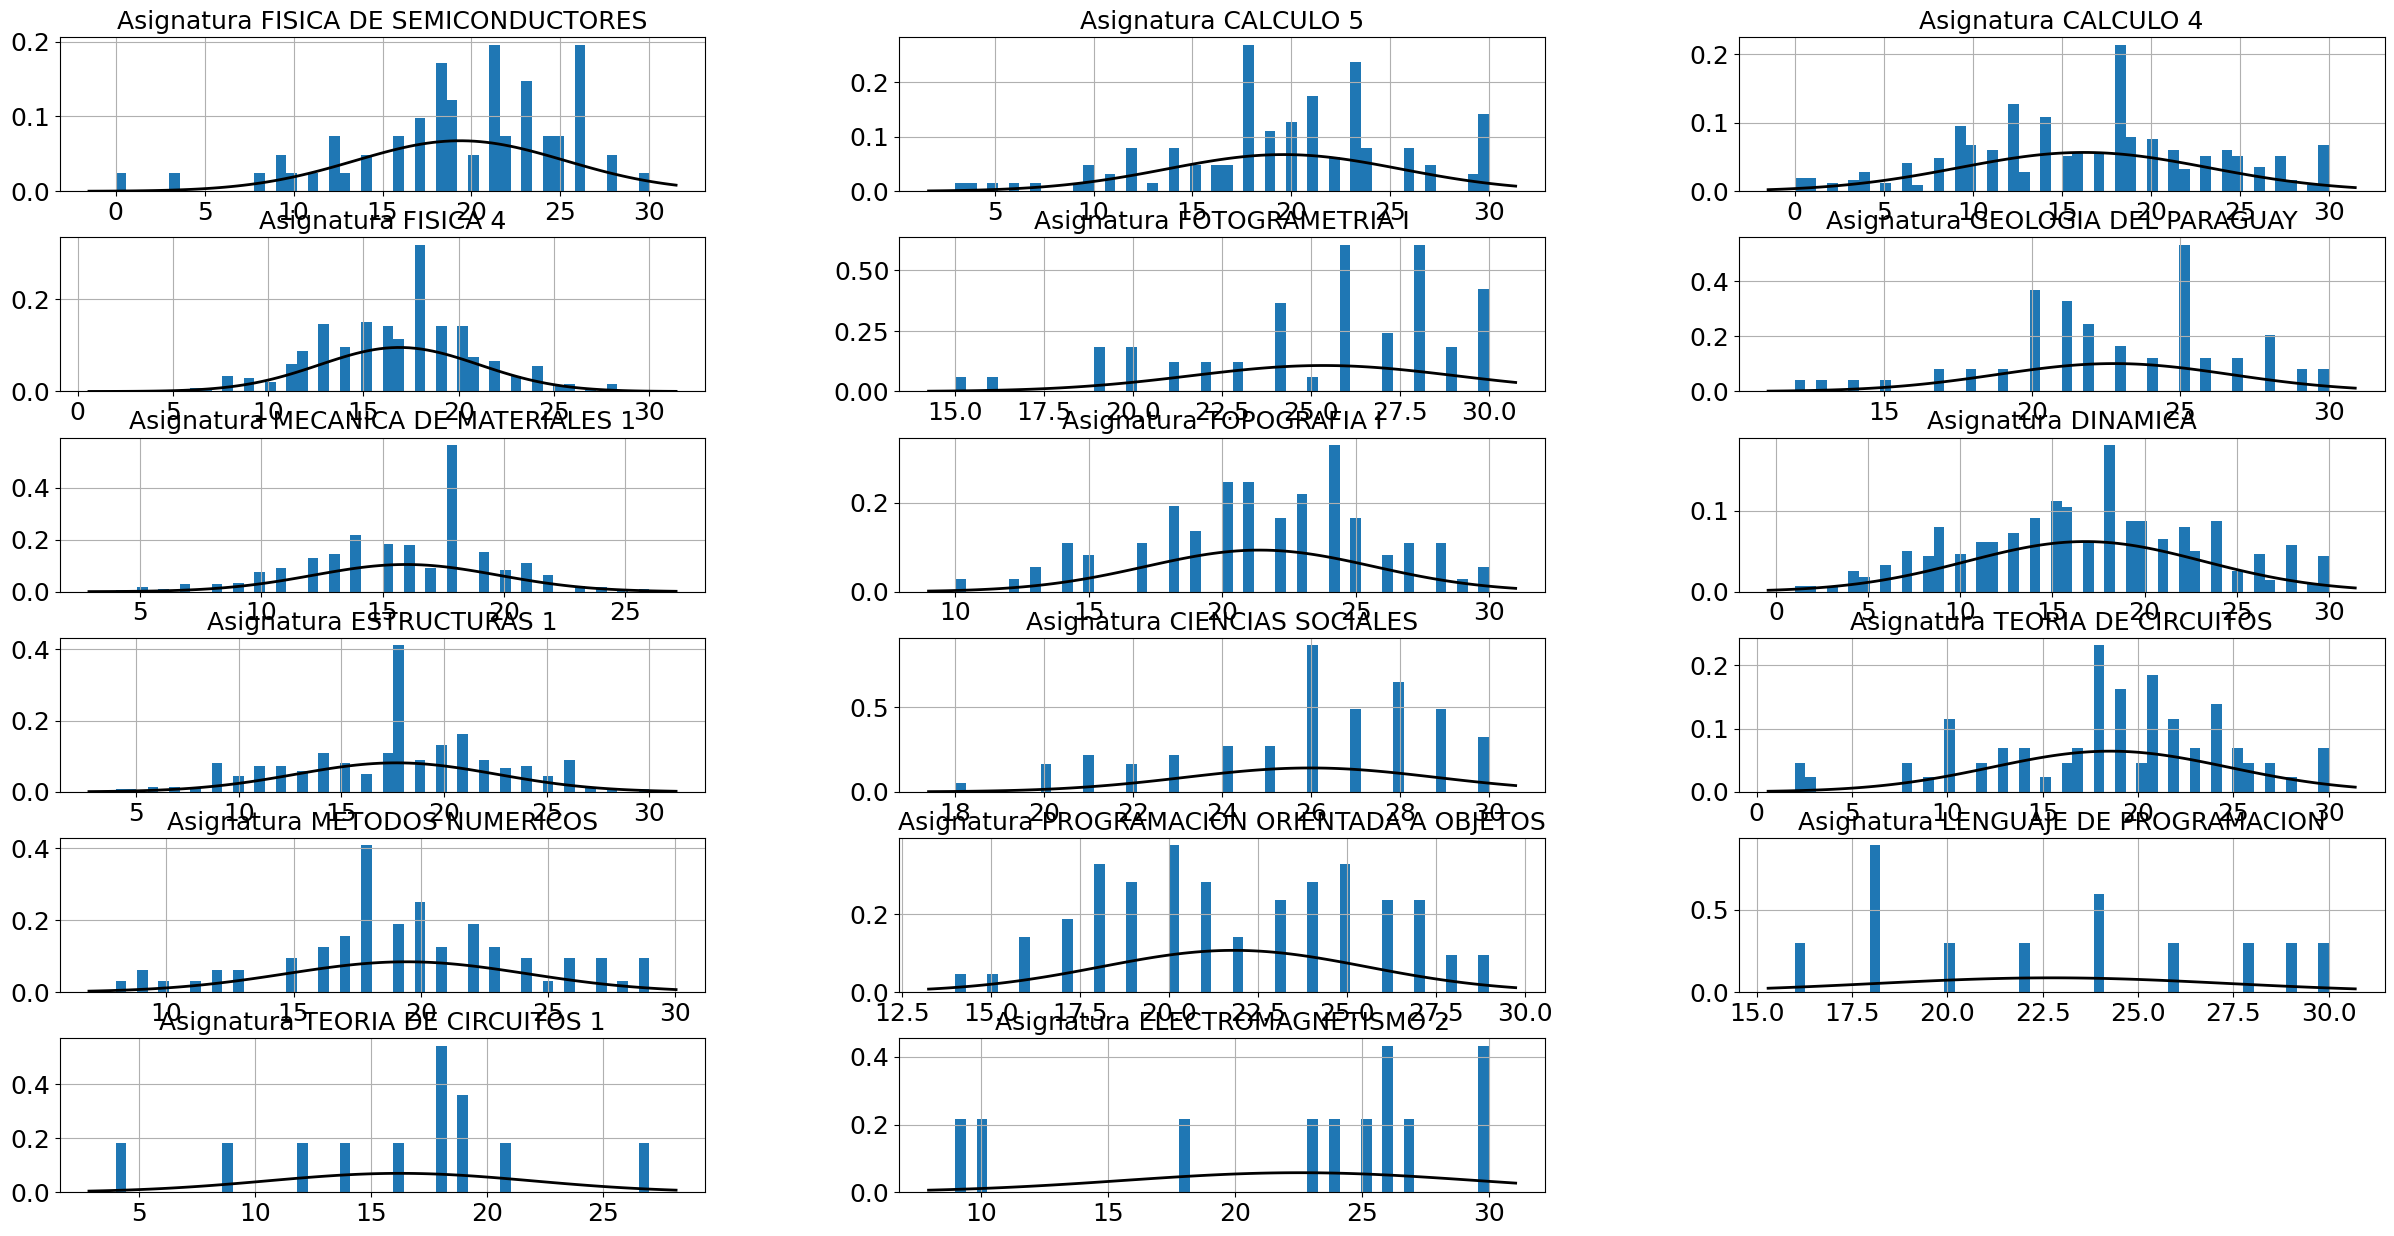

In [50]:

for semestre in [1,2,3,4]:
    df=data
    df=df[np.logical_and(df.Semestre==semestre,df.NF>=1)]
    asigs=df.Asignatura.unique()
    n=len(asigs)
    f, axs = plt.subplots(int(n/3-0.01)+1, 3,figsize=(30, 15))
    print(n)
    print(int(n/3)+1)
    k=0
    for asig in asigs:
        
       # df=df[df.values>50]
        dfg=df[df.Asignatura==asig]
        i=int(k/3)
        j=k%3
        print(i)
        print(j)
        k=k+1
        print("Semestre "+str(semestre)+" Asignatura "+asig)
        #df.unstack().plot(kind='bar', stacked=True,ax=ax)
        dfg[['final']].hist(bins=50,density=True, figsize=(5,5),ax=axs[i,j])
        axs[i,j].set_title("Asignatura "+asig)
        mu, std = stats.norm.fit(dfg['final'])
        xmin, xmax = axs[i, j].get_xlim()
        x = np.linspace(xmin, xmax, 100)
        p = stats.norm.pdf(x, mu, std)  # PDF of fitted normal distribution

        # Plot fitted normal distribution
        axs[i, j].plot(x, p, 'k', linewidth=2)
        #ax.legend(carreras)
       # plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))

        #ax.get_legend().remove()
   #     plt.xlabel("Materia,Año,Ciclo")
 #       plt.ylabel("Matriculaciones")
     # plt.savefig("graficos\Finales"+str(semestre)+".png", bbox_inches="tight")
    print(k)
    while(k<( 3*(int(n/3-0.01)+1))):
        i=int(k/3)
        j=k%3
        k=k+1
        print(i)
        print(j)     
        axs[i,j].set_axis_off()
    plt.savefig("graficos\Finales"+str(semestre)+".png", bbox_inches="tight")    
    plt.show()

In [ ]:
data[['codAsig','CarreraCod','Anho','1P','2P','1R','2R','Taller','NF','puntaje1','puntaje2','puntaje3']].hist(bins=50, figsize=(20,15))
#plt.savefig('hist.png')
plt.show()


In [ ]:
f, ax = plt.subplots(figsize=(5, 5))

sns.scatterplot('1P', 'Cod.Car.Sec Codificado', data=data.sample(1000), hue='Aprobado',ax=ax)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))


plt.xlabel("1P")
plt.ylabel("Carrera")
plt.show()